In [27]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mplcolors
import matplotlib.ticker as ptick
import matplotlib.patches as patches
import matplotlib.patheffects as pe
from MyPlotRecipe.SharedX import ShareXaxis
from MyPlotRecipe.UniversalColor import UniversalColor
from MyPlotRecipe.legend_shadow import legend_shadow
from scipy.io import readsav
import spiceypy as spice

import cmocean

from Leadangle_fit_JunoUVS import moonS3wlon_arr
from Leadangle_fit_JunoUVS import local_time_moon

from scipy.optimize import brentq

import JupiterMag as jm

UC = UniversalColor()
UC.set_palette()

F = ShareXaxis()
F.fontsize = 23
F.fontname = 'Liberation Sans Narrow'
F.set_default()

In [12]:
spice.furnsh(
    '/Users/shin/Documents/Research/Jupiter/Codes/HST/kernel/cassMetaK.txt')
radii = spice.bodvrd("JUPITER", "RADII", 3)[1]
RJ_km = radii[0]
RJ_pole = radii[2]
f = (RJ_km - RJ_pole) / RJ_km
print('Eq. radius:', RJ_km)
print('Pole radius:', RJ_pole)

Eq. radius: 71492.0
Pole radius: 66854.0


In [13]:
# Input about Juno observation
TARGET_MOON = 'Io'
TARGET_FP = ['MAW', 'TEB']
TARGET_HEM = 'both'
PJ_LIST = [1, 3]+np.arange(4, 68+1, 1).tolist()

In [14]:
# %% Constants
MU0 = 1.26E-6            # 真空中の透磁率
AMU2KG = 1.66E-27        # 原子質量をkgに変換するファクタ [kg]
RJ = 71492E+3            # JUPITER RADIUS [m]
MJ = 1.90E+27            # JUPITER MASS [kg]
C = 2.99792E+8           # LIGHT SPEED [m/s]
G = 6.67E-11             # 万有引力定数  [m^3 kg^-1 s^-2]

Psyn_io = (12.89)*3600      # Moon's synodic period [sec]
Psyn_eu = (11.22)*3600      # Moon's synodic period [sec]
Psyn_ga = (10.53)*3600      # Moon's synodic period [sec]

# Select moon synodic orbital period
if TARGET_MOON == 'Io':
    Psyn = Psyn_io
    r_moon = 5.9*RJ
elif TARGET_MOON == 'Europa':
    Psyn = Psyn_eu
    r_moon = 9.4*RJ
elif TARGET_MOON == 'Ganymede':
    Psyn = Psyn_ga
    r_moon = 15.0*RJ

In [15]:
# Select moon synodic orbital period
if len(PJ_LIST) > 1:
    if TARGET_MOON == 'Io':
        Psyn = Psyn_io
        PJ_LIST.pop(54-2)
        PJ_LIST.pop(55-3)
        PJ_LIST.pop(56-4)
        PJ_LIST.pop(57-5)
        PJ_LIST.pop(61-6)
        PJ_LIST.pop(63-7)
        PJ_LIST.pop(64-8)
        PJ_LIST.pop(65-9)
        PJ_LIST.pop(67-10)
        r_moon = 5.9*RJ
    elif TARGET_MOON == 'Europa':
        Psyn = Psyn_eu
        PJ_LIST.pop(24-2)
        PJ_LIST.pop(43-3)
        PJ_LIST.pop(47-4)
        PJ_LIST.pop(49-5)
        PJ_LIST.pop(50-6)
        PJ_LIST.pop(51-7)
        PJ_LIST.pop(53-8)
        PJ_LIST.pop(55-9)
        PJ_LIST.pop(56-10)
        PJ_LIST.pop(60-11)
        PJ_LIST.pop(61-12)
        PJ_LIST.pop(63-13)
        PJ_LIST.pop(64-14)
        PJ_LIST.pop(65-15)
        PJ_LIST.pop(66-16)
        PJ_LIST.pop(67-17)
        PJ_LIST.pop(68-18)
        r_moon = 9.4*RJ
    elif TARGET_MOON == 'Ganymede':
        Psyn = Psyn_ga
        PJ_LIST.pop(24-2)
        PJ_LIST.pop(31-3)
        PJ_LIST.pop(39-4)
        PJ_LIST.pop(43-5)
        PJ_LIST.pop(44-6)
        PJ_LIST.pop(45-7)
        PJ_LIST.pop(51-8)
        PJ_LIST.pop(52-9)
        PJ_LIST.pop(53-10)
        PJ_LIST.pop(54-11)
        PJ_LIST.pop(55-12)
        PJ_LIST.pop(56-13)
        PJ_LIST.pop(61-14)
        PJ_LIST.pop(62-15)
        PJ_LIST.pop(63-16)
        PJ_LIST.pop(64-17)
        PJ_LIST.pop(65-18)
        PJ_LIST.pop(66-19)
        PJ_LIST.pop(67-20)
        PJ_LIST.pop(68-21)
        r_moon = 15.0*RJ

    print(PJ_LIST)

[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 58, 59, 60, 62, 66, 68]


In [16]:
# ------------------------------------------------------------
# Hardcoded Juno Perijove UTC times
# ------------------------------------------------------------
JUNO_PJ_TIMES = {
    0: "2016-07-05 02:47:31.851",
    1: "2016-08-27 12:50:44.060",
    2: "2016-10-19 18:10:53.669",
    3: "2016-12-11 17:03:40.665",
    4: "2017-02-02 12:57:08.935",
    5: "2017-03-27 08:51:51.552",
    6: "2017-05-19 06:00:46.945",
    7: "2017-07-11 01:54:42.322",
    8: "2017-09-01 21:48:50.499",
    9: "2017-10-24 17:42:31.438",
    10: "2017-12-16 17:56:58.997",
    11: "2018-02-07 13:51:29.722",
    12: "2018-04-01 09:45:42.502",
    13: "2018-05-24 05:39:50.502",
    14: "2018-07-16 05:17:21.832",
    15: "2018-09-07 01:11:40.519",
    16: "2018-10-29 21:05:59.956",
    17: "2018-12-21 16:59:48.319",
    18: "2019-02-12 17:34:30.940",
    19: "2019-04-06 12:14:22.473",
    20: "2019-05-29 08:08:18.282",
    21: "2019-07-21 04:02:43.348",
    22: "2019-09-12 03:40:44.422",
    23: "2019-11-03 22:18:13.850",
    24: "2019-12-26 17:36:12.571",
    25: "2020-02-17 17:51:55.133",
    26: "2020-04-10 13:47:40.171",
    27: "2020-06-02 10:20:02.882",
    28: "2020-07-25 06:15:27.223",
    29: "2020-09-16 02:10:52.328",
    30: "2020-11-08 01:49:42.104",
    31: "2020-12-30 21:45:44.567",
    32: "2021-02-21 17:40:34.245",
}

In [17]:
def IAU2JSO(et, r_IAU):
    # et = ephemeris time
    R = spice.pxform("IAU_JUPITER", "JUNO_JSO", et)

    # Transform to JUNO_JSO
    r_JSO = R @ r_IAU

    return r_JSO

In [18]:
# %% Read the FP data
def readFPdata(PJnum: int, target_moon: str, target_hem='both', FLIP=False):
    """
    Args:
        `PJnum` (int): Perijove number \\
        `moon` (str): Name of the target (Io/Europa/Ganymede) \\
        `footprint` (str): `MAW` or `TEB` \\

    Returns:
        `wlon_fp` [deg] \\
        `err_wlon_fp` [deg] \\
        `lat_fp` [deg] \\
        `err_lat_fp` [deg] \\
        `wlon_moon` [deg] \\
        `eq_lead` [deg] \\
        `err_eq_lead` [deg] \\
        `viewing_angle` [deg] \\
        `PJ` \\
        `et` \\
        `hem` \\
    """

    datadir = '/Users/shin/Documents/Research/Juno/UVS/Codes2/data/n18_900km_Con2020_default/'
    datapath = datadir+target_moon[0]+'FP_position_data.txt'
    f_load = np.loadtxt(datapath,
                        skiprows=1,
                        delimiter=",",
                        )

    wlon_fp = f_load[:, 0]
    err_wlon_fp = f_load[:, 1]
    lat_fp = f_load[:, 2]
    err_lat_fp = f_load[:, 3]
    wlon_moon = f_load[:, 4]
    eq_lead = f_load[:, 5]
    err_eq_lead = f_load[:, 6]
    viewing_angle = f_load[:, 7]
    PJ = f_load[:, 8]
    et = f_load[:, 9]
    hem = f_load[:, 10]

    # Select PJ
    pj_select = np.where(PJ == PJnum)
    wlon_fp = wlon_fp[pj_select]
    err_wlon_fp = err_wlon_fp[pj_select]
    lat_fp = lat_fp[pj_select]
    err_lat_fp = err_lat_fp[pj_select]
    wlon_moon = wlon_moon[pj_select]
    eq_lead = eq_lead[pj_select]
    err_eq_lead = err_eq_lead[pj_select]
    viewing_angle = viewing_angle[pj_select]
    PJ = PJ[pj_select]
    et = et[pj_select]
    hem = hem[pj_select]

    # Select hemisphere
    # North < 0 / South > 0
    if target_hem == 'N':
        hem_select = np.where(hem < 0)
        wlon_fp = wlon_fp[hem_select]
        err_wlon_fp = err_wlon_fp[hem_select]
        lat_fp = lat_fp[hem_select]
        err_lat_fp = err_lat_fp[hem_select]
        wlon_moon = wlon_moon[hem_select]
        eq_lead = eq_lead[hem_select]
        err_eq_lead = err_eq_lead[hem_select]
        viewing_angle = viewing_angle[hem_select]
        PJ = PJ[hem_select]
        et = et[hem_select]
        hem = hem[hem_select]
    elif target_hem == 'S':
        hem_select = np.where(hem > 0)
        wlon_fp = wlon_fp[hem_select]
        err_wlon_fp = err_wlon_fp[hem_select]
        lat_fp = lat_fp[hem_select]
        err_lat_fp = err_lat_fp[hem_select]
        wlon_moon = wlon_moon[hem_select]
        eq_lead = eq_lead[hem_select]
        err_eq_lead = err_eq_lead[hem_select]
        viewing_angle = viewing_angle[hem_select]
        PJ = PJ[hem_select]
        et = et[hem_select]
        hem = hem[hem_select]

    if FLIP:
        hem *= -1

    return wlon_fp, err_wlon_fp, lat_fp, err_lat_fp, wlon_moon, eq_lead, err_eq_lead, viewing_angle, PJ, et, hem

In [19]:
wlon_fp_0 = np.zeros(3)
err_wlon_fp_0 = np.zeros(3)
lat_fp_0 = np.zeros(3)
err_lat_fp_0 = np.zeros(3)
moon_S3wlon_0 = np.zeros(3)
et_fp_0 = np.zeros(3)
hem_fp_0 = np.zeros(3)
pj_fp_0 = np.zeros(3)
eqlead_fp_0 = np.zeros(3)
view_angle_0 = np.zeros(3)

for i in PJ_LIST:
    wlon_fp, err_wlon_fp, lat_fp, err_lat_fp, moon_S3wlon, eqlead_fp, _, view_angle, pj_fp, et_fp, hem_fp = readFPdata(i,
                                                                                                                       TARGET_MOON,
                                                                                                                       TARGET_HEM)
    wlon_fp_0 = np.append(wlon_fp_0, wlon_fp)
    err_wlon_fp_0 = np.append(err_wlon_fp_0, err_wlon_fp)
    lat_fp_0 = np.append(lat_fp_0, lat_fp)
    err_lat_fp_0 = np.append(err_lat_fp_0, err_lat_fp)
    moon_S3wlon_0 = np.append(moon_S3wlon_0, moon_S3wlon)
    et_fp_0 = np.append(et_fp_0, et_fp)
    hem_fp_0 = np.append(hem_fp_0, hem_fp)
    pj_fp_0 = np.append(pj_fp_0, pj_fp)
    eqlead_fp_0 = np.append(eqlead_fp_0, eqlead_fp)
    view_angle_0 = np.append(view_angle_0, view_angle)

# 余計な部分を削除
wlon_fp = wlon_fp_0[3:]
err_wlon_fp = err_wlon_fp_0[3:]
lat_fp = lat_fp_0[3:]
err_lat_fp = err_lat_fp_0[3:]
moon_S3wlon = moon_S3wlon_0[3:]
et_fp = et_fp_0[3:]
hem_fp = hem_fp_0[3:]
pj_fp = pj_fp_0[3:]
eqlead_fp = eqlead_fp_0[3:]
view_angle = view_angle_0[3:]
view_angle = view_angle_0[3:]

# Emission angleで制限
view_idx = np.where((view_angle <= 30.0))

wlon_fp = wlon_fp[view_idx]
err_wlon_fp = err_wlon_fp[view_idx]
lat_fp = lat_fp[view_idx]
err_lat_fp = err_lat_fp[view_idx]
moon_S3wlon = moon_S3wlon[view_idx]
et_fp = et_fp[view_idx]
hem_fp = hem_fp[view_idx]
pj_fp = pj_fp[view_idx]
eqlead_fp = eqlead_fp[view_idx]
view_angle = view_angle[view_idx]

print(wlon_fp.shape)

(423,)


In [20]:
# %% Data from Connerney+2020: PJ index
con20_pj_idx = np.array([1, 3, 4, 5, 6,
                         7, 8, 9, 10, 11,
                         12, 13, 14, 15, 16,
                         17, 18, 19, 20, 21,
                         22, 23, 24], dtype=int)


# %% Data from Connerney+2020: Current constant [nT]
con20_mu_i_tot = np.array([150.1, 137.8, 127.2, 129.1, 130.1,
                           142.3, 140.1, 143.8, 137.0, 141.4,
                           124.2, 148.9, 145.3, 144.8, 149.9,
                           132.1, 133.5, 152.9, 138.5, 138.8,
                           156.1, 141.4, 146.3])


# %% Data from Connerney+2020: Radial current constant [MA]
con20_mu_i_rho = np.array([35.2, 14.6, 7.7, 11.5, 20.8,
                           20.2, 12.2, 21.1, 20.9, 10.7,
                           26.26, 16.4, 12.0, 19.6, 12.0,
                           13.6, 20.0, 12.8, 16.0, 17.3,
                           9.9, 16.1, 10.3])

# TraceFieldを使う

In [21]:
# Manual trace
r0 = r_moon/RJ              # [RJ]
theta0 = np.radians(90.0)   # [rad]
phi0 = np.radians(np.linspace(0.0, 359.9, 180))    # [rad]

In [22]:
# n=18, 900 km altitude
jm.Internal.Config(Model='jrm33', Degree=18,
                   CartesianIn=True, CartesianOut=True)
jm.Con2020.Config(mu_i=139.6, d=3.6, r0=7.8, r1=51.4,
                  equation_type='analytic')

# Manual trace
r0 = r_moon/RJ              # [RJ]
theta0 = np.radians(90.0)   # [rad]
phi0 = np.radians(np.linspace(0.0, 359.9, 180))    # [rad]

x0 = r0*np.sin(theta0)*np.cos(phi0)
y0 = r0*np.sin(theta0)*np.sin(phi0)
z0 = r0*np.cos(theta0)*np.ones(phi0.size)

r_fp_traced_900n18 = np.zeros(phi0.size)
lat_fp_traced_900n18 = np.zeros(phi0.size)
wlon_fp_traced_900n18 = np.zeros(phi0.size)
r_fp_traced_900s18 = np.zeros(phi0.size)
lat_fp_traced_900s18 = np.zeros(phi0.size)
wlon_fp_traced_900s18 = np.zeros(phi0.size)

for j in range(phi0.size):
    T1 = jm.TraceField(x0[j], y0[j], z0[j],
                       IntModel='jrm33', ExtModel='Con2020',
                       MaxStep=0.0003,
                       MaxLen=700000, ErrMax=0.000001)

    x_traced = T1.x[0, ~np.isnan(T1.x[0, :])]
    y_traced = T1.y[0, ~np.isnan(T1.y[0, :])]
    z_traced = T1.z[0, ~np.isnan(T1.z[0, :])]
    r_traced = np.sqrt(x_traced**2+y_traced**2+z_traced**2)
    rho_traced = np.sqrt(x_traced**2+y_traced**2)

    # 高度を求める (north)
    r_traced_near_idx = np.where(
        (r_traced < (1.0+1000.0/RJ_km)) & (z_traced > 0.0))[0]
    alt_candid = np.zeros(r_traced_near_idx.size)
    for i in range(r_traced_near_idx.size):
        x = x_traced[r_traced_near_idx[i]]  # [RJ]
        y = y_traced[r_traced_near_idx[i]]  # [RJ]
        z = z_traced[r_traced_near_idx[i]]  # [RJ]
        # Jovigraphic (gr)
        lon_gr, lat_gr, alt_gr = spice.recpgr("JUPITER",
                                              np.array([x*RJ_km,
                                                        y*RJ_km,
                                                        z*RJ_km]),
                                              RJ_km,
                                              (RJ_km-RJ_pole)/RJ_km)
        alt_candid[i] = alt_gr      # [km]
    n_900km_idx = np.argmin(abs(alt_candid - 900.0))
    x_traced_900n = x_traced[r_traced_near_idx[n_900km_idx]]
    y_traced_900n = y_traced[r_traced_near_idx[n_900km_idx]]
    z_traced_900n = z_traced[r_traced_near_idx[n_900km_idx]]
    r_traced_900n = r_traced[r_traced_near_idx[n_900km_idx]]
    theta_traced_900n = math.acos(z_traced_900n/r_traced_900n)
    phi_traced_900n = math.atan2(y_traced_900n, x_traced_900n)
    lat_fp_traced_900n18[j] = 90.0-math.degrees(theta_traced_900n)
    wlon_fp_traced_900n18[j] = np.mod(
        360.0-math.degrees(phi_traced_900n), 360.0)
    r_fp_traced_900n18[j] = r_traced_900n

    # 高度を求める (south)
    r_traced_near_idx = np.where(
        (r_traced < (1.0+1000.0/RJ_km)) & (z_traced < 0.0))[0]
    alt_candid = np.zeros(r_traced_near_idx.size)
    for i in range(r_traced_near_idx.size):
        x = x_traced[r_traced_near_idx[i]]  # [RJ]
        y = y_traced[r_traced_near_idx[i]]  # [RJ]
        z = z_traced[r_traced_near_idx[i]]  # [RJ]
        # Jovigraphic (gr)
        lon_gr, lat_gr, alt_gr = spice.recpgr("JUPITER",
                                              np.array([x*RJ_km,
                                                        y*RJ_km,
                                                        z*RJ_km]),
                                              RJ_km,
                                              (RJ_km-RJ_pole)/RJ_km)
        alt_candid[i] = alt_gr      # [km]
    s_900km_idx = np.argmin(abs(alt_candid - 900.0))
    x_traced_900s = x_traced[r_traced_near_idx[s_900km_idx]]
    y_traced_900s = y_traced[r_traced_near_idx[s_900km_idx]]
    z_traced_900s = z_traced[r_traced_near_idx[s_900km_idx]]
    r_traced_900s = r_traced[r_traced_near_idx[s_900km_idx]]
    theta_traced_900s = math.acos(z_traced_900s/r_traced_900s)
    phi_traced_900s = math.atan2(y_traced_900s, x_traced_900s)
    lat_fp_traced_900s18[j] = 90.0-math.degrees(theta_traced_900s)
    wlon_fp_traced_900s18[j] = np.mod(
        360.0-math.degrees(phi_traced_900s), 360.0)
    r_fp_traced_900s18[j] = r_traced_900s

In [ ]:
# 観測との比較, n=18, 900 km altitude, default
r_defaultfp_18 = np.zeros(et_fp.size)
wlon_defaultfp_18 = np.zeros(et_fp.size)
lat_defaultfp_18 = np.zeros(et_fp.size)
print(et_fp.size)

jm.Internal.Config(Model='jrm33', Degree=18,
                   CartesianIn=True, CartesianOut=True)
jm.Con2020.Config(mu_i=139.6, d=3.6, r0=7.8, r1=51.4,
                  equation_type='analytic')

moon_S3wlon_select = moon_S3wlon
eqlead_fp_select = eqlead_fp
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(et_fp_select.size):
    # Orbital distance at the PJ time
    _, _, z0_moon_obs, r_moon_obs, _, _, _ = moonS3wlon_arr(np.array([et_fp_select[j]]),
                                                            TARGET_MOON)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)

    # Manual trace
    phi0 = math.radians(360.0-(moon_S3wlon_select[j]-eqlead_fp_select[j]))
    x0 = r_moon_obs[0]*math.cos(phi0)/RJ
    y0 = r_moon_obs[0]*math.sin(phi0)/RJ
    z0 = z0_moon_obs[0]/RJ

    T1 = jm.TraceField(x0, y0, z0,
                       IntModel='jrm33', ExtModel='Con2020',
                       MaxStep=0.0003,
                       MaxLen=700000, ErrMax=0.000001)

    x_traced = T1.x[0, ~np.isnan(T1.x[0, :])]
    y_traced = T1.y[0, ~np.isnan(T1.y[0, :])]
    z_traced = T1.z[0, ~np.isnan(T1.z[0, :])]
    r_traced = np.sqrt(x_traced**2+y_traced**2+z_traced**2)
    rho_traced = np.sqrt(x_traced**2+y_traced**2)

    # 高度を求める
    if hem_fp_select[j] < 0:
        r_traced_near_idx = np.where(
            (r_traced < (1.0+1000.0/RJ_km)) & (z_traced > 0.0))[0]
    else:
        r_traced_near_idx = np.where(
            (r_traced < (1.0+1000.0/RJ_km)) & (z_traced < 0.0))[0]

    alt_candid = np.zeros(r_traced_near_idx.size)
    for i in range(r_traced_near_idx.size):
        x = x_traced[r_traced_near_idx[i]]  # [RJ]
        y = y_traced[r_traced_near_idx[i]]  # [RJ]
        z = z_traced[r_traced_near_idx[i]]  # [RJ]
        # Jovigraphic (gr)
        lon_gr, lat_gr, alt_gr = spice.recpgr("JUPITER",
                                              np.array([x*RJ_km,
                                                        y*RJ_km,
                                                        z*RJ_km]),
                                              RJ_km,
                                              (RJ_km-RJ_pole)/RJ_km)
        alt_candid[i] = alt_gr      # [km]
    n_900km_idx = np.argmin(abs(alt_candid - 900.0))
    x_traced_900 = x_traced[r_traced_near_idx[n_900km_idx]]
    y_traced_900 = y_traced[r_traced_near_idx[n_900km_idx]]
    z_traced_900 = z_traced[r_traced_near_idx[n_900km_idx]]
    r_traced_900 = r_traced[r_traced_near_idx[n_900km_idx]]
    theta_traced_900 = math.acos(z_traced_900/r_traced_900)
    phi_traced_900 = math.atan2(y_traced_900, x_traced_900)
    lat_defaultfp_18[j] = 90.0-math.degrees(theta_traced_900)
    wlon_defaultfp_18[j] = np.mod(360.0-math.degrees(phi_traced_900), 360.0)
    r_defaultfp_18[j] = r_traced_900    # [RJ]

423


# All PJ: Polarplot

In [25]:
ref_data_N = np.loadtxt(
    '/Users/shin/Documents/Research/Juno/UVS/Codes2/data/JRM33/satellite_foot_N.txt', skiprows=3)
ref_data_S = np.loadtxt(
    '/Users/shin/Documents/Research/Juno/UVS/Codes2/data/JRM33/satellite_foot_S.txt', skiprows=3)

eq_wlon_ref = ref_data_N[:, 0]          # [deg]
ifp_ref_pos_N = ref_data_N[:, 3:5]      # (lat, wlon) [deg]
ifp_ref_pos_S = ref_data_S[:, 3:5]      # (lat, wlon) [deg]
efp_ref_pos_N = ref_data_N[:, 5:7]      # (lat, wlon) [deg]
efp_ref_pos_S = ref_data_S[:, 5:7]      # (lat, wlon) [deg]
gfp_ref_pos_N = ref_data_N[:, 7:9]      # (lat, wlon) [deg]
gfp_ref_pos_S = ref_data_S[:, 7:9]      # (lat, wlon) [deg]

print(gfp_ref_pos_N[:, 0])

[86.24 87.68 89.02 88.74 87.17 85.43 83.62 81.72 79.68 77.44 74.96 72.28
 69.7  67.45 65.56 63.93 62.49 61.2  60.04 59.01 58.08 57.26 56.53 55.91
 55.38 54.93 54.57 54.29 54.08 53.95 53.89 53.89 53.96 54.09 54.28 54.53
 54.84 55.2  55.61 56.07 56.58 57.12 57.71 58.33 58.99 59.68 60.4  61.14
 61.92 62.72 63.55 64.42 65.33 66.28 67.29 68.36 69.48 70.63 71.8  72.94
 74.02 75.03 75.97 76.87 77.73 78.6  79.48 80.4  81.39 82.46 83.61 84.88
 86.24]


# n=18でひととおりプロットし直す

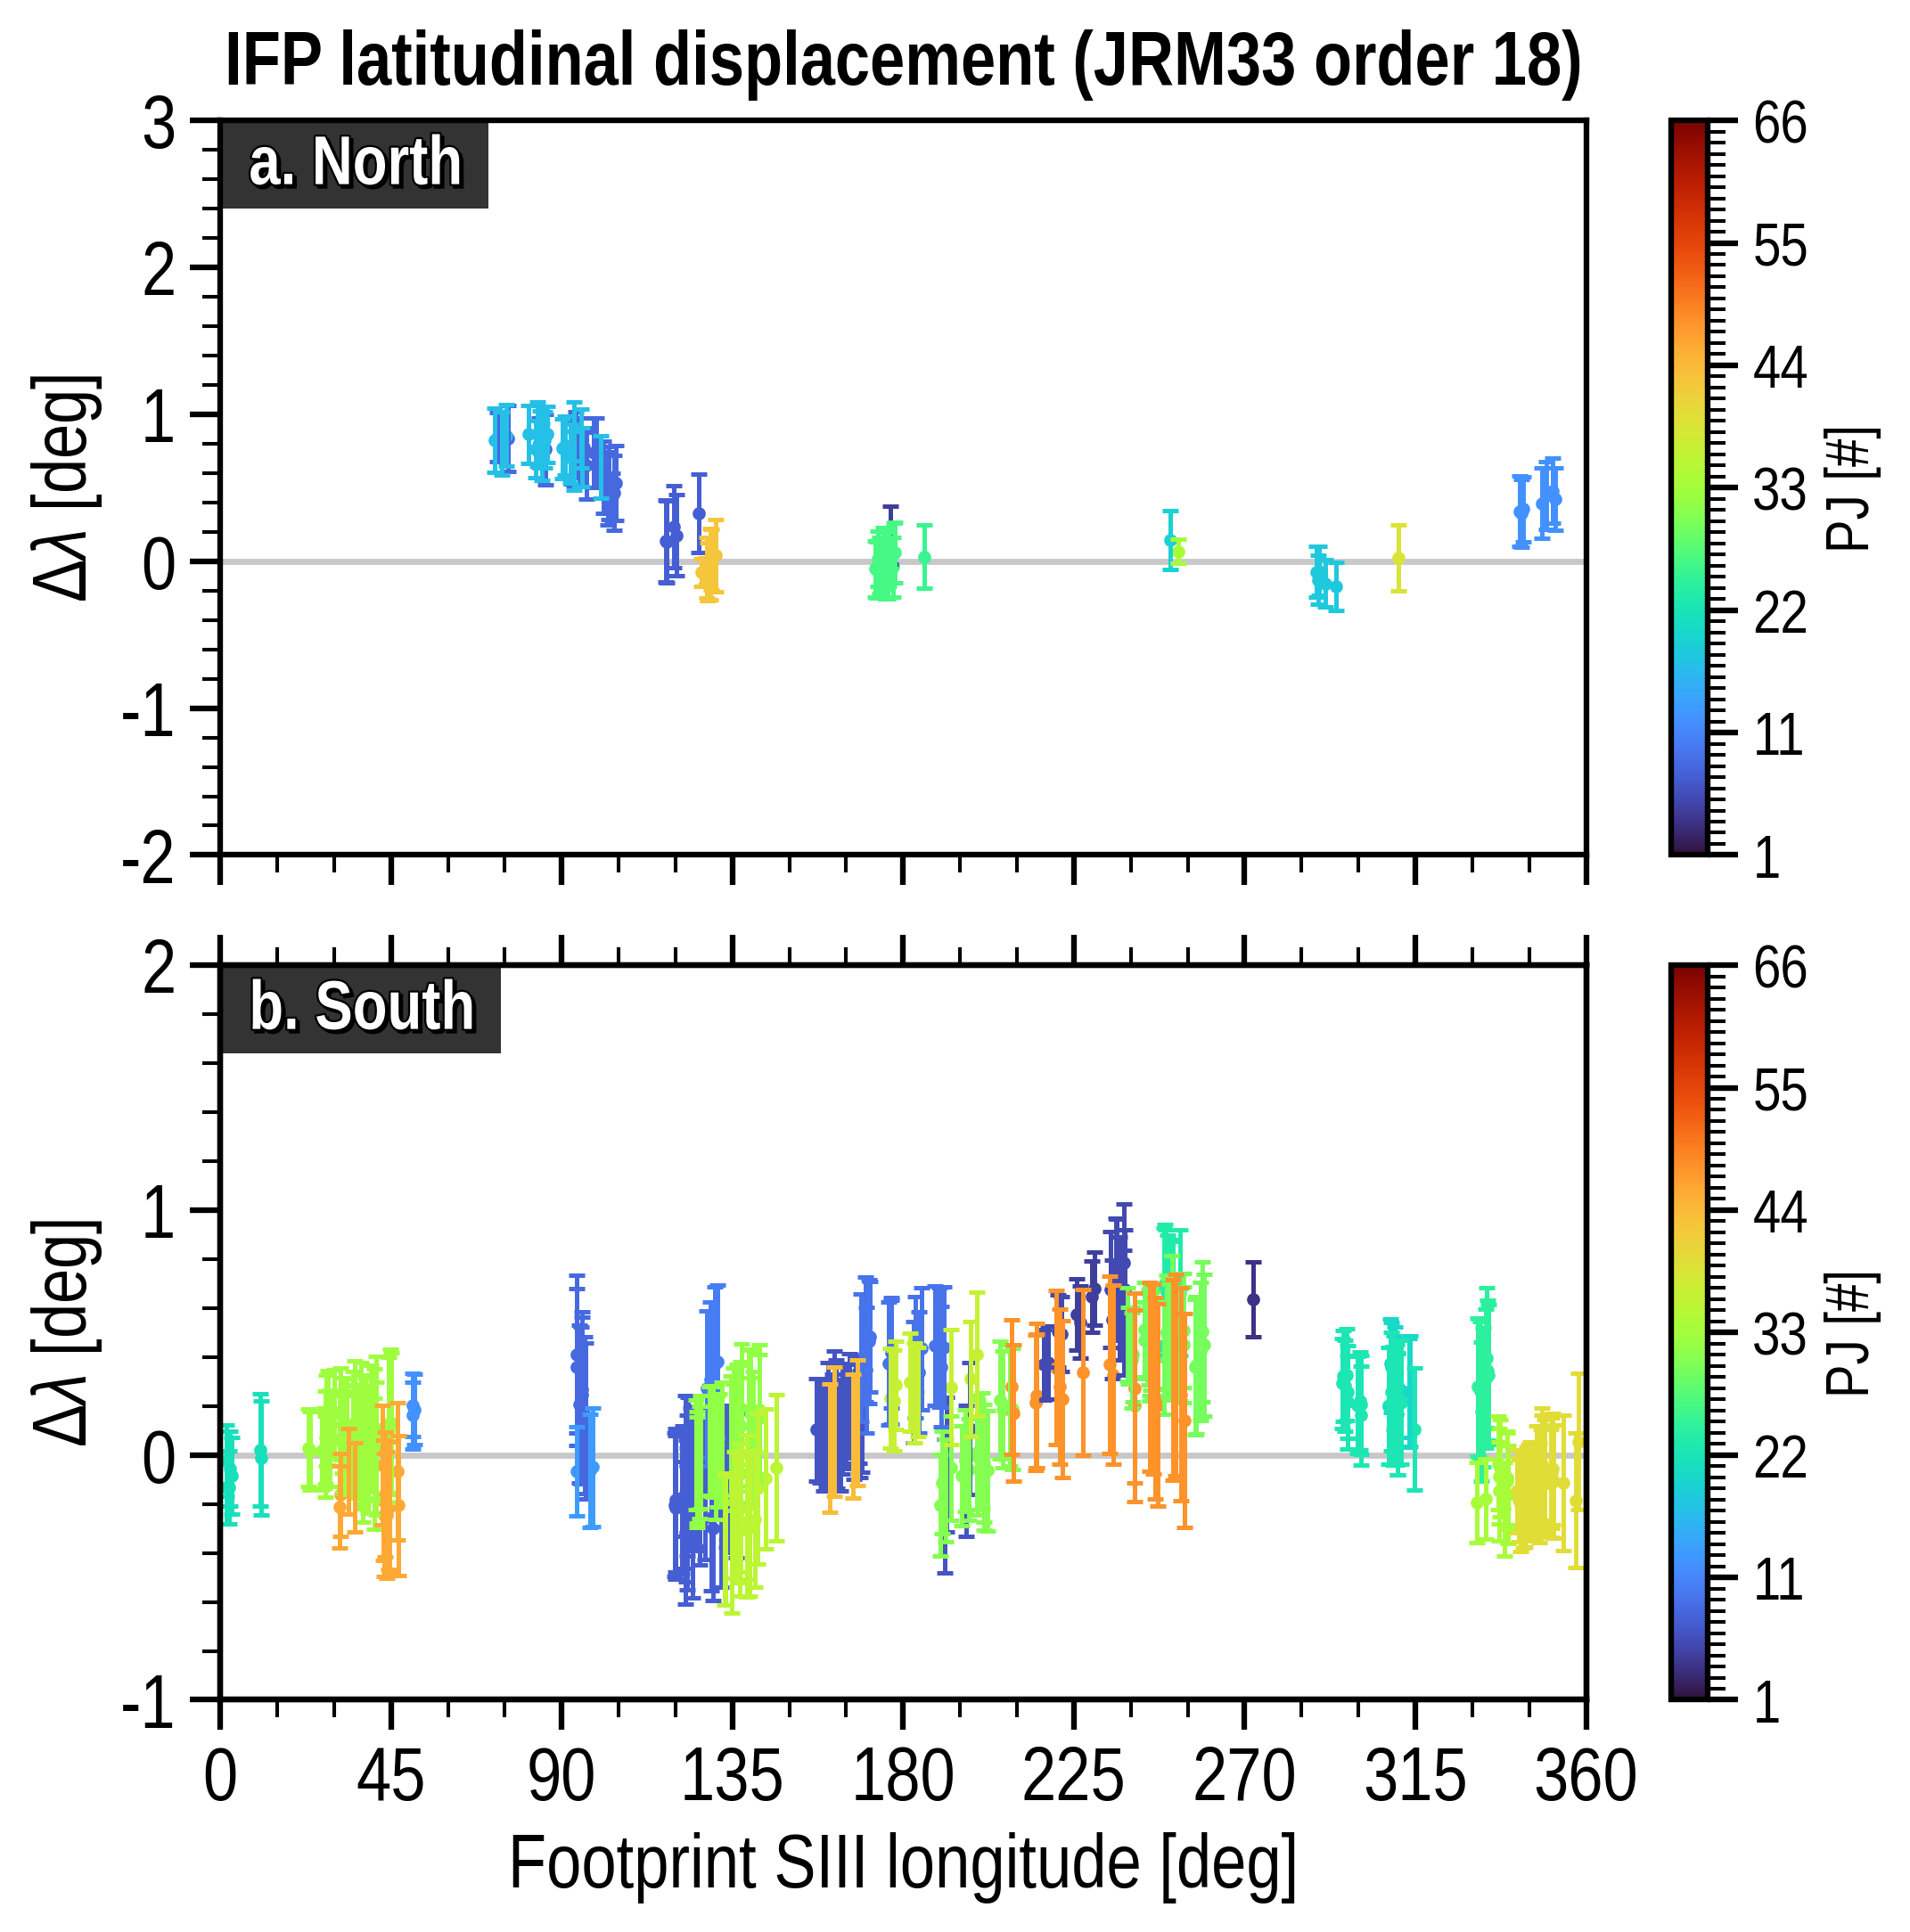

In [26]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(7.2, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Footprint SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1
    sc = F.ax[ax_idx].scatter(wlon_fp_select[j],
                              sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                              s=5.0, c=pj_fp[j], cmap=cmap, vmin=vmin, vmax=vmax)
    F.ax[ax_idx].errorbar(x=wlon_fp_select[j],
                          y=sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color=cmap(norm(pj_fp[j])))

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(1, 66, 7))
    cax.ax.set_yticklabels(np.linspace(
        1, 66, 7, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(11))
    cax.ax.set_ylabel(r'PJ [#]', fontsize=F.fontsize*0.8)

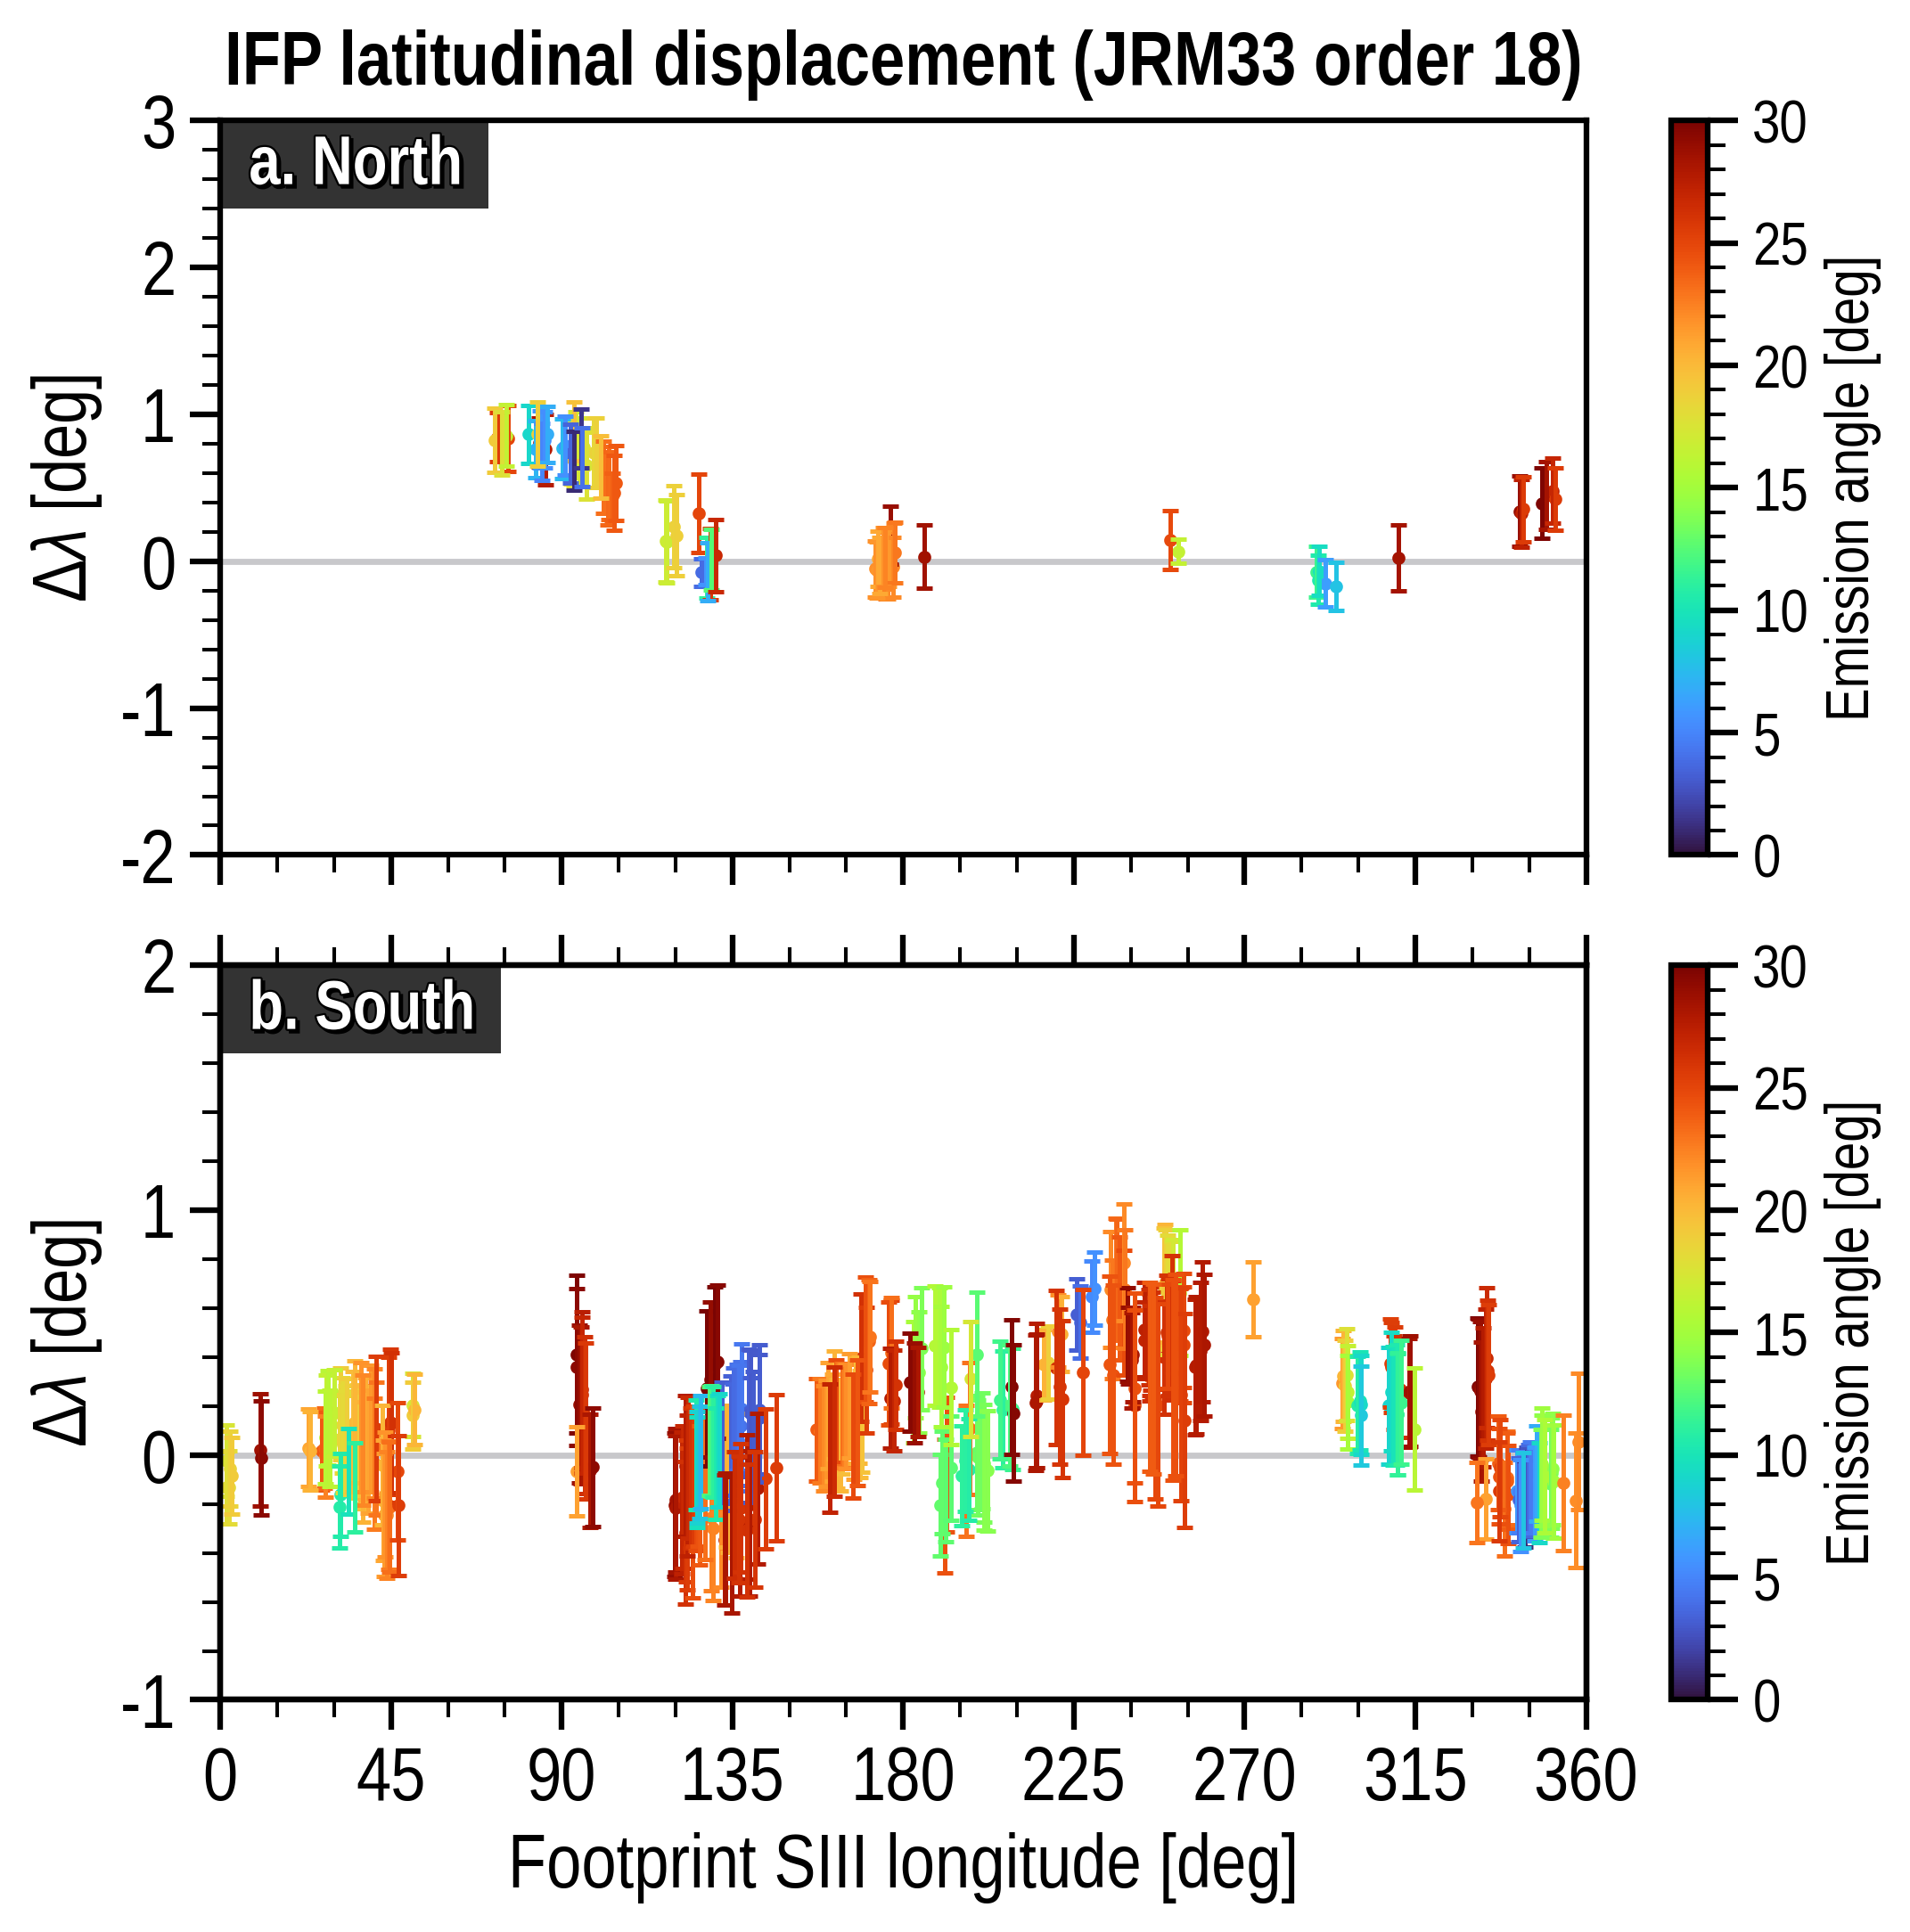

In [64]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(7.2, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Footprint SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 0.0
vmax = 30.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1
    sc = F.ax[ax_idx].scatter(wlon_fp_select[j],
                              sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                              s=5.0, c=view_angle_select[j], cmap=cmap, vmin=vmin, vmax=vmax)
    F.ax[ax_idx].errorbar(x=wlon_fp_select[j],
                          y=sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color=cmap(norm(view_angle_select[j])))

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(0, 30, 7))
    cax.ax.set_yticklabels(np.linspace(
        0, 30, 7, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(5))
    cax.ax.set_ylabel(r'Emission angle [deg]', fontsize=F.fontsize*0.8)

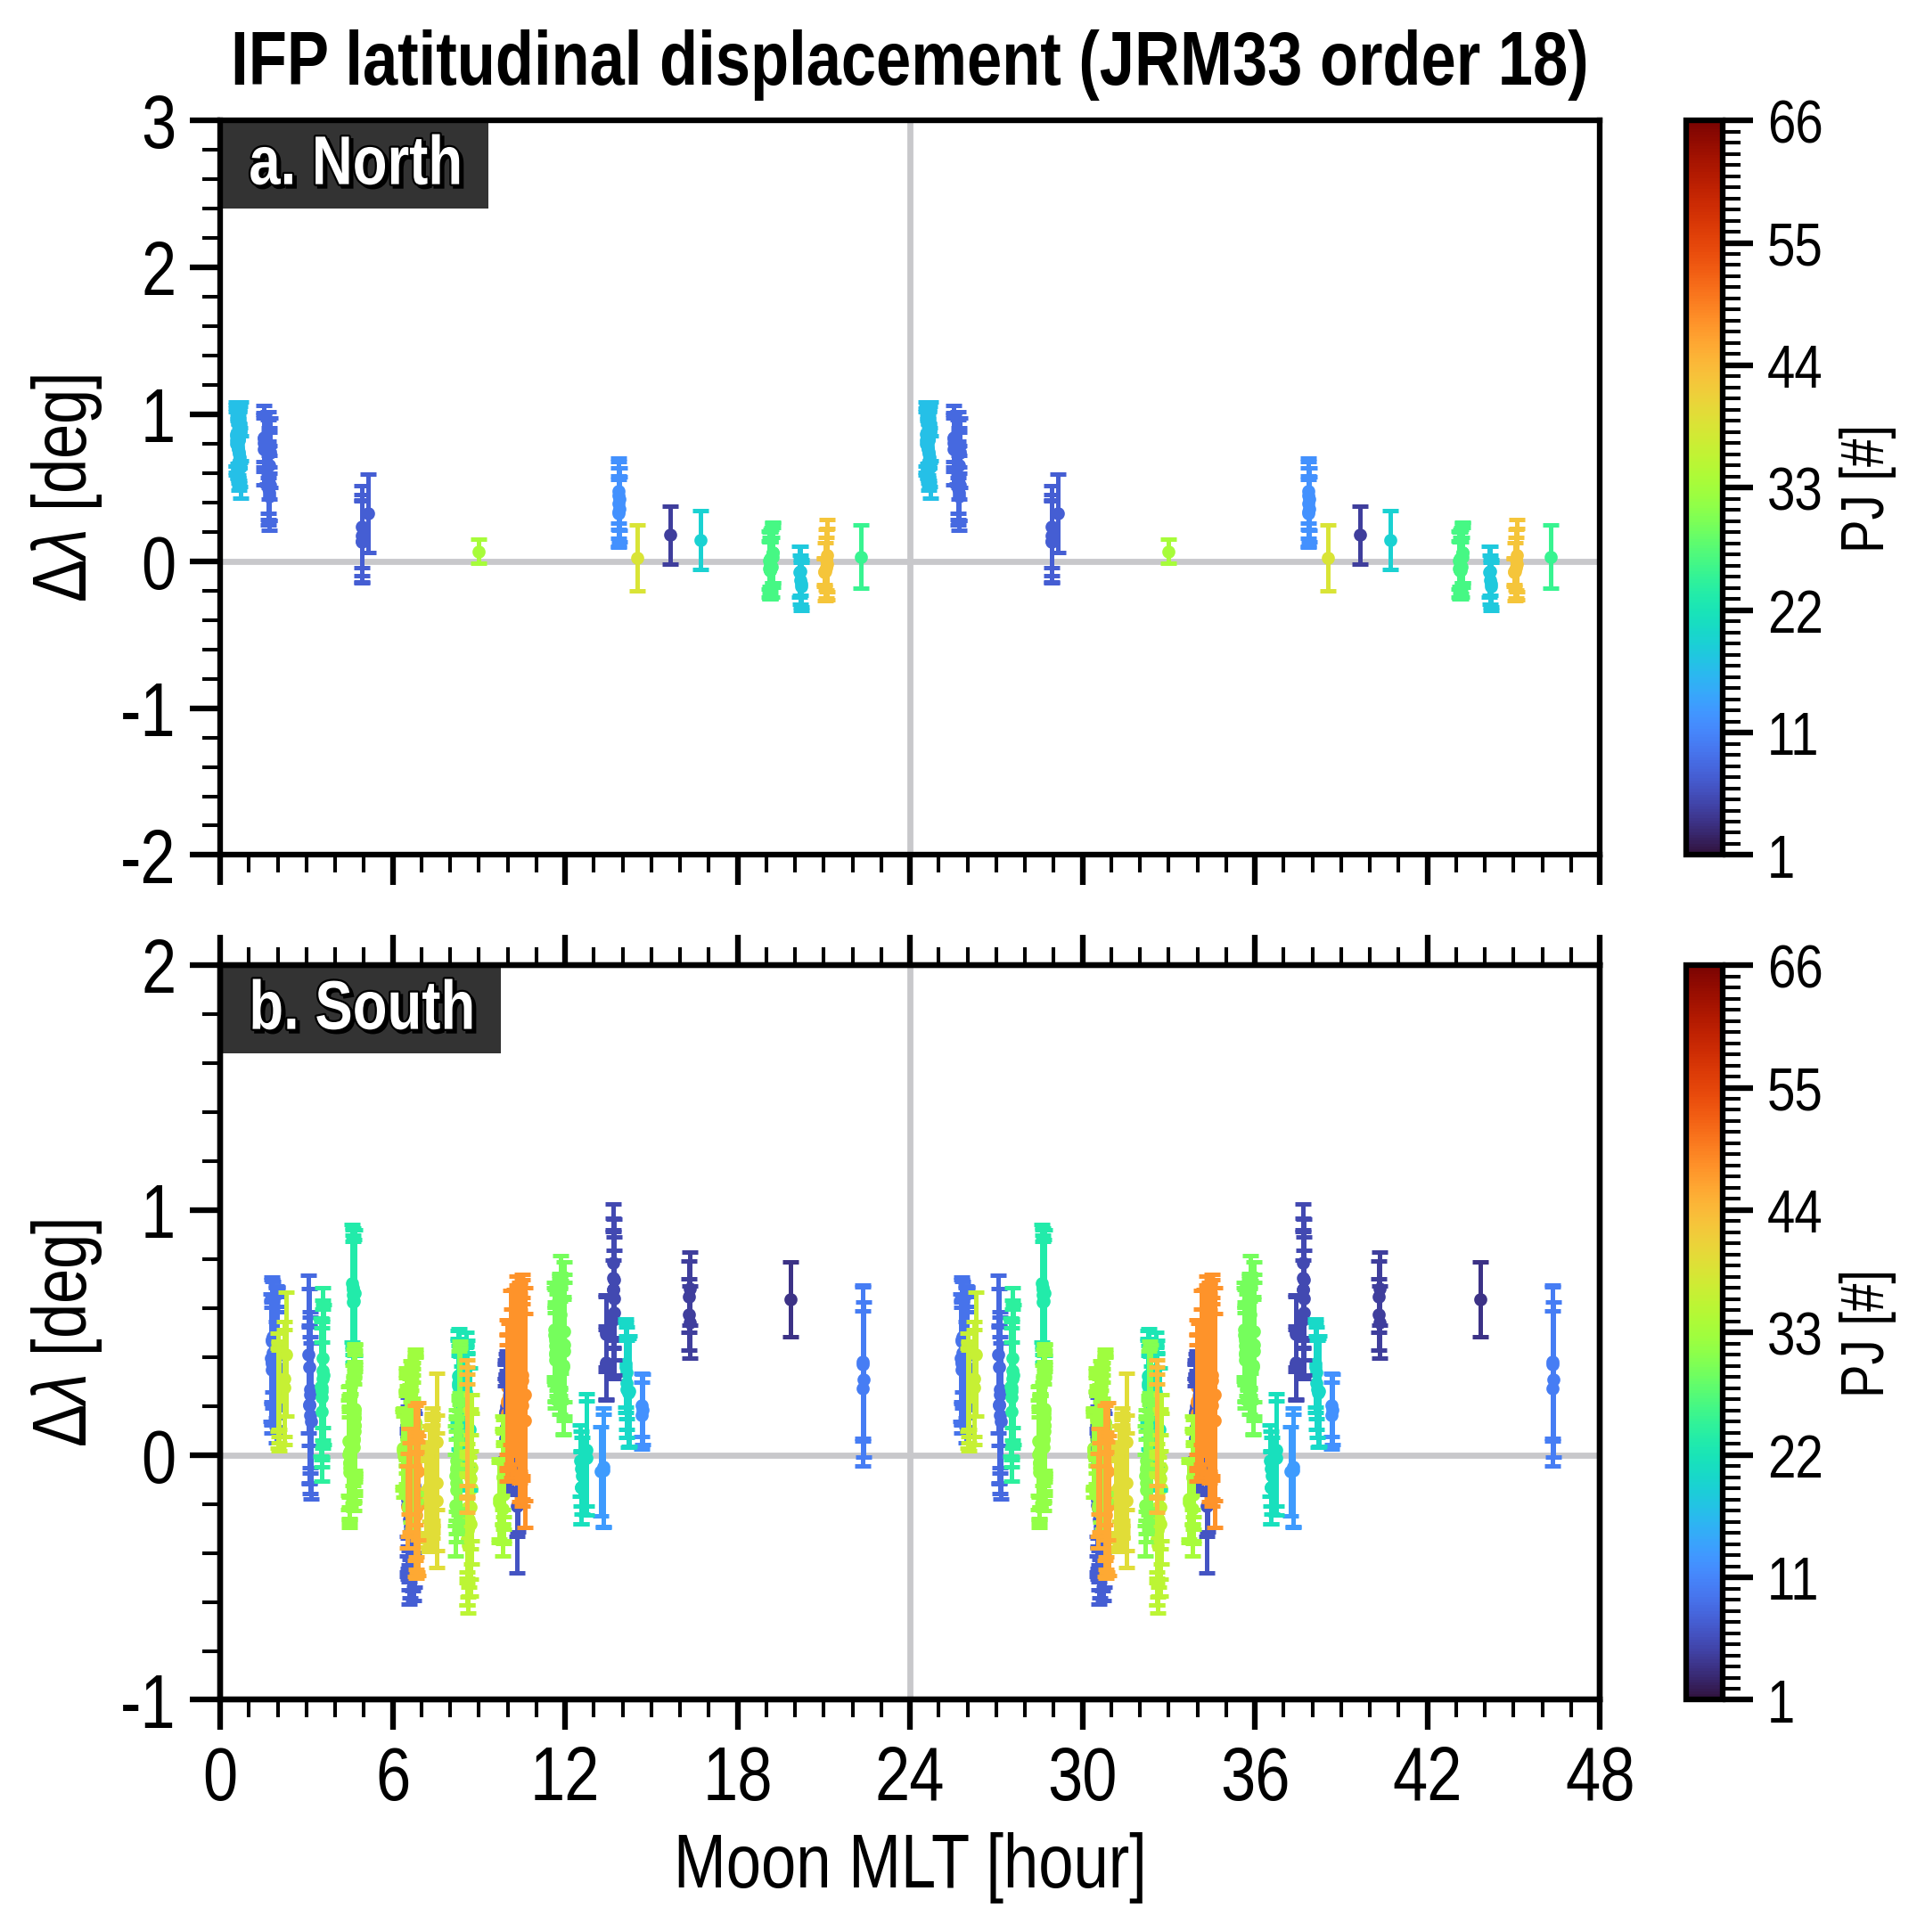

In [65]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(7.2, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)

    for i in range(2):
        sc = F.ax[ax_idx].scatter(lt+24.0*i,
                                  sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                                  s=5.0, c=pj_fp[j], cmap=cmap, vmin=vmin, vmax=vmax)
        F.ax[ax_idx].errorbar(x=lt+24.0*i,
                              y=sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                              yerr=err_lat_fp_select[j],
                              elinewidth=1.1, linewidth=0., markersize=0.,
                              capsize=2.0, capthick=1.1,
                              color=cmap(norm(pj_fp[j])))

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    F.ax[i].axvline(x=24.0, color=UC.lightgray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(1, 66, 7))
    cax.ax.set_yticklabels(np.linspace(
        1, 66, 7, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(11))
    cax.ax.set_ylabel(r'PJ [#]', fontsize=F.fontsize*0.8)

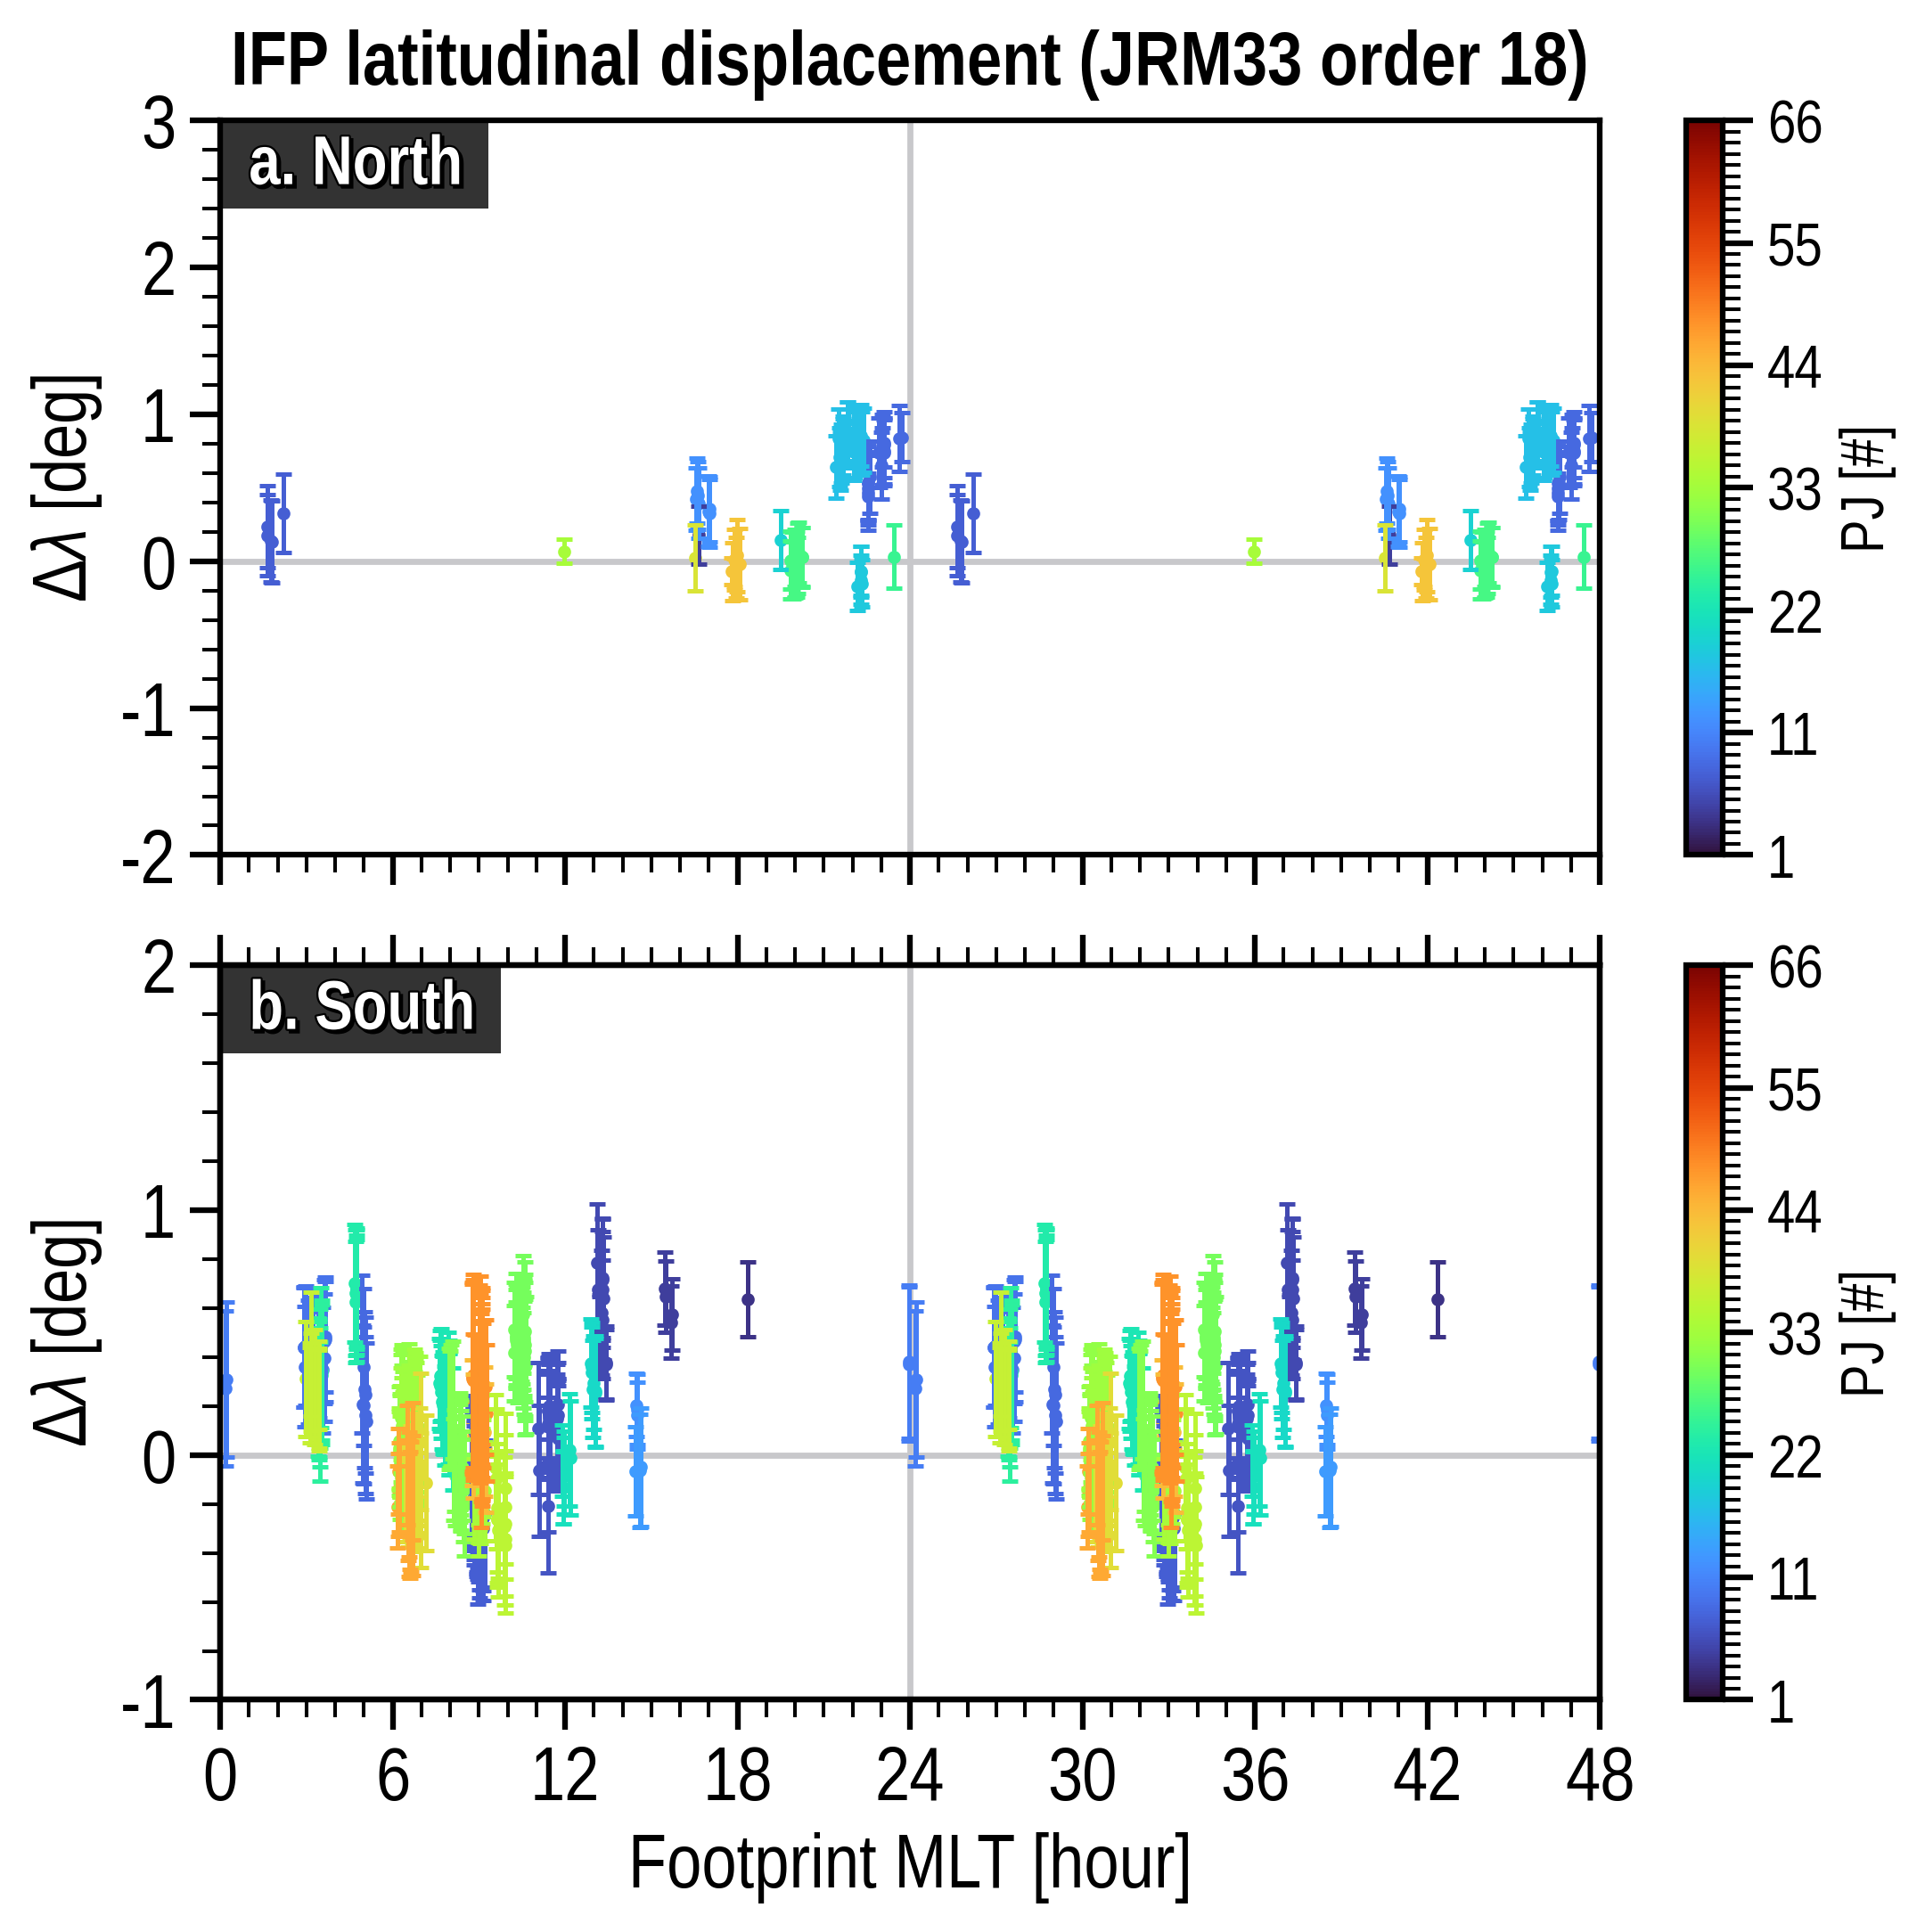

In [66]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(7.2, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Footprint MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    r_JSO = IAU2JSO(et=et_fp_select[j],
                    r_IAU=np.array([x_fp_polar, y_fp_polar, z_fp_polar]))

    MLT = (12 + (12/np.pi)*math.atan2(r_JSO[1], r_JSO[0])) % 24.0

    for i in range(2):
        sc = F.ax[ax_idx].scatter(MLT+24.0*i,
                                  sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                                  s=5.0, c=pj_fp[j], cmap=cmap, vmin=vmin, vmax=vmax)
        F.ax[ax_idx].errorbar(x=MLT+24.0*i,
                              y=sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                              yerr=err_lat_fp_select[j],
                              elinewidth=1.1, linewidth=0., markersize=0.,
                              capsize=2.0, capthick=1.1,
                              color=cmap(norm(pj_fp[j])))

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    F.ax[i].axvline(x=24.0, color=UC.lightgray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(1, 66, 7))
    cax.ax.set_yticklabels(np.linspace(
        1, 66, 7, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(11))
    cax.ax.set_ylabel(r'PJ [#]', fontsize=F.fontsize*0.8)

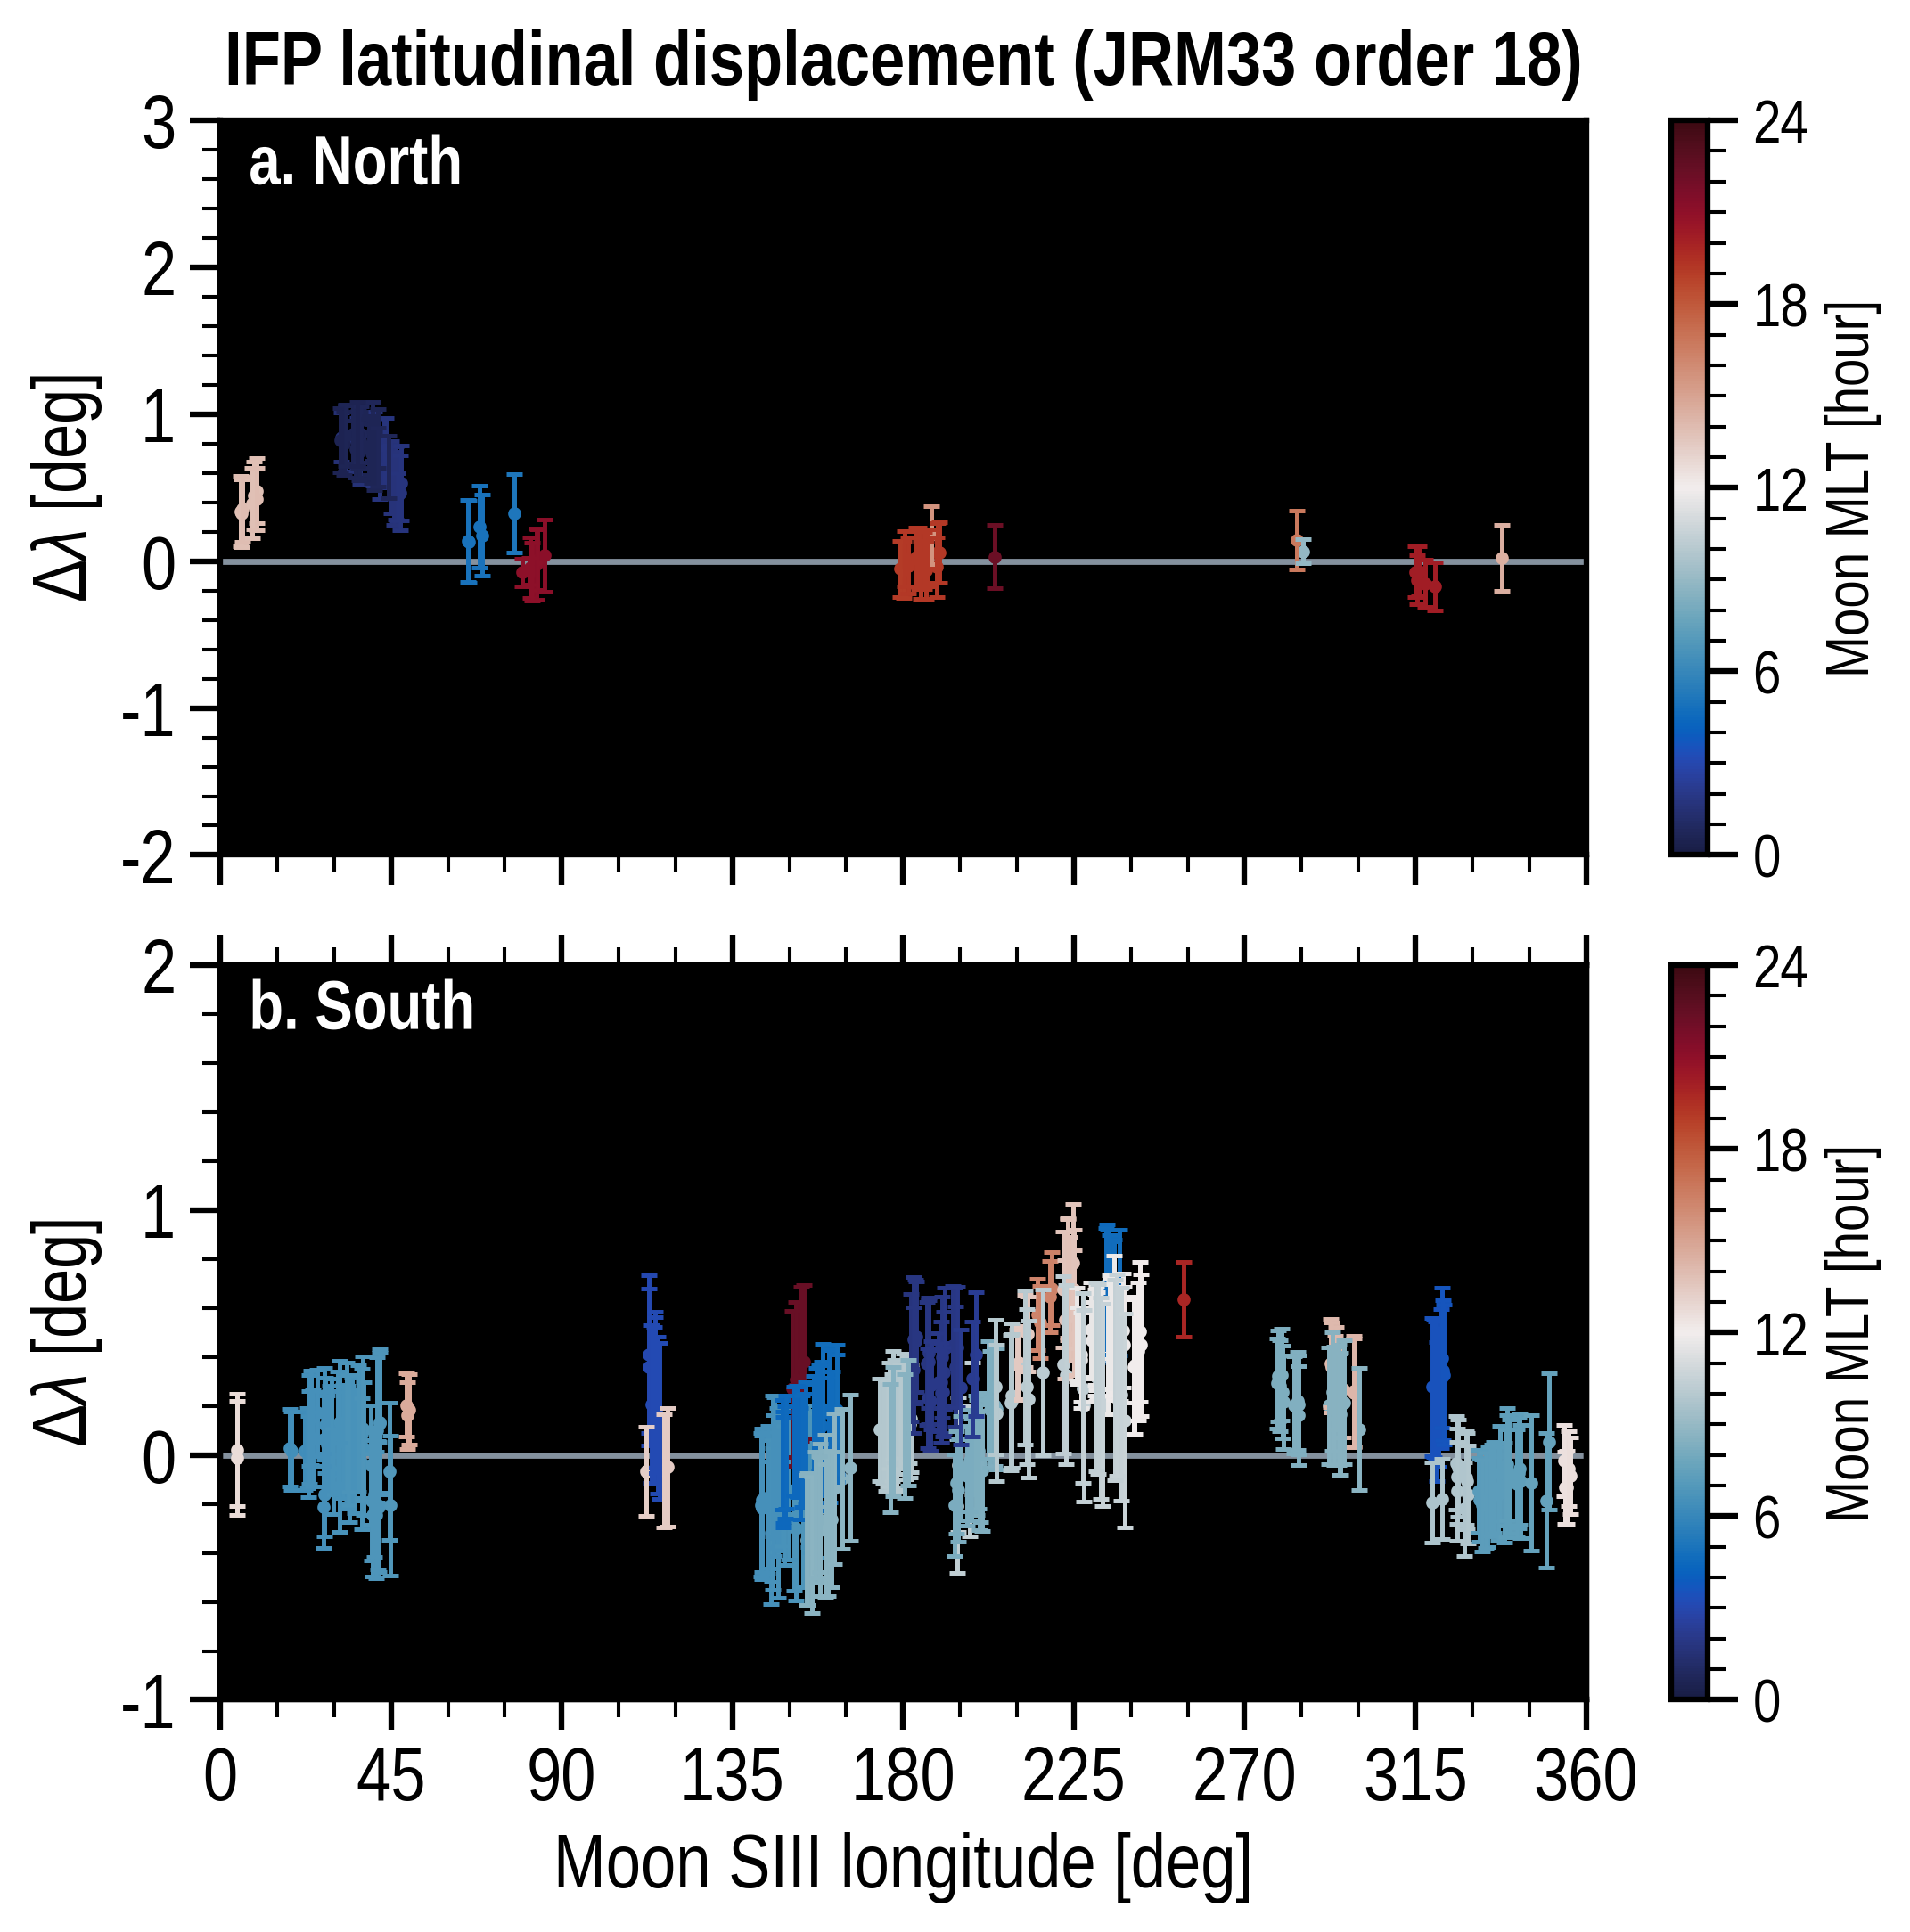

In [77]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(7.2, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Moon SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 0.0
vmax = 24.0
cmap = cmocean.cm.balance
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)

    sc = F.ax[ax_idx].scatter(moon_S3wlon_select[j]-eqlead_fp[j],
                              sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                              s=5.0, c=lt, cmap=cmap, vmin=vmin, vmax=vmax)
    F.ax[ax_idx].errorbar(x=moon_S3wlon_select[j]-eqlead_fp[j],
                          y=sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color=cmap(norm(lt)))

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

for i in range(2):
    F.ax[i].set_facecolor('k')
    F.ax[i].axhline(y=0, color=UC.gray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(0, 24, 5))
    cax.ax.set_yticklabels(np.linspace(
        0, 24, 5, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(6))
    cax.ax.set_ylabel(r'Moon MLT [hour]', fontsize=F.fontsize*0.8)

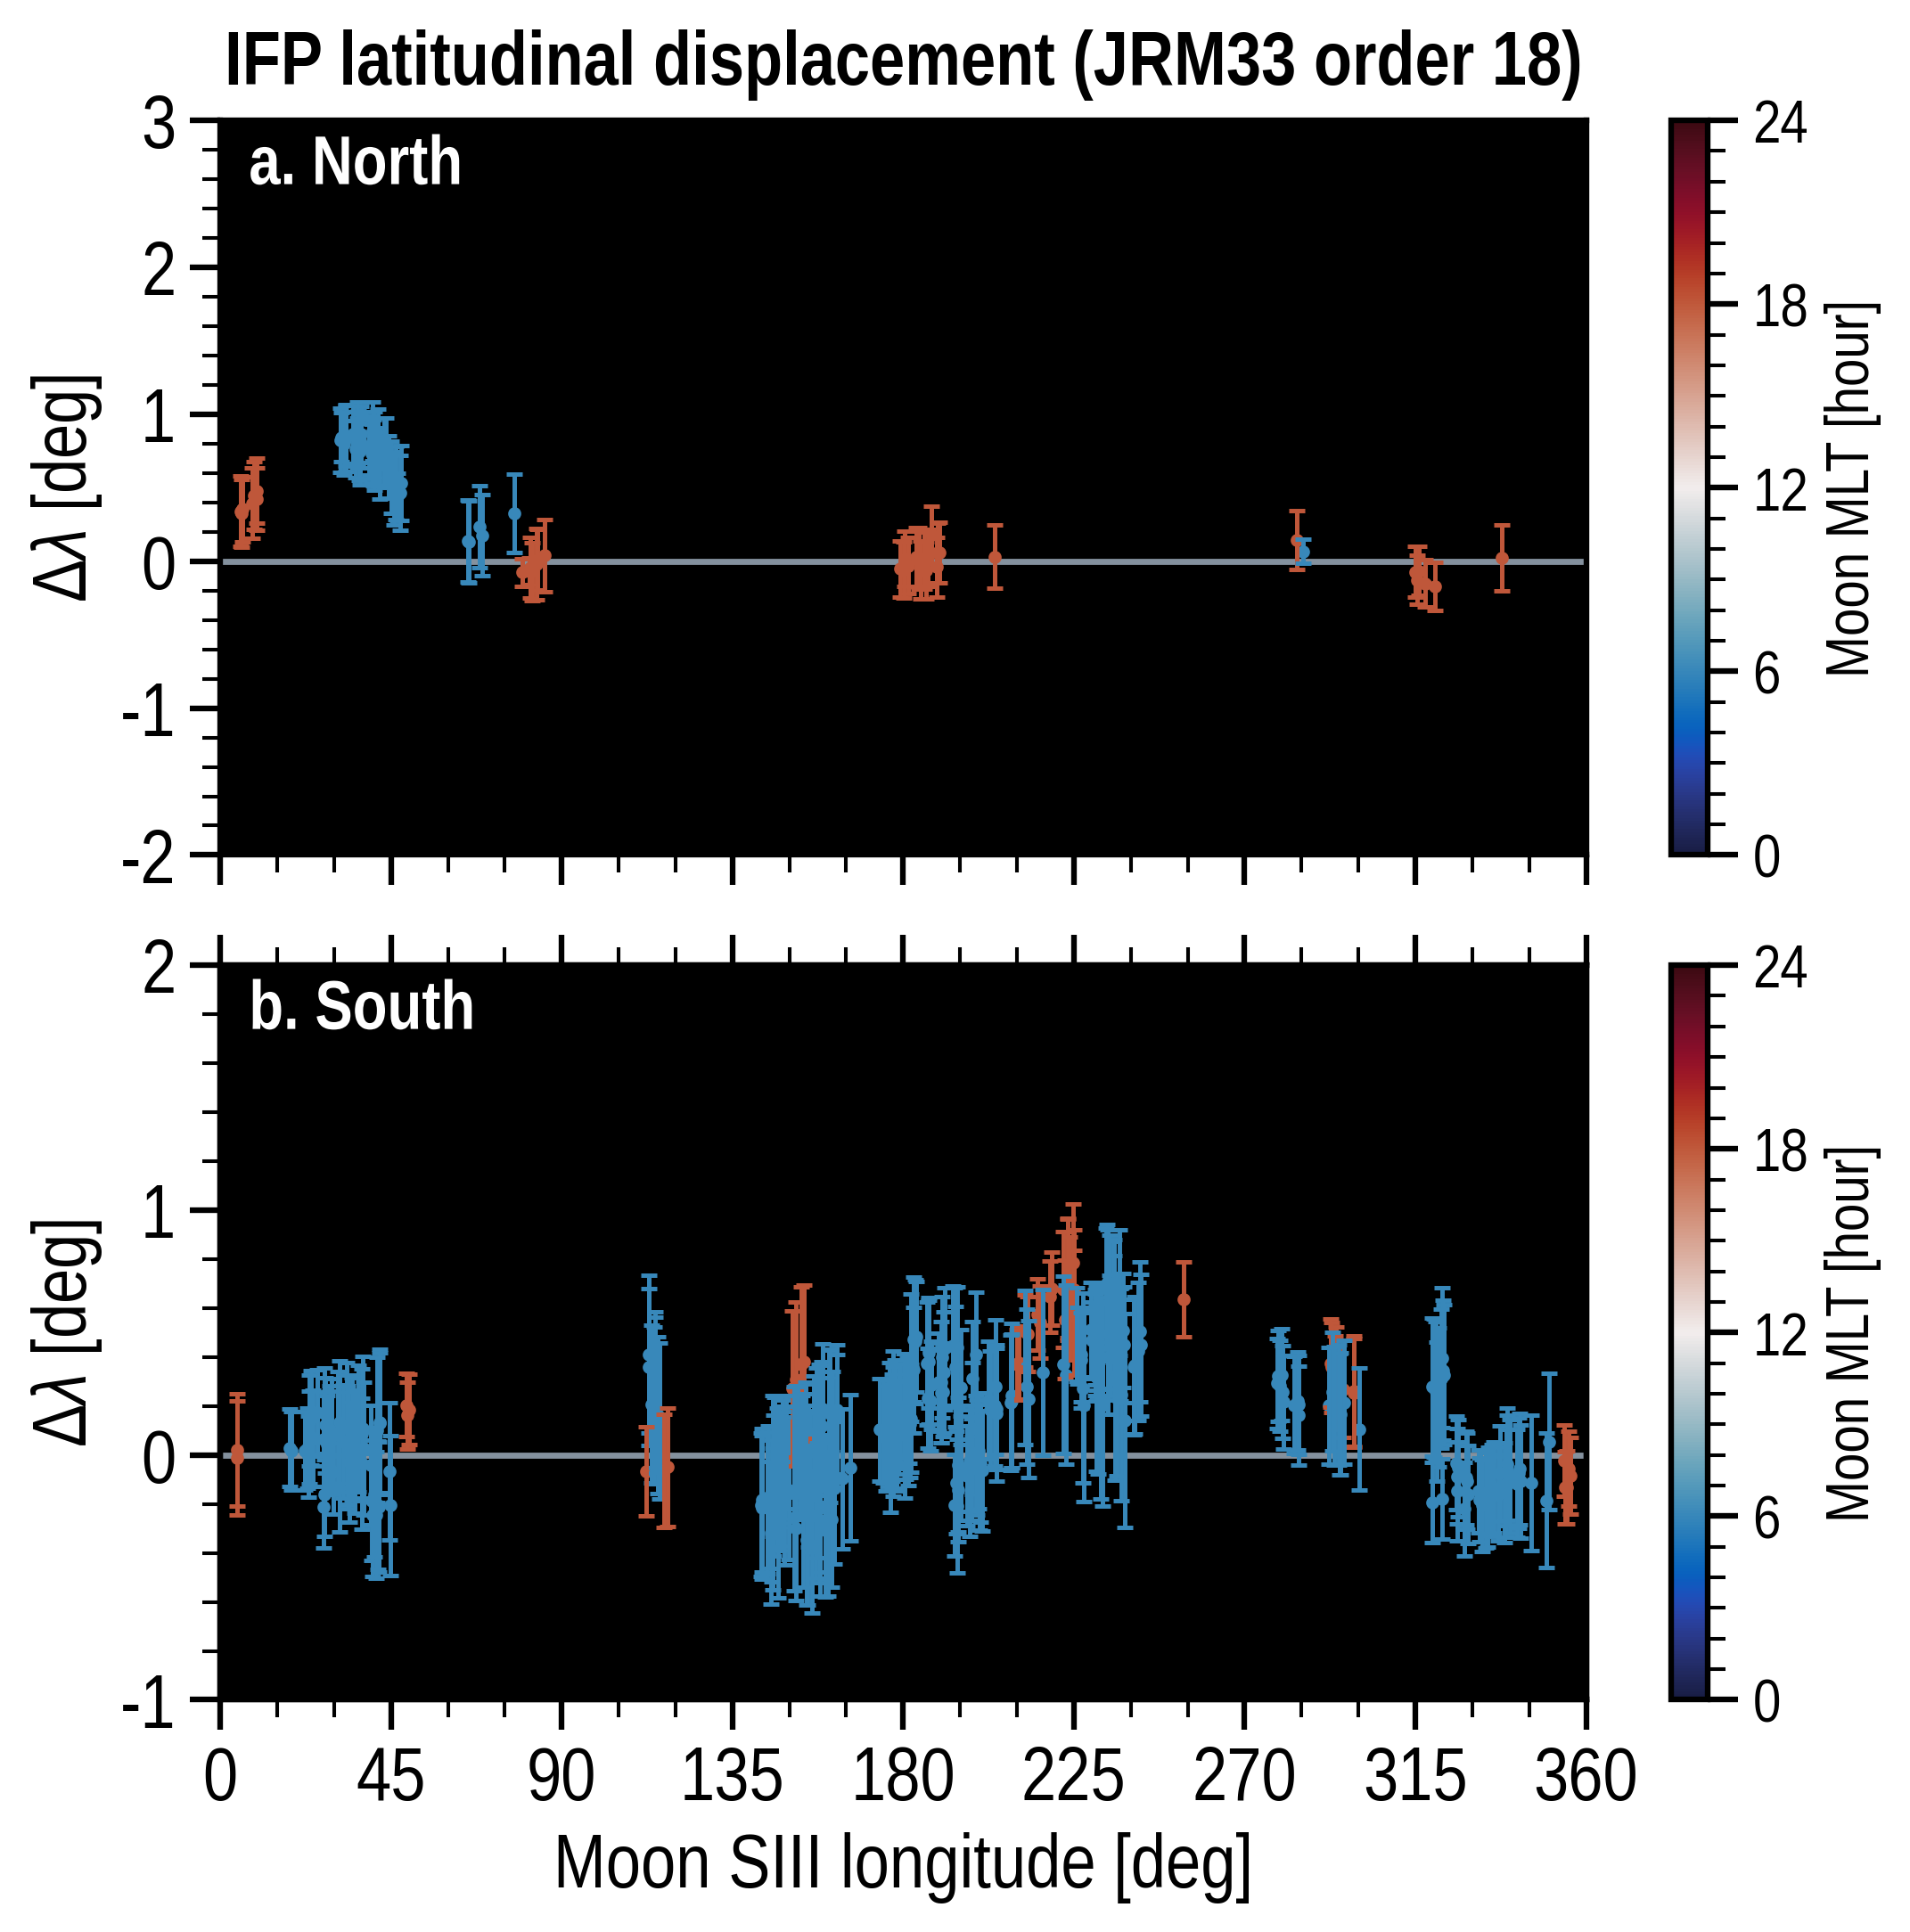

In [78]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(7.2, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Moon SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 0.0
vmax = 24.0
cmap = cmocean.cm.balance
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    r_JSO = IAU2JSO(et=et_fp_select[j],
                    r_IAU=np.array([x_fp_polar, y_fp_polar, z_fp_polar]))

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)
    if lt < 12.0:
        lt = 6.0
    else:
        lt = 18.0
    delta = wlon_fp_select[j]-wlon_defaultfp[j]
    sc = F.ax[ax_idx].scatter(moon_S3wlon_select[j]-eqlead_fp[j],
                              sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                              s=5.0, c=lt, cmap=cmap, vmin=vmin, vmax=vmax)
    F.ax[ax_idx].errorbar(x=moon_S3wlon_select[j]-eqlead_fp[j],
                          y=sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color=cmap(norm(lt)))

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

for i in range(2):
    F.ax[i].set_facecolor('k')
    F.ax[i].axhline(y=0, color=UC.gray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(0, 24, 5))
    cax.ax.set_yticklabels(np.linspace(
        0, 24, 5, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(6))
    cax.ax.set_ylabel(r'Moon MLT [hour]', fontsize=F.fontsize*0.8)

[ 0.12942072  0.14835539  2.29908791  0.16618197  1.75365466 -0.07267446
  1.3612148   0.09015648  1.38292035  0.12931352  0.80216869]


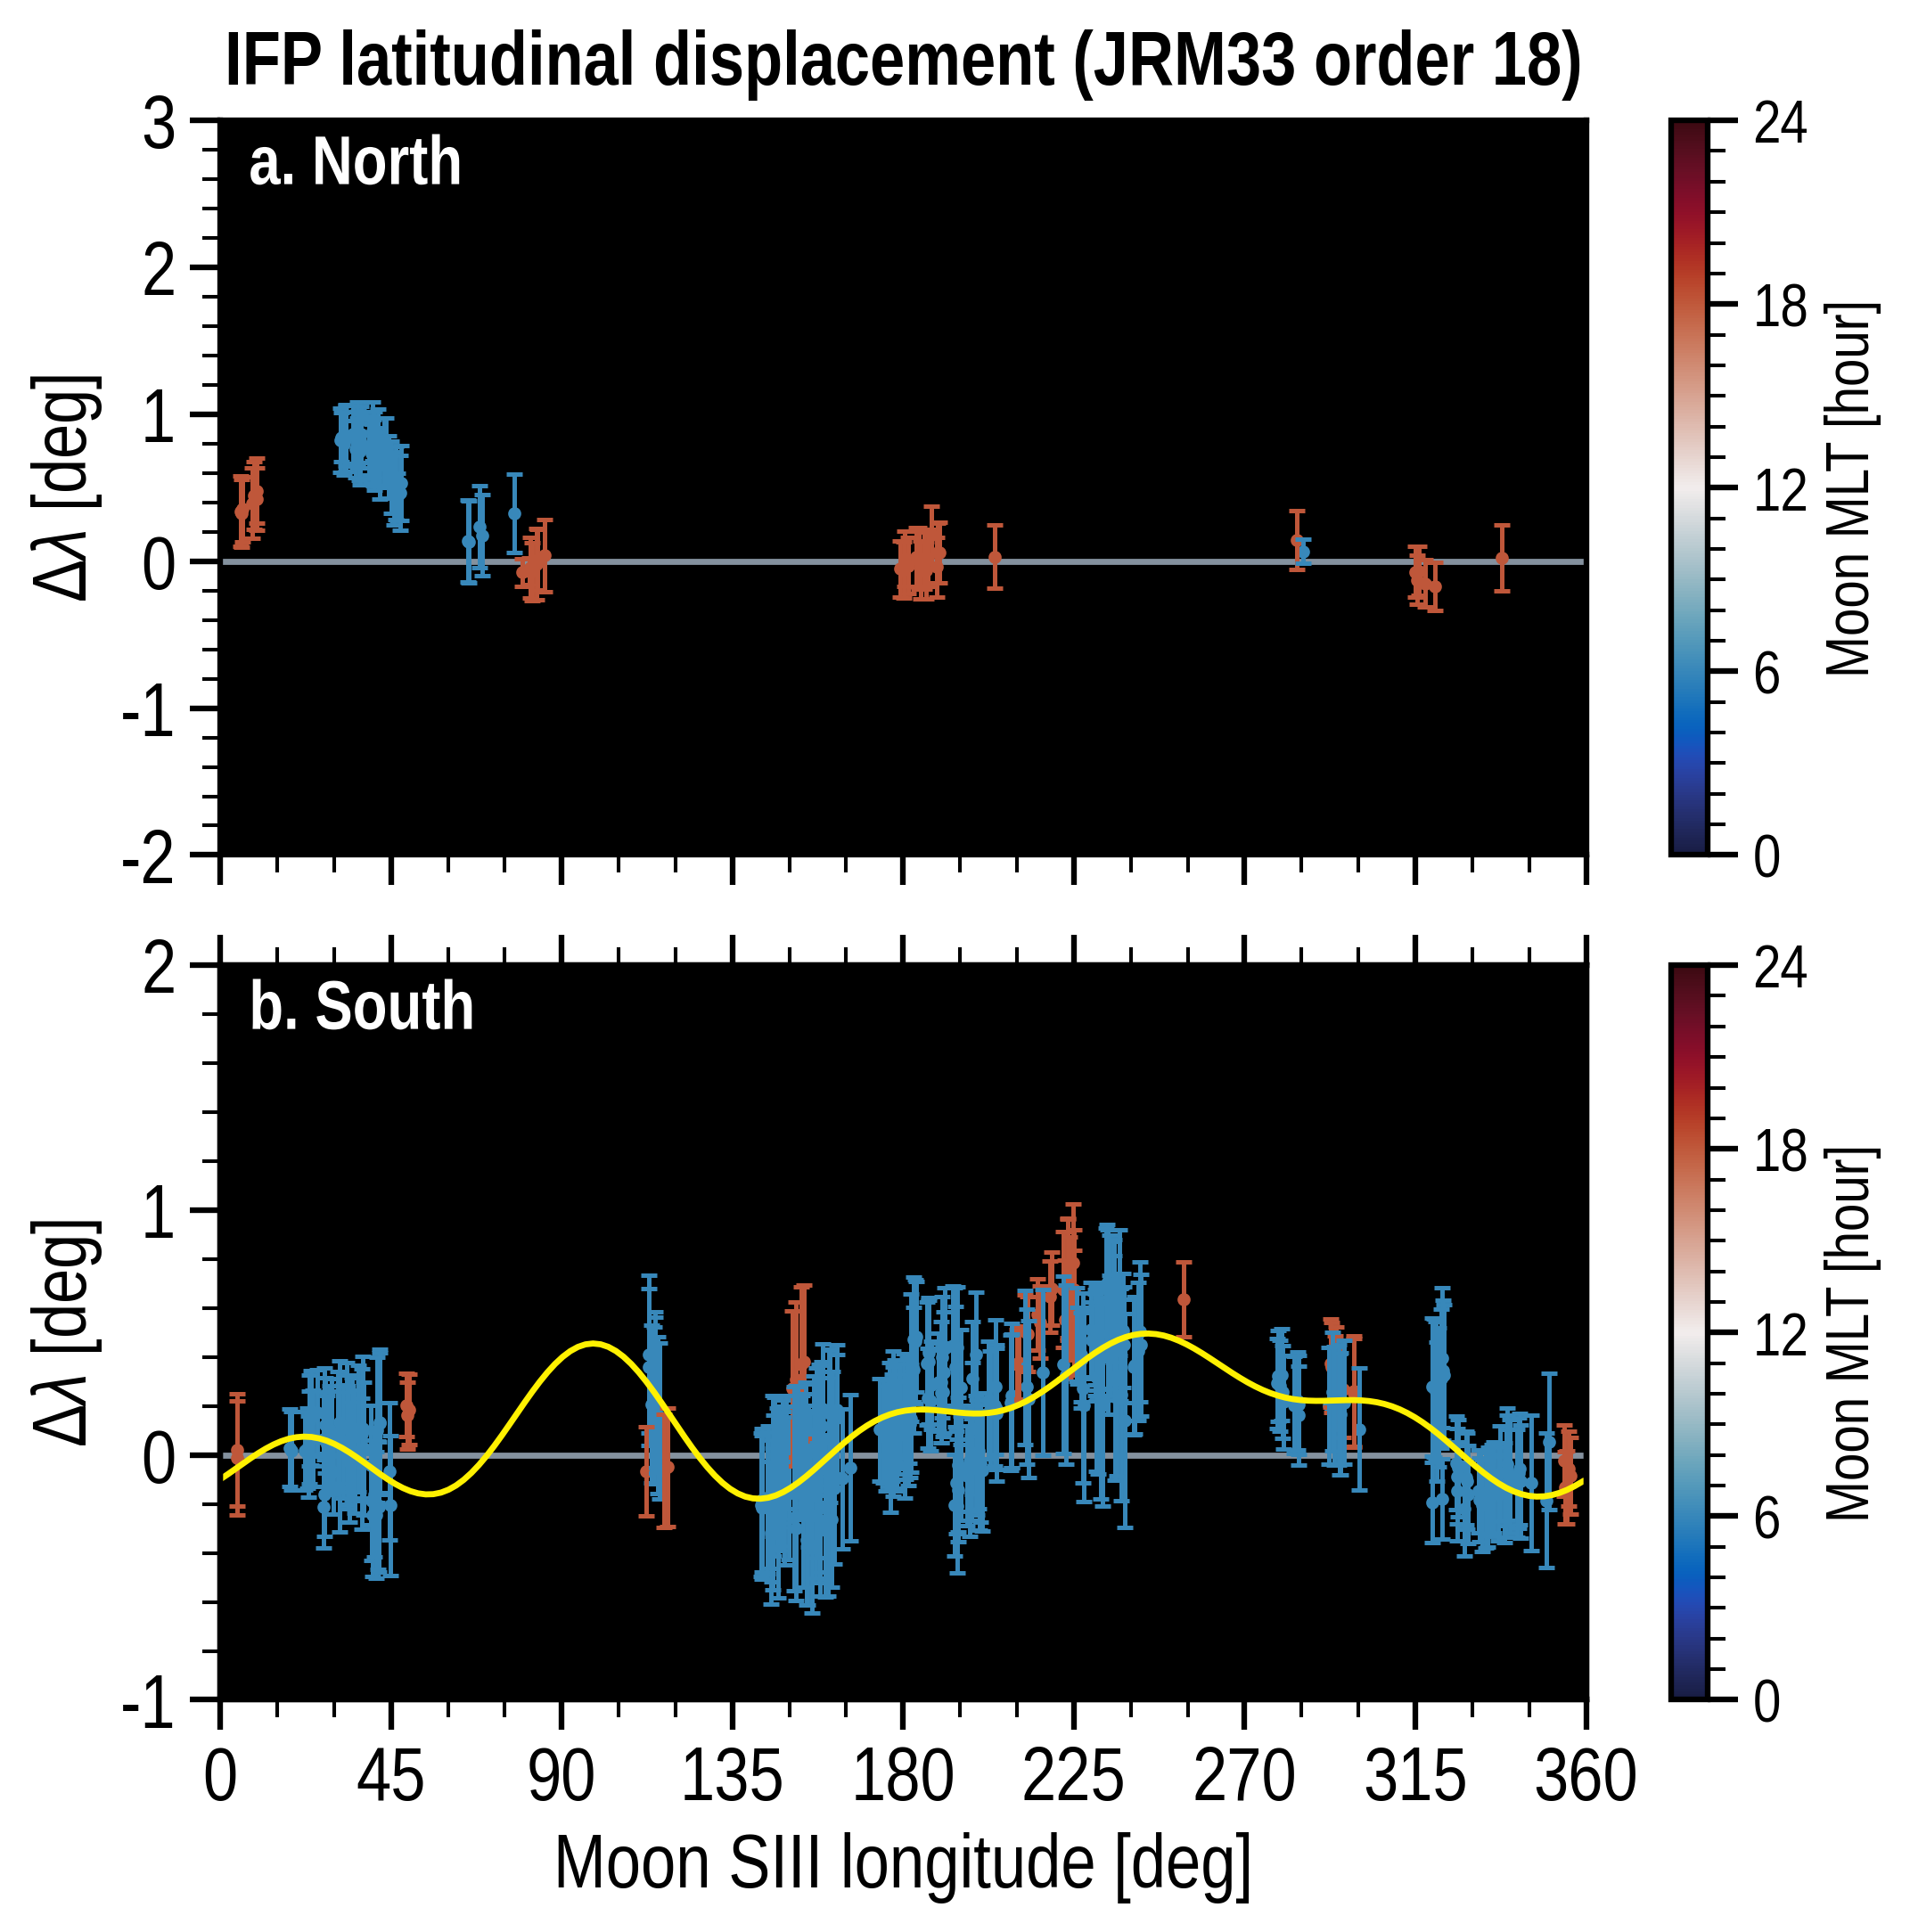

In [69]:
# SIII依存性をフィッティング(南Dawn)
from scipy.optimize import curve_fit


def fitfunc(x, a0, a, b, c, d, e, f, g, h, i, j):
    # x: SIII west longitude [deg]
    phi = np.radians(360.0-x)
    y = a0 + a*np.cos(phi-b) + c*np.cos(2.0*(phi-d)) + \
        e*np.cos(3.0*(phi-f)) + g*np.cos(4.0*(phi-h)) + i*np.cos(5.0*(phi-j))
    return y


F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(7.2, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Moon SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 0.0
vmax = 24.0
cmap = cmocean.cm.balance
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

dawn_N = []
dawn_S = []
dawn_N_moonS3wlon = []
dawn_S_moonS3wlon = []
for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        data_list_j = dawn_N
        data_list_j_moonS3wlon = dawn_N_moonS3wlon
    else:
        ax_idx = 1
        sgn = -1
        data_list_j = dawn_S
        data_list_j_moonS3wlon = dawn_S_moonS3wlon

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    r_JSO = IAU2JSO(et=et_fp_select[j],
                    r_IAU=np.array([x_fp_polar, y_fp_polar, z_fp_polar]))

    delta = wlon_fp_select[j]-wlon_defaultfp[j]
    lt = local_time_moon(et_fp_select[j], TARGET_MOON)
    if lt < 12.0:
        lt = 6.0
        data_list_j += [sgn*(lat_fp_select[j]-lat_defaultfp_18[j])]
        data_list_j_moonS3wlon += [moon_S3wlon_select[j]-eqlead_fp[j]]
    else:
        lt = 18.0
    sc = F.ax[ax_idx].scatter(moon_S3wlon_select[j]-eqlead_fp[j],
                              sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                              s=5.0, c=lt, cmap=cmap, vmin=vmin, vmax=vmax)
    F.ax[ax_idx].errorbar(x=moon_S3wlon_select[j]-eqlead_fp[j],
                          y=sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color=cmap(norm(lt)))

# Dawn fitting
sort = np.argsort(np.array(dawn_S_moonS3wlon))
popt, pcov = curve_fit(fitfunc,
                       np.array(dawn_S_moonS3wlon)[sort],
                       np.array(dawn_S)[sort])
print(popt)
x_fit = np.linspace(0, 359.0, 180)
y_fit = fitfunc(x_fit, popt[0], popt[1], popt[2], popt[3],
                popt[4], popt[5], popt[6], popt[7], popt[8],
                popt[9], popt[10])
F.ax[1].plot(x_fit, y_fit, color=UC.yellow)

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

for i in range(2):
    F.ax[i].set_facecolor('k')
    F.ax[i].axhline(y=0, color=UC.gray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(0, 24, 5))
    cax.ax.set_yticklabels(np.linspace(
        0, 24, 5, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(6))
    cax.ax.set_ylabel(r'Moon MLT [hour]', fontsize=F.fontsize*0.8)

[ 0.18513747 -0.06860348 -0.29972678 -0.23818182  0.2748892   0.142919
  0.59115245 -0.08217009  0.73684236  0.13327054  0.94048678]


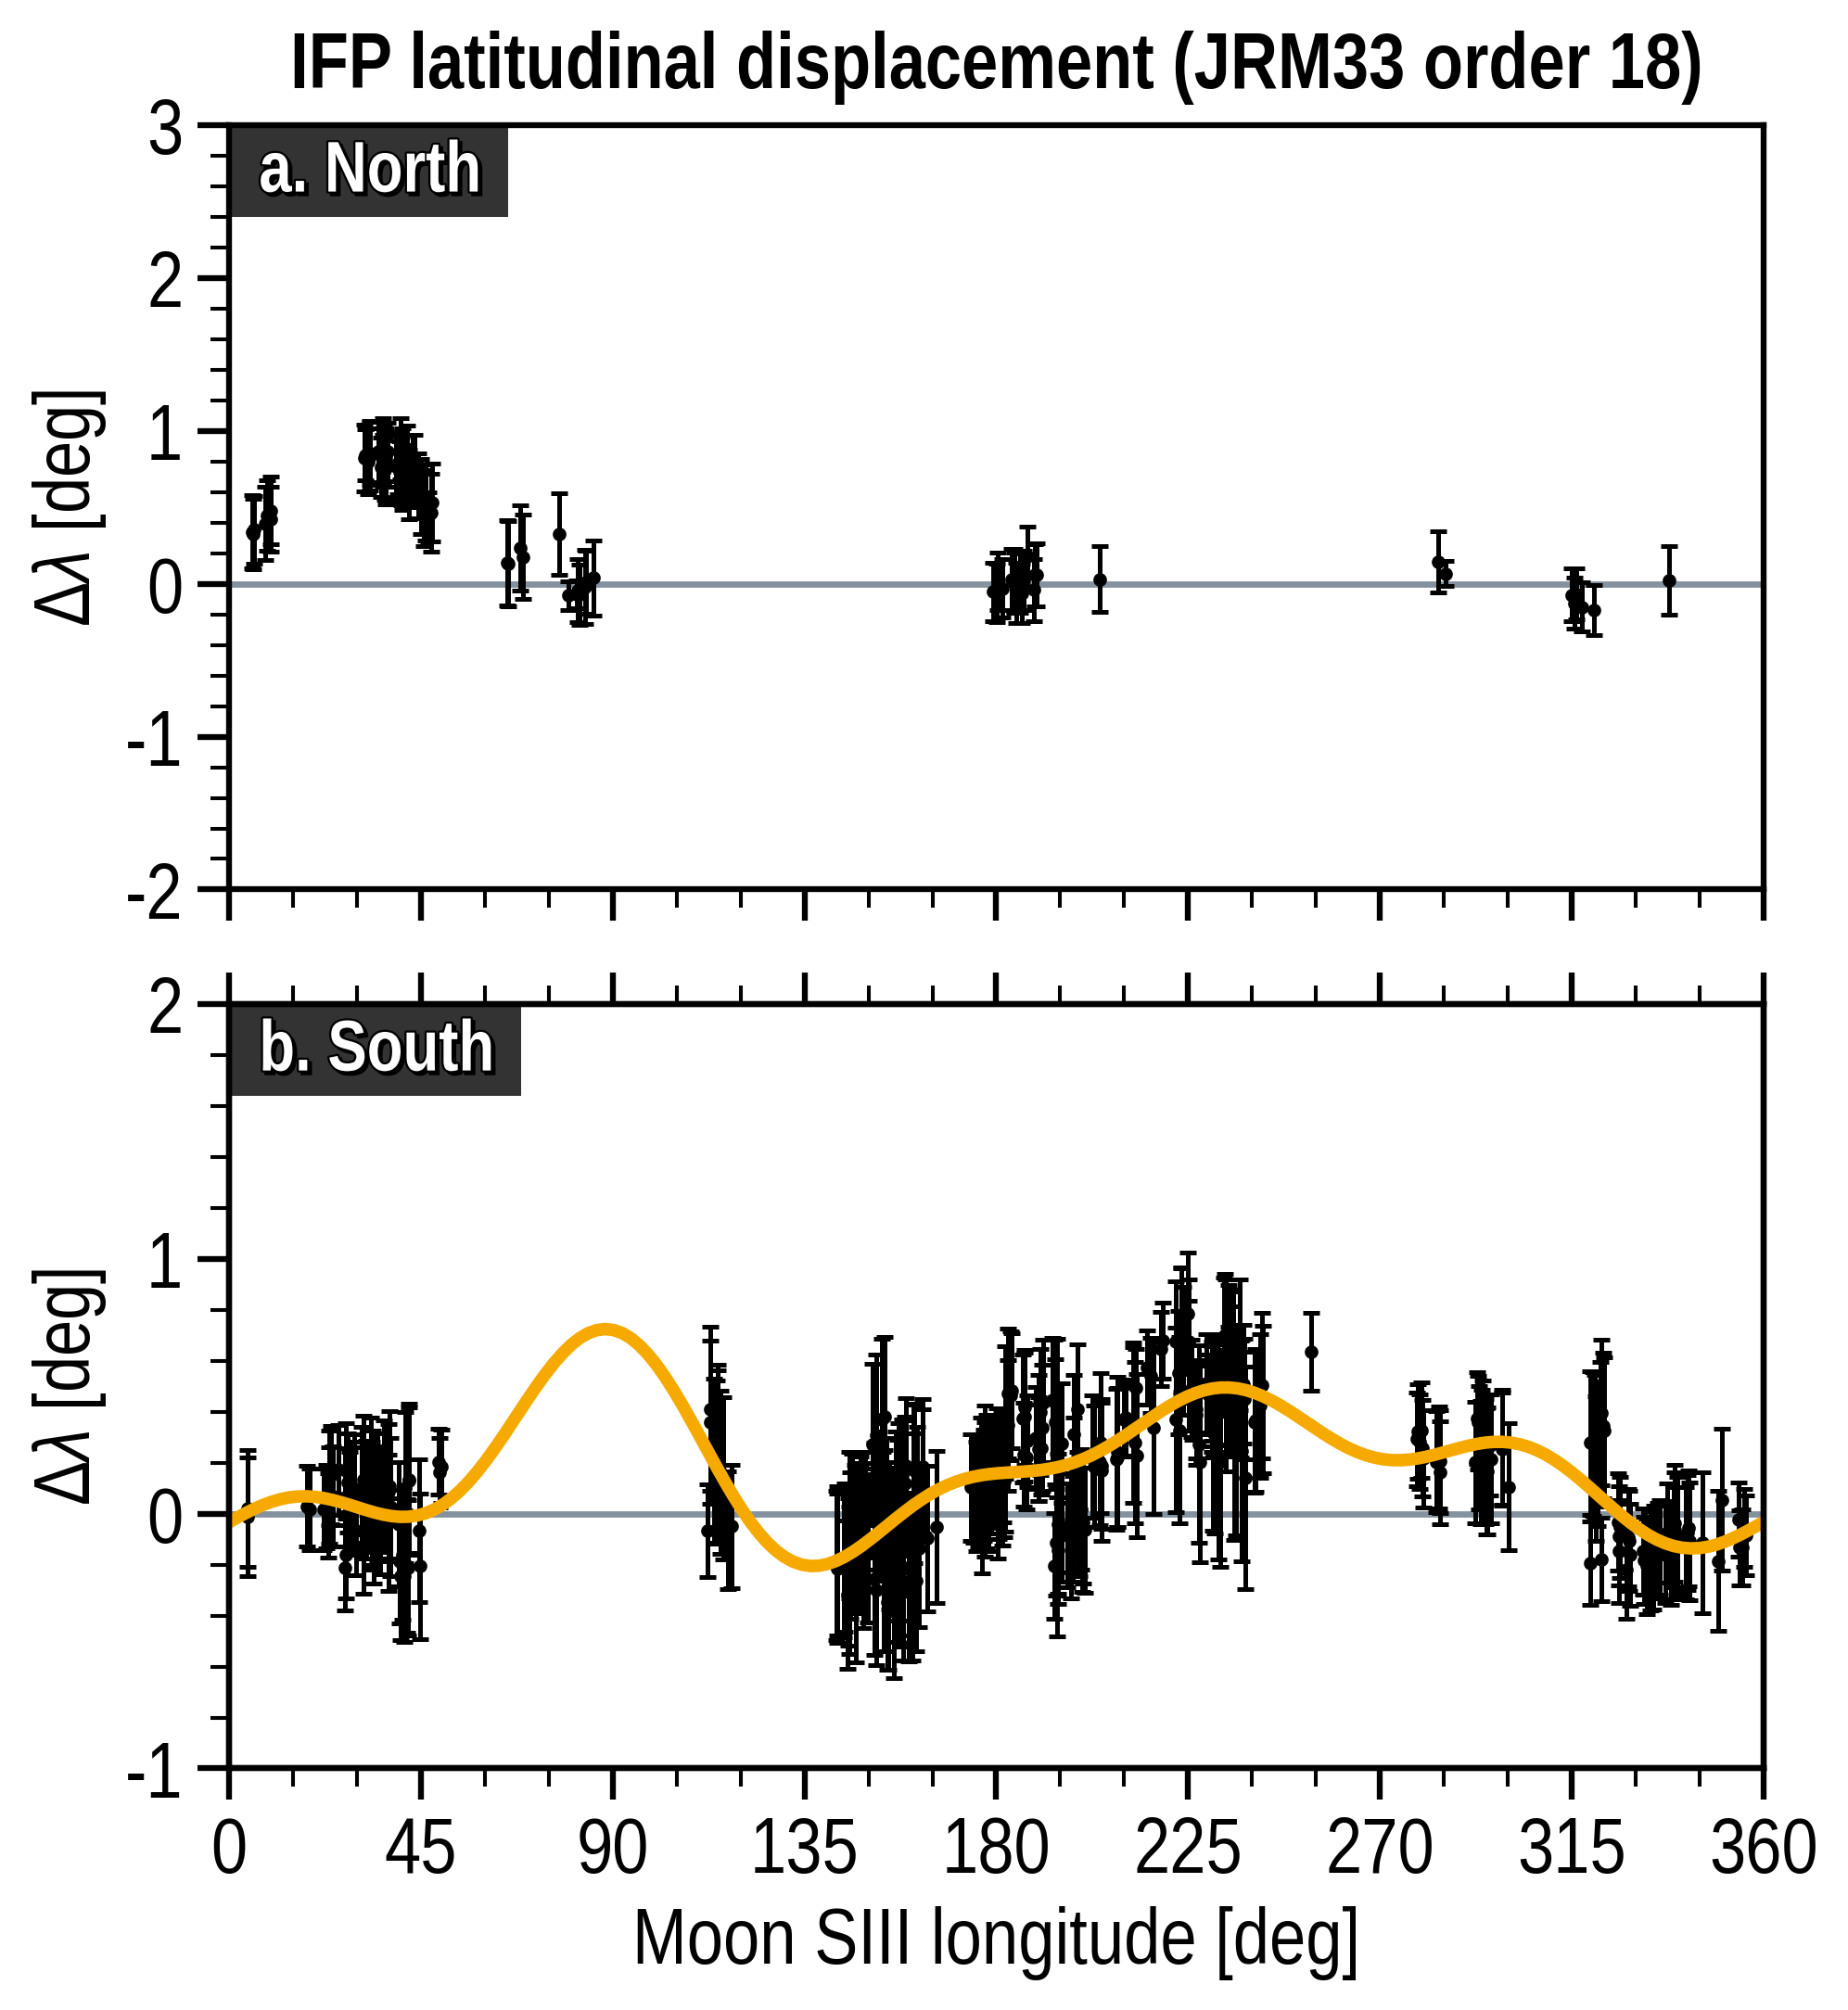

In [72]:
# SIII依存性をフィッティング(南Dawn)
from scipy.optimize import curve_fit


def fitfunc(x, a0, a, b, c, d, e, f, g, h, i, j):
    # x: SIII west longitude [deg]
    phi = np.radians(360.0-x)
    y = a0 + a*np.cos(phi-b) + c*np.cos(2.0*(phi-d)) + \
        e*np.cos(3.0*(phi-f)) + g*np.cos(4.0*(phi-h)) + i*np.cos(5.0*(phi-j))
    return y


F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(6.4, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Moon SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 0.0
vmax = 24.0
cmap = cmocean.cm.balance
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

deltalat_N = []
deltalat_S = []
moonS3wlon_N = []
moonS3wlon_S = []
for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        data_list_j = deltalat_N
        data_list_j_moonS3wlon = moonS3wlon_N
    else:
        ax_idx = 1
        sgn = -1
        data_list_j = deltalat_S
        data_list_j_moonS3wlon = moonS3wlon_S

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    r_JSO = IAU2JSO(et=et_fp_select[j],
                    r_IAU=np.array([x_fp_polar, y_fp_polar, z_fp_polar]))

    delta = wlon_fp_select[j]-wlon_defaultfp[j]
    lt = 12

    data_list_j_moonS3wlon += [moon_S3wlon_select[j]-eqlead_fp[j]]
    data_list_j += [sgn*(lat_fp_select[j]-lat_defaultfp_18[j])]

    sc = F.ax[ax_idx].scatter(moon_S3wlon_select[j]-eqlead_fp[j],
                              sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                              s=5.0, c='k')
    F.ax[ax_idx].errorbar(x=moon_S3wlon_select[j]-eqlead_fp[j],
                          y=sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color='k')

# South fitting
sort = np.argsort(np.array(moonS3wlon_S))
popt_s3, pcov = curve_fit(fitfunc,
                          np.array(moonS3wlon_S)[sort],
                          np.array(deltalat_S)[sort])
print(popt_s3)
x_fit = np.linspace(0, 359.0, 180)
y_fit = fitfunc(x_fit, popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3],
                popt_s3[4], popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8],
                popt_s3[9], popt_s3[10])
F.ax[1].plot(x_fit, y_fit, linewidth=3.0, color=UC.orange)

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.gray, zorder=0.9)

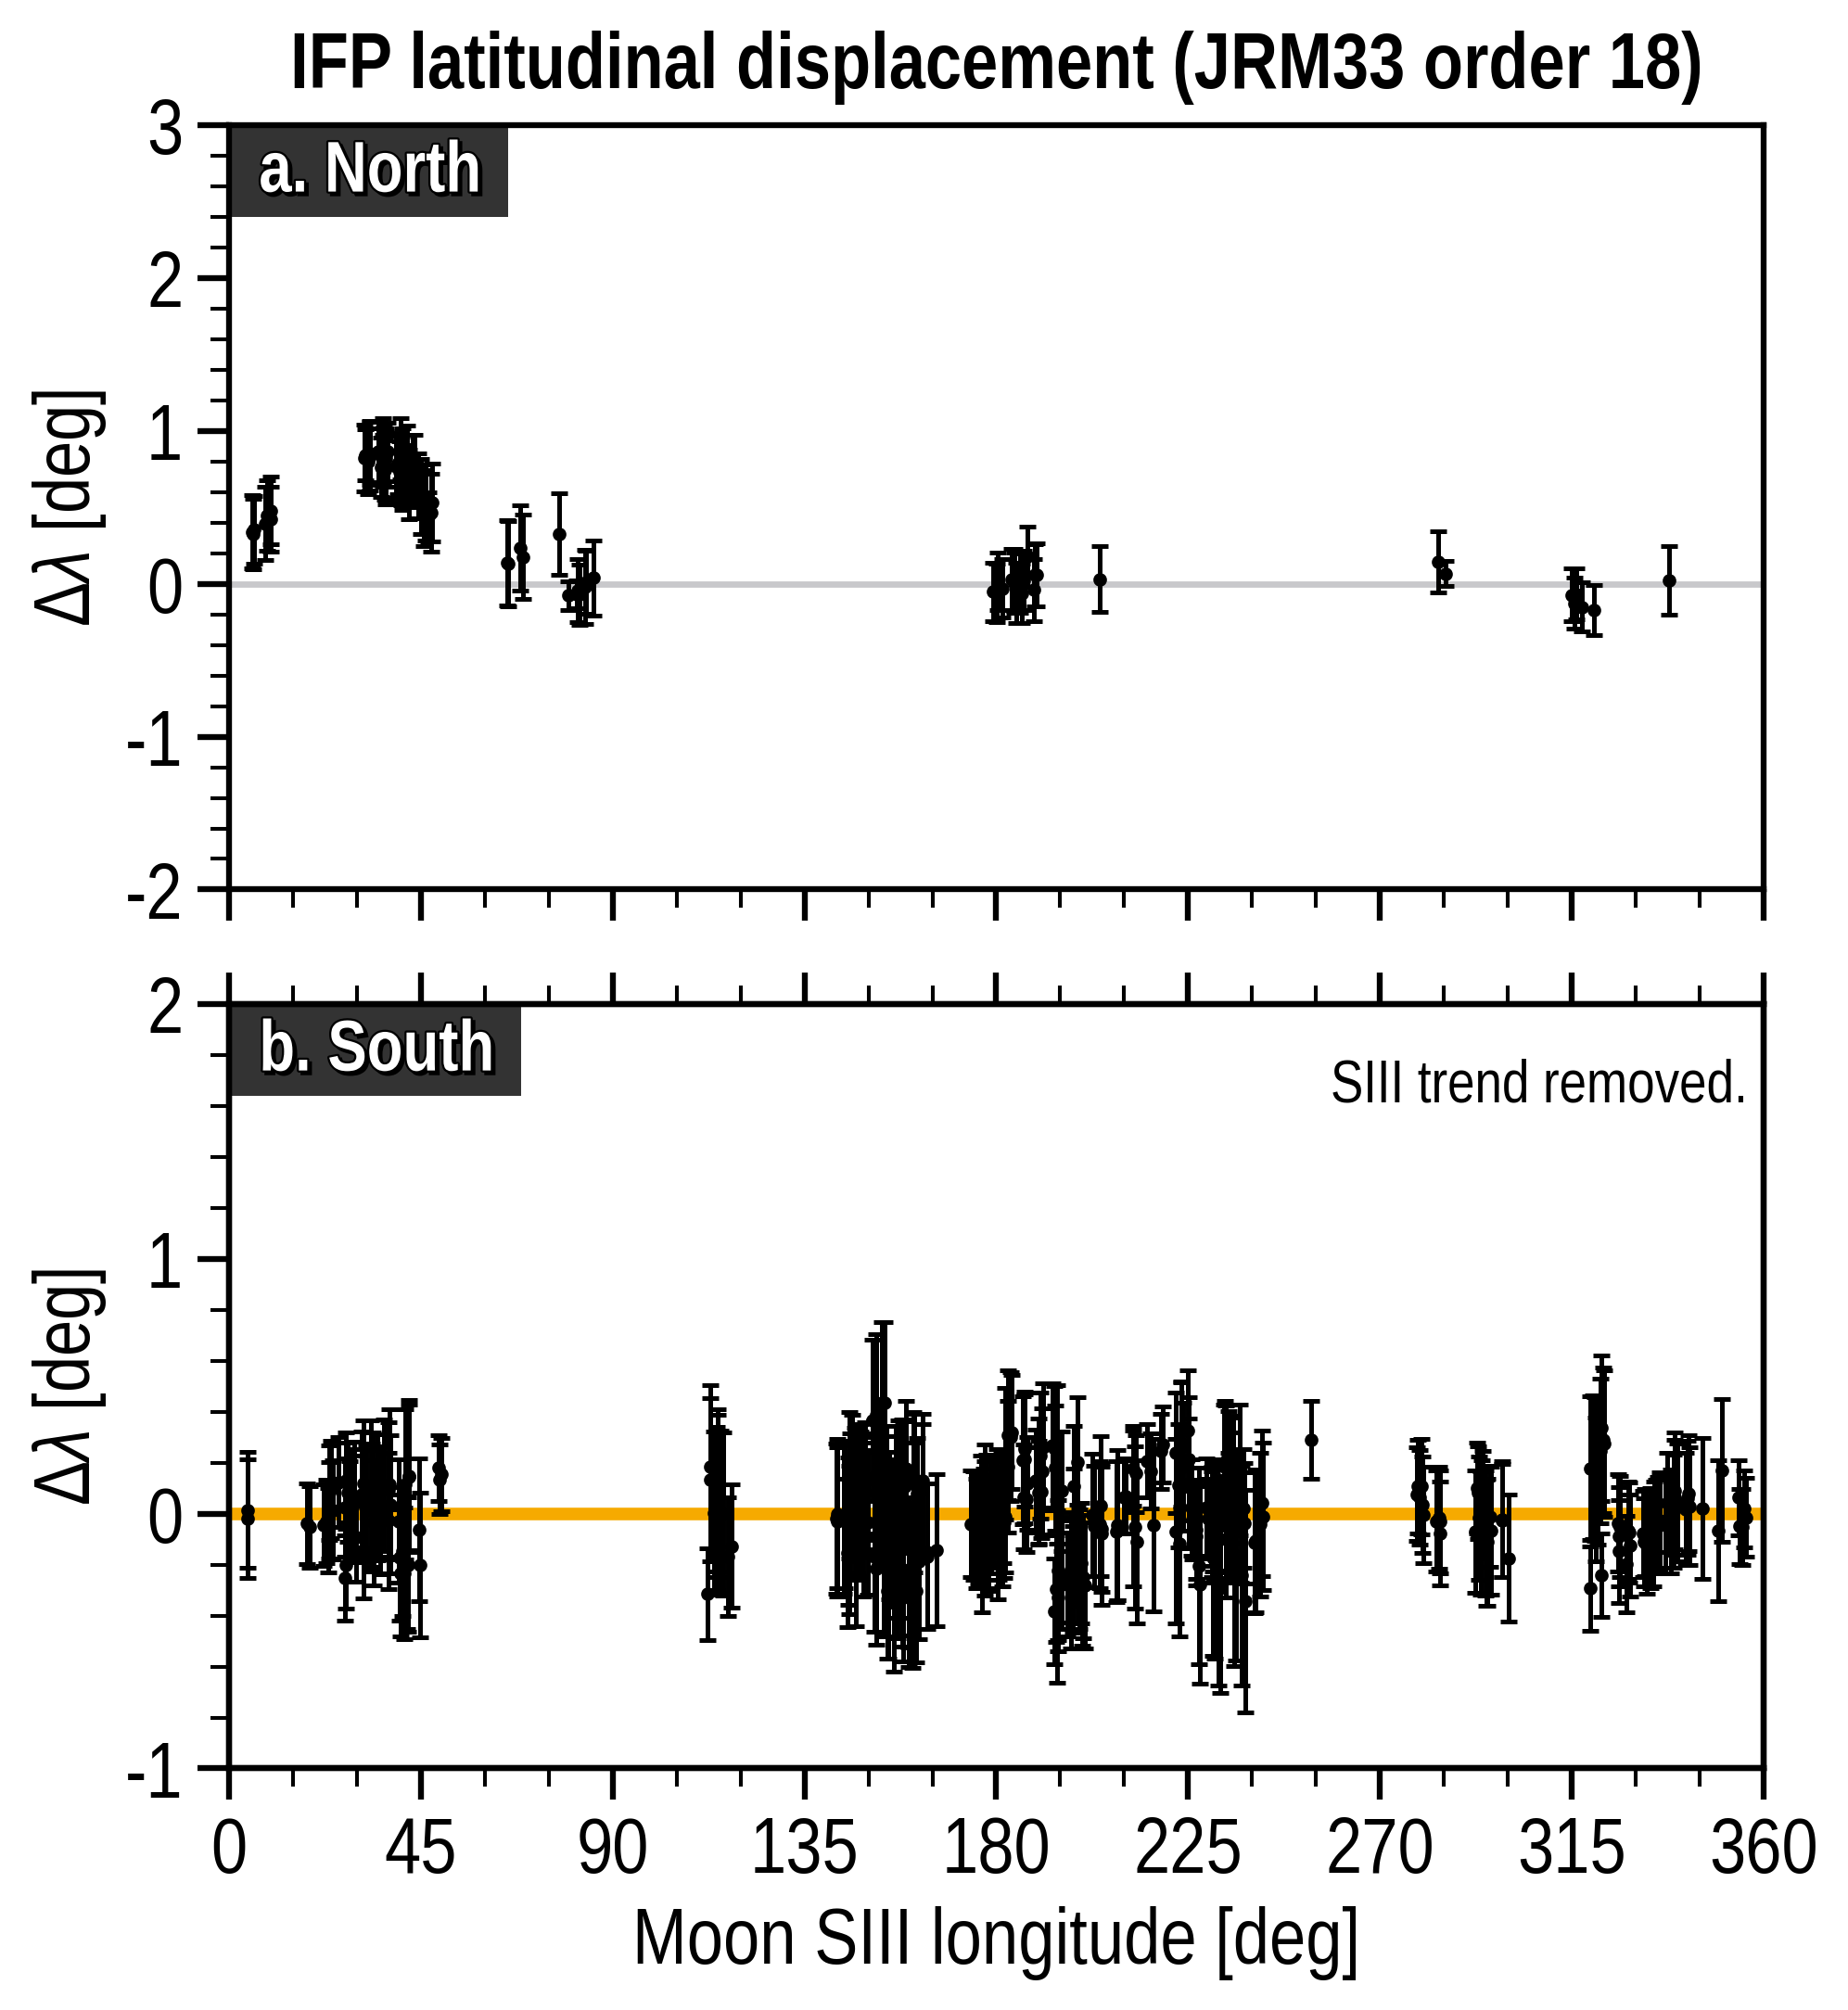

In [73]:
# SIII依存性をフィッティングして差し引く(南Dawn)
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(6.4, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Moon SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 0.0
vmax = 24.0
cmap = cmocean.cm.balance
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
    else:
        ax_idx = 1
        sgn = -1

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    r_JSO = IAU2JSO(et=et_fp_select[j],
                    r_IAU=np.array([x_fp_polar, y_fp_polar, z_fp_polar]))

    if hem_fp_select[j] < 0:
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])
    else:
        y_fit = fitfunc(moon_S3wlon_select[j]-eqlead_fp[j],
                        popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3],
                        popt_s3[4], popt_s3[5], popt_s3[6], popt_s3[7],
                        popt_s3[8], popt_s3[9], popt_s3[10])
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j]) - y_fit

    sc = F.ax[ax_idx].scatter(moon_S3wlon_select[j]-eqlead_fp[j],
                              y,
                              s=5.0, c='k')
    F.ax[ax_idx].errorbar(x=moon_S3wlon_select[j]-eqlead_fp[j],
                          y=y,
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color='k')

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

F.ax[1].text(0.99, 0.93, r'SIII trend removed.',
             color='k',
             fontsize=F.fontsize*0.75,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

F.ax[0].axhline(y=0, color=UC.lightgray, zorder=0.9)
F.ax[1].axhline(y=0, linewidth=3.0, color=UC.orange, zorder=0.9)

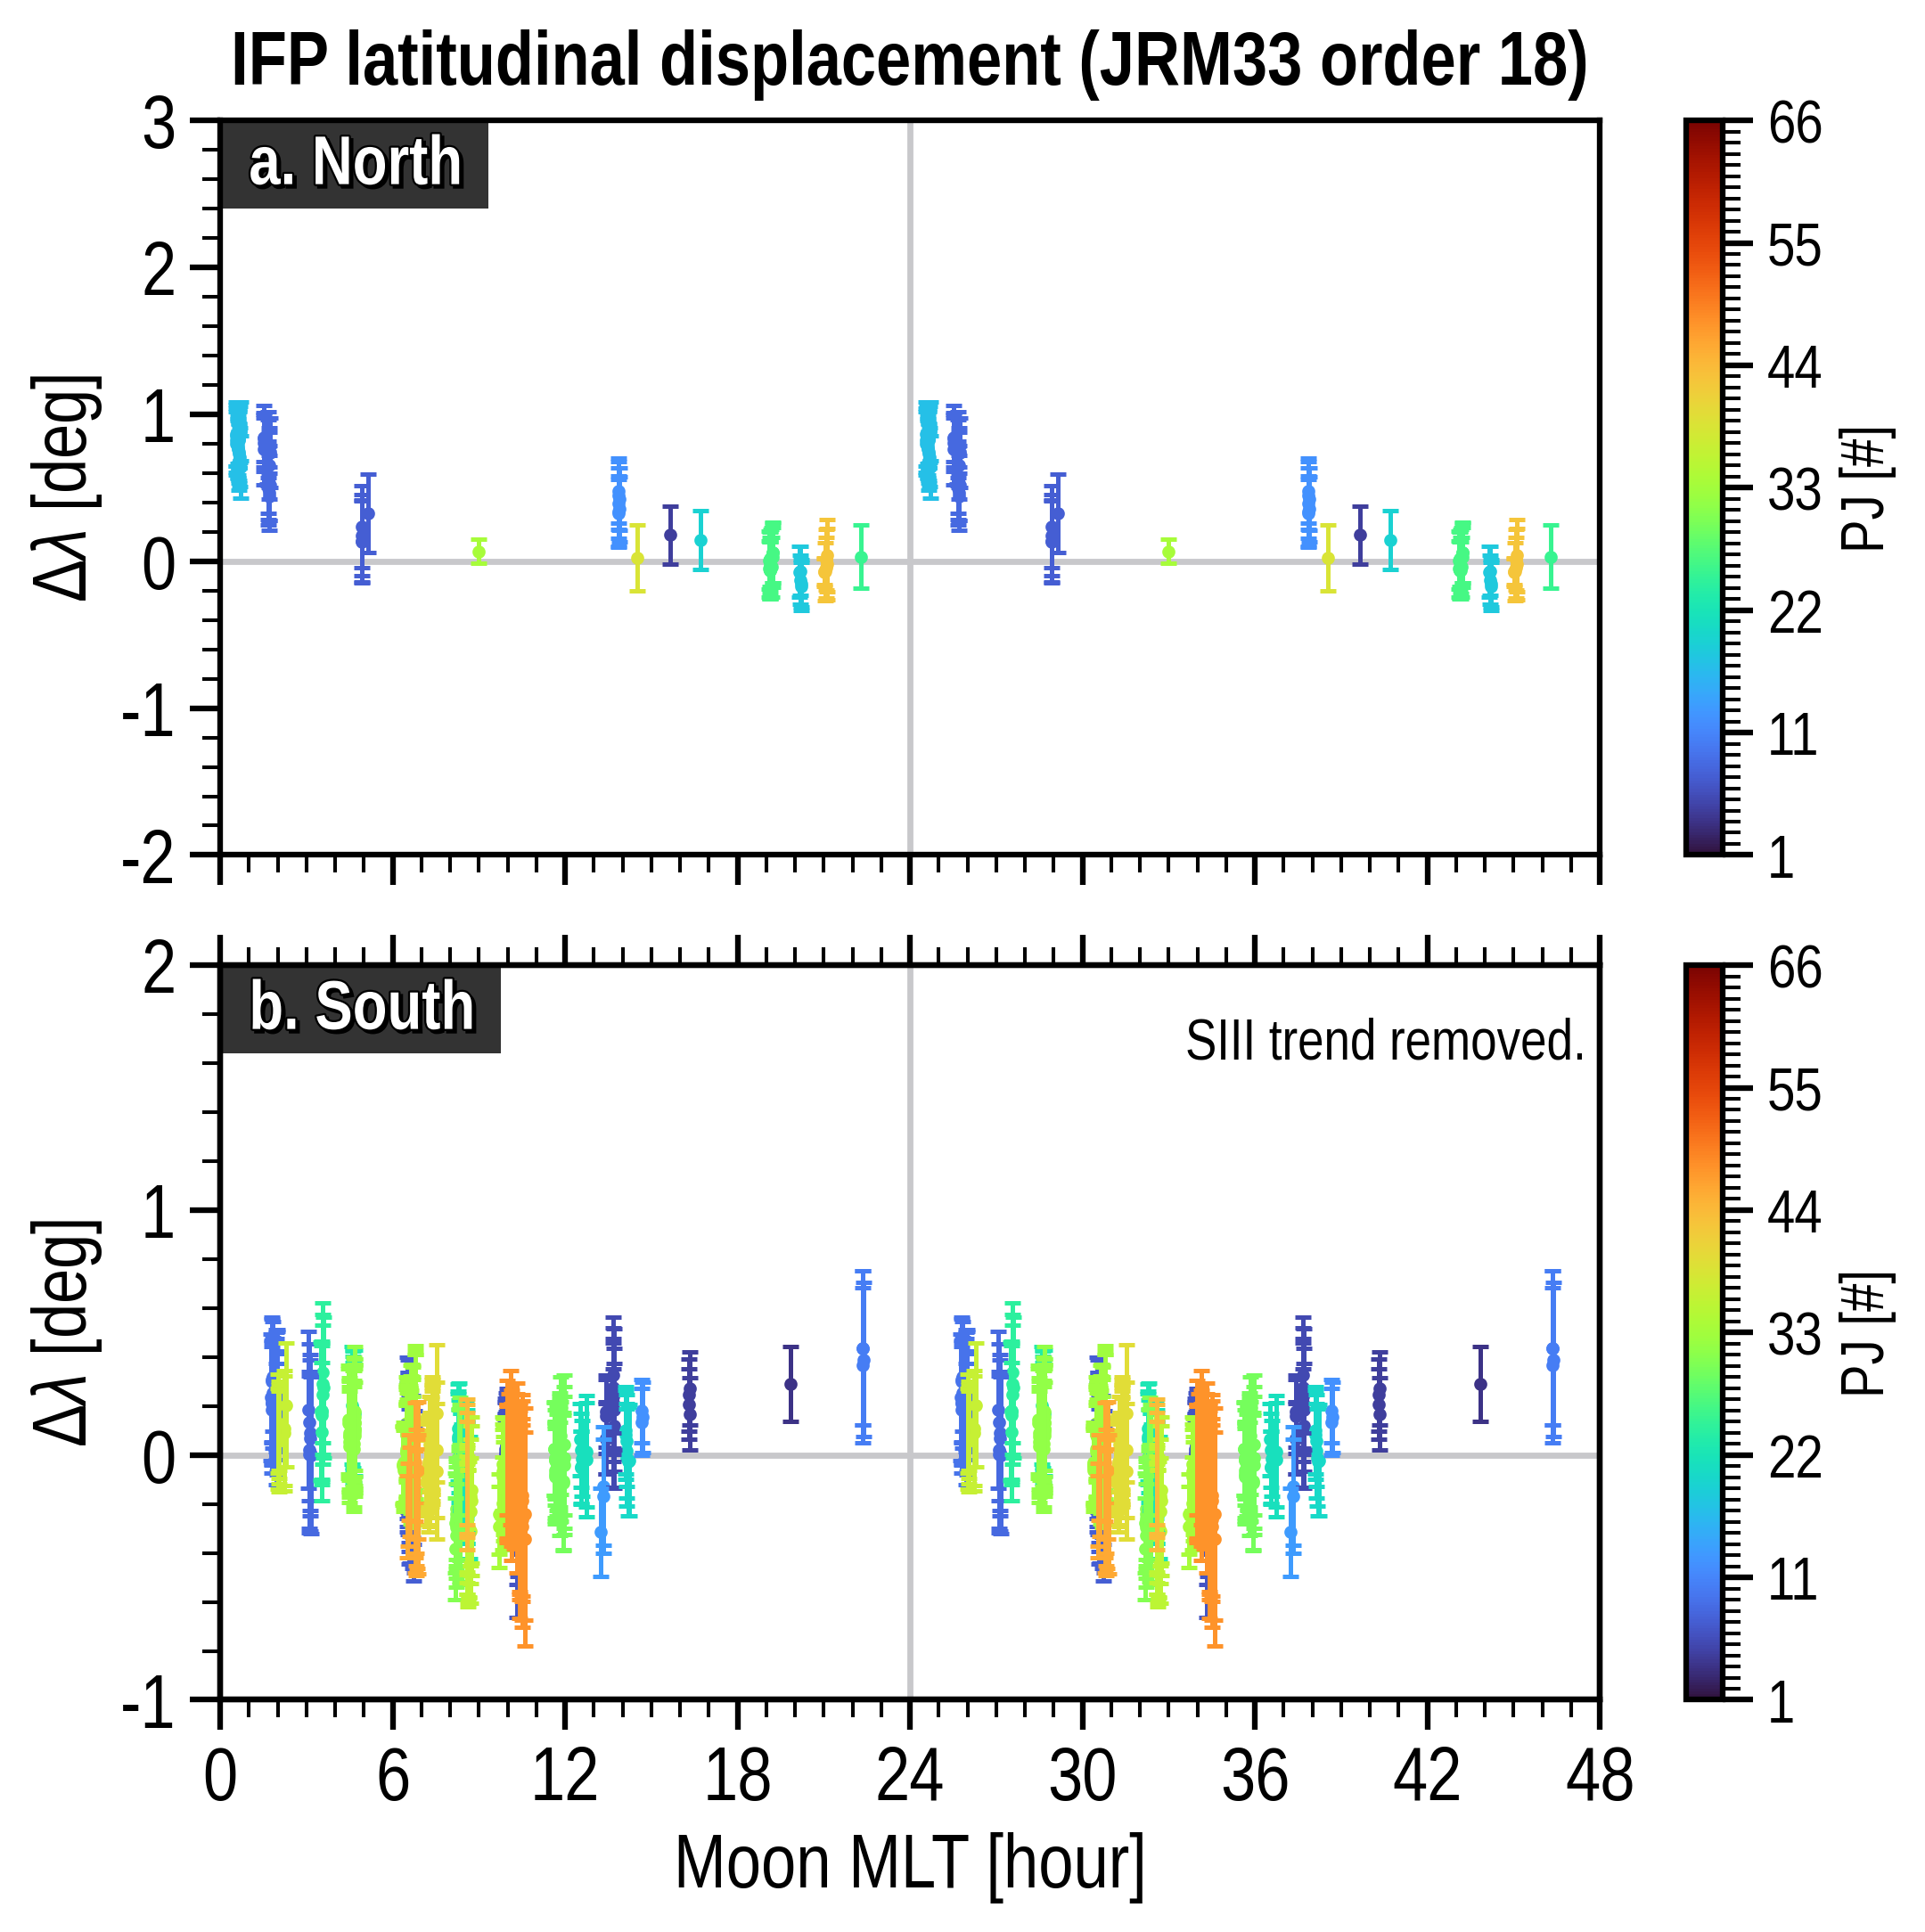

In [74]:
# SIII依存性を差し引いてMLT依存性を見る(南半球)
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(7.2, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)

    if hem_fp_select[j] < 0:
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])
    else:
        SIII_fit = fitfunc(moon_S3wlon_select[j]-eqlead_fp[j],
                           popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3], popt_s3[4],
                           popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8], popt_s3[9],
                           popt_s3[10])
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])-SIII_fit

    for i in range(2):
        sc = F.ax[ax_idx].scatter(lt+24.0*i,
                                  y,
                                  s=5.0, c=pj_fp[j], cmap=cmap, vmin=vmin, vmax=vmax)
        F.ax[ax_idx].errorbar(x=lt+24.0*i,
                              y=y,
                              yerr=err_lat_fp_select[j],
                              elinewidth=1.1, linewidth=0., markersize=0.,
                              capsize=2.0, capthick=1.1,
                              color=cmap(norm(pj_fp[j])))

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

F.ax[1].text(0.99, 0.93, r'SIII trend removed.',
             color='k',
             fontsize=F.fontsize*0.75,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    F.ax[i].axvline(x=24.0, color=UC.lightgray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(1, 66, 7))
    cax.ax.set_yticklabels(np.linspace(
        1, 66, 7, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(11))
    cax.ax.set_ylabel(r'PJ [#]', fontsize=F.fontsize*0.8)

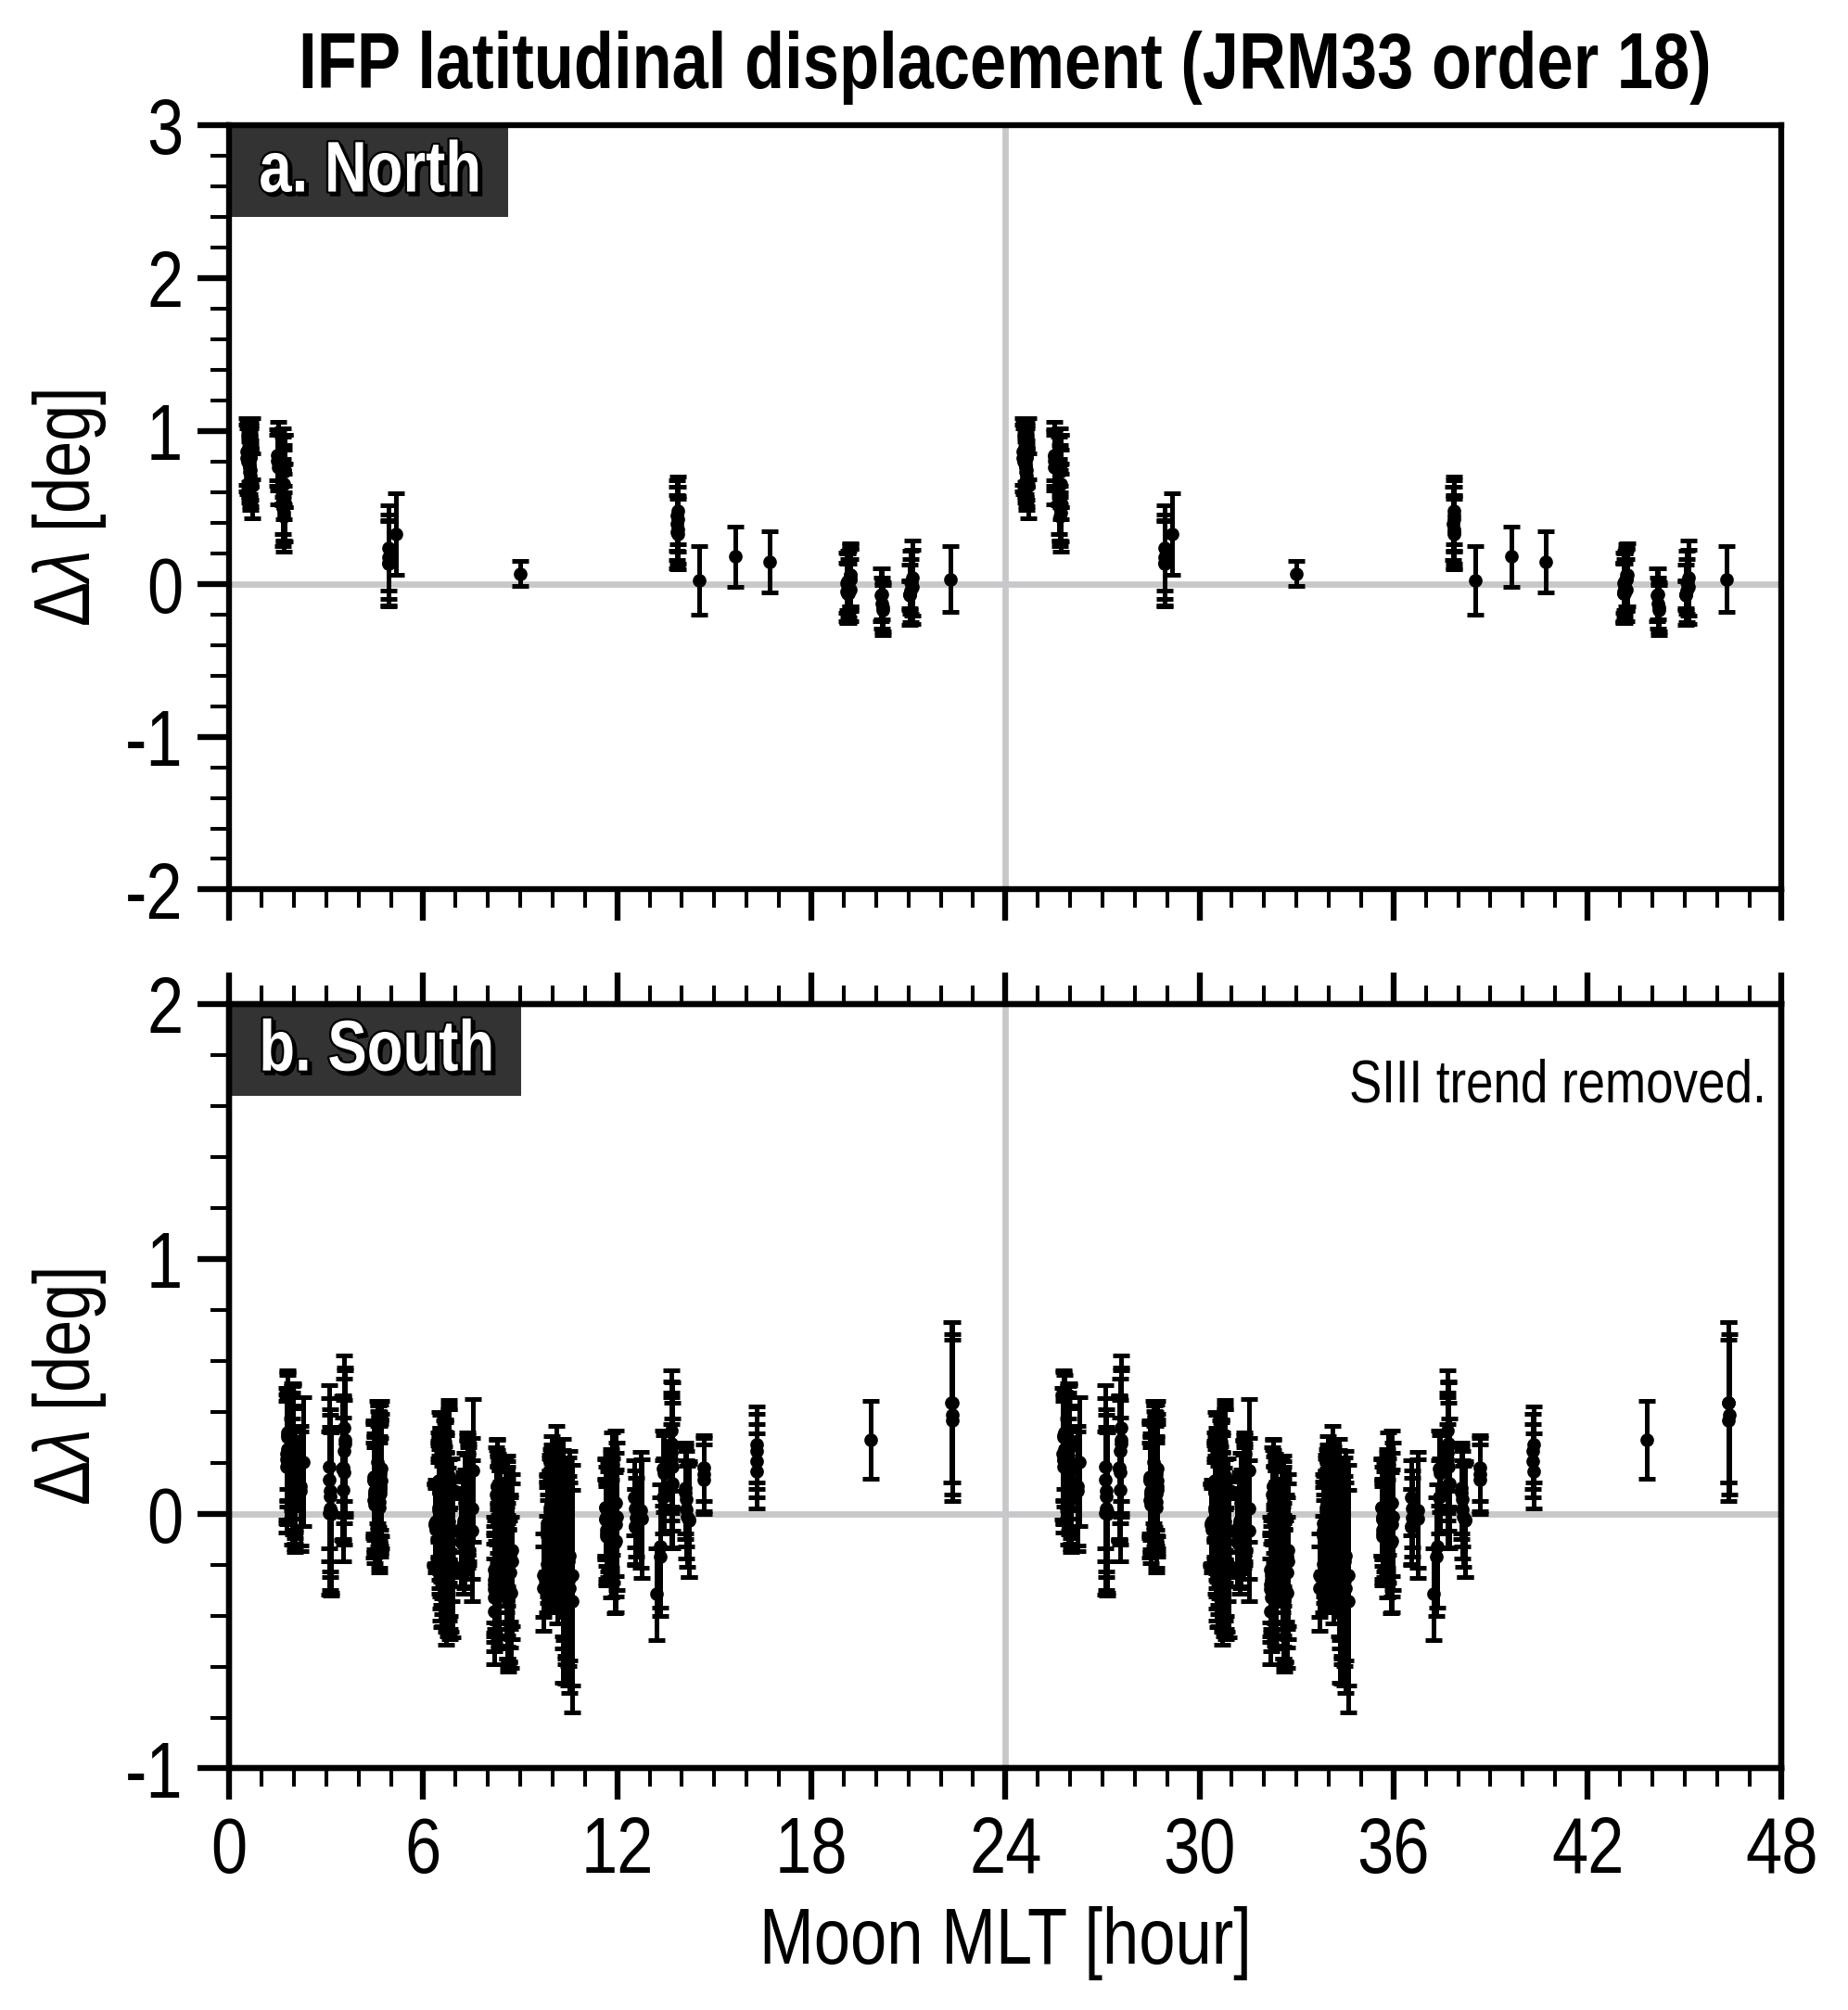

In [75]:
# SIII依存性を差し引いてMLT依存性を見る(南半球)
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(6.4, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)

    if hem_fp_select[j] < 0:
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])
    else:
        SIII_fit = fitfunc(moon_S3wlon_select[j]-eqlead_fp[j],
                           popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3], popt_s3[4],
                           popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8], popt_s3[9],
                           popt_s3[10])
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])-SIII_fit

    for i in range(2):
        sc = F.ax[ax_idx].scatter(lt+24.0*i,
                                  y,
                                  s=5.0, c='k')
        F.ax[ax_idx].errorbar(x=lt+24.0*i,
                              y=y,
                              yerr=err_lat_fp_select[j],
                              elinewidth=1.1, linewidth=0., markersize=0.,
                              capsize=2.0, capthick=1.1,
                              color='k')

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

F.ax[1].text(0.99, 0.93, r'SIII trend removed.',
             color='k',
             fontsize=F.fontsize*0.75,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    F.ax[i].axvline(x=24.0, color=UC.lightgray, zorder=0.9)

[ 0.15203691  0.24846103 -2.67084522]


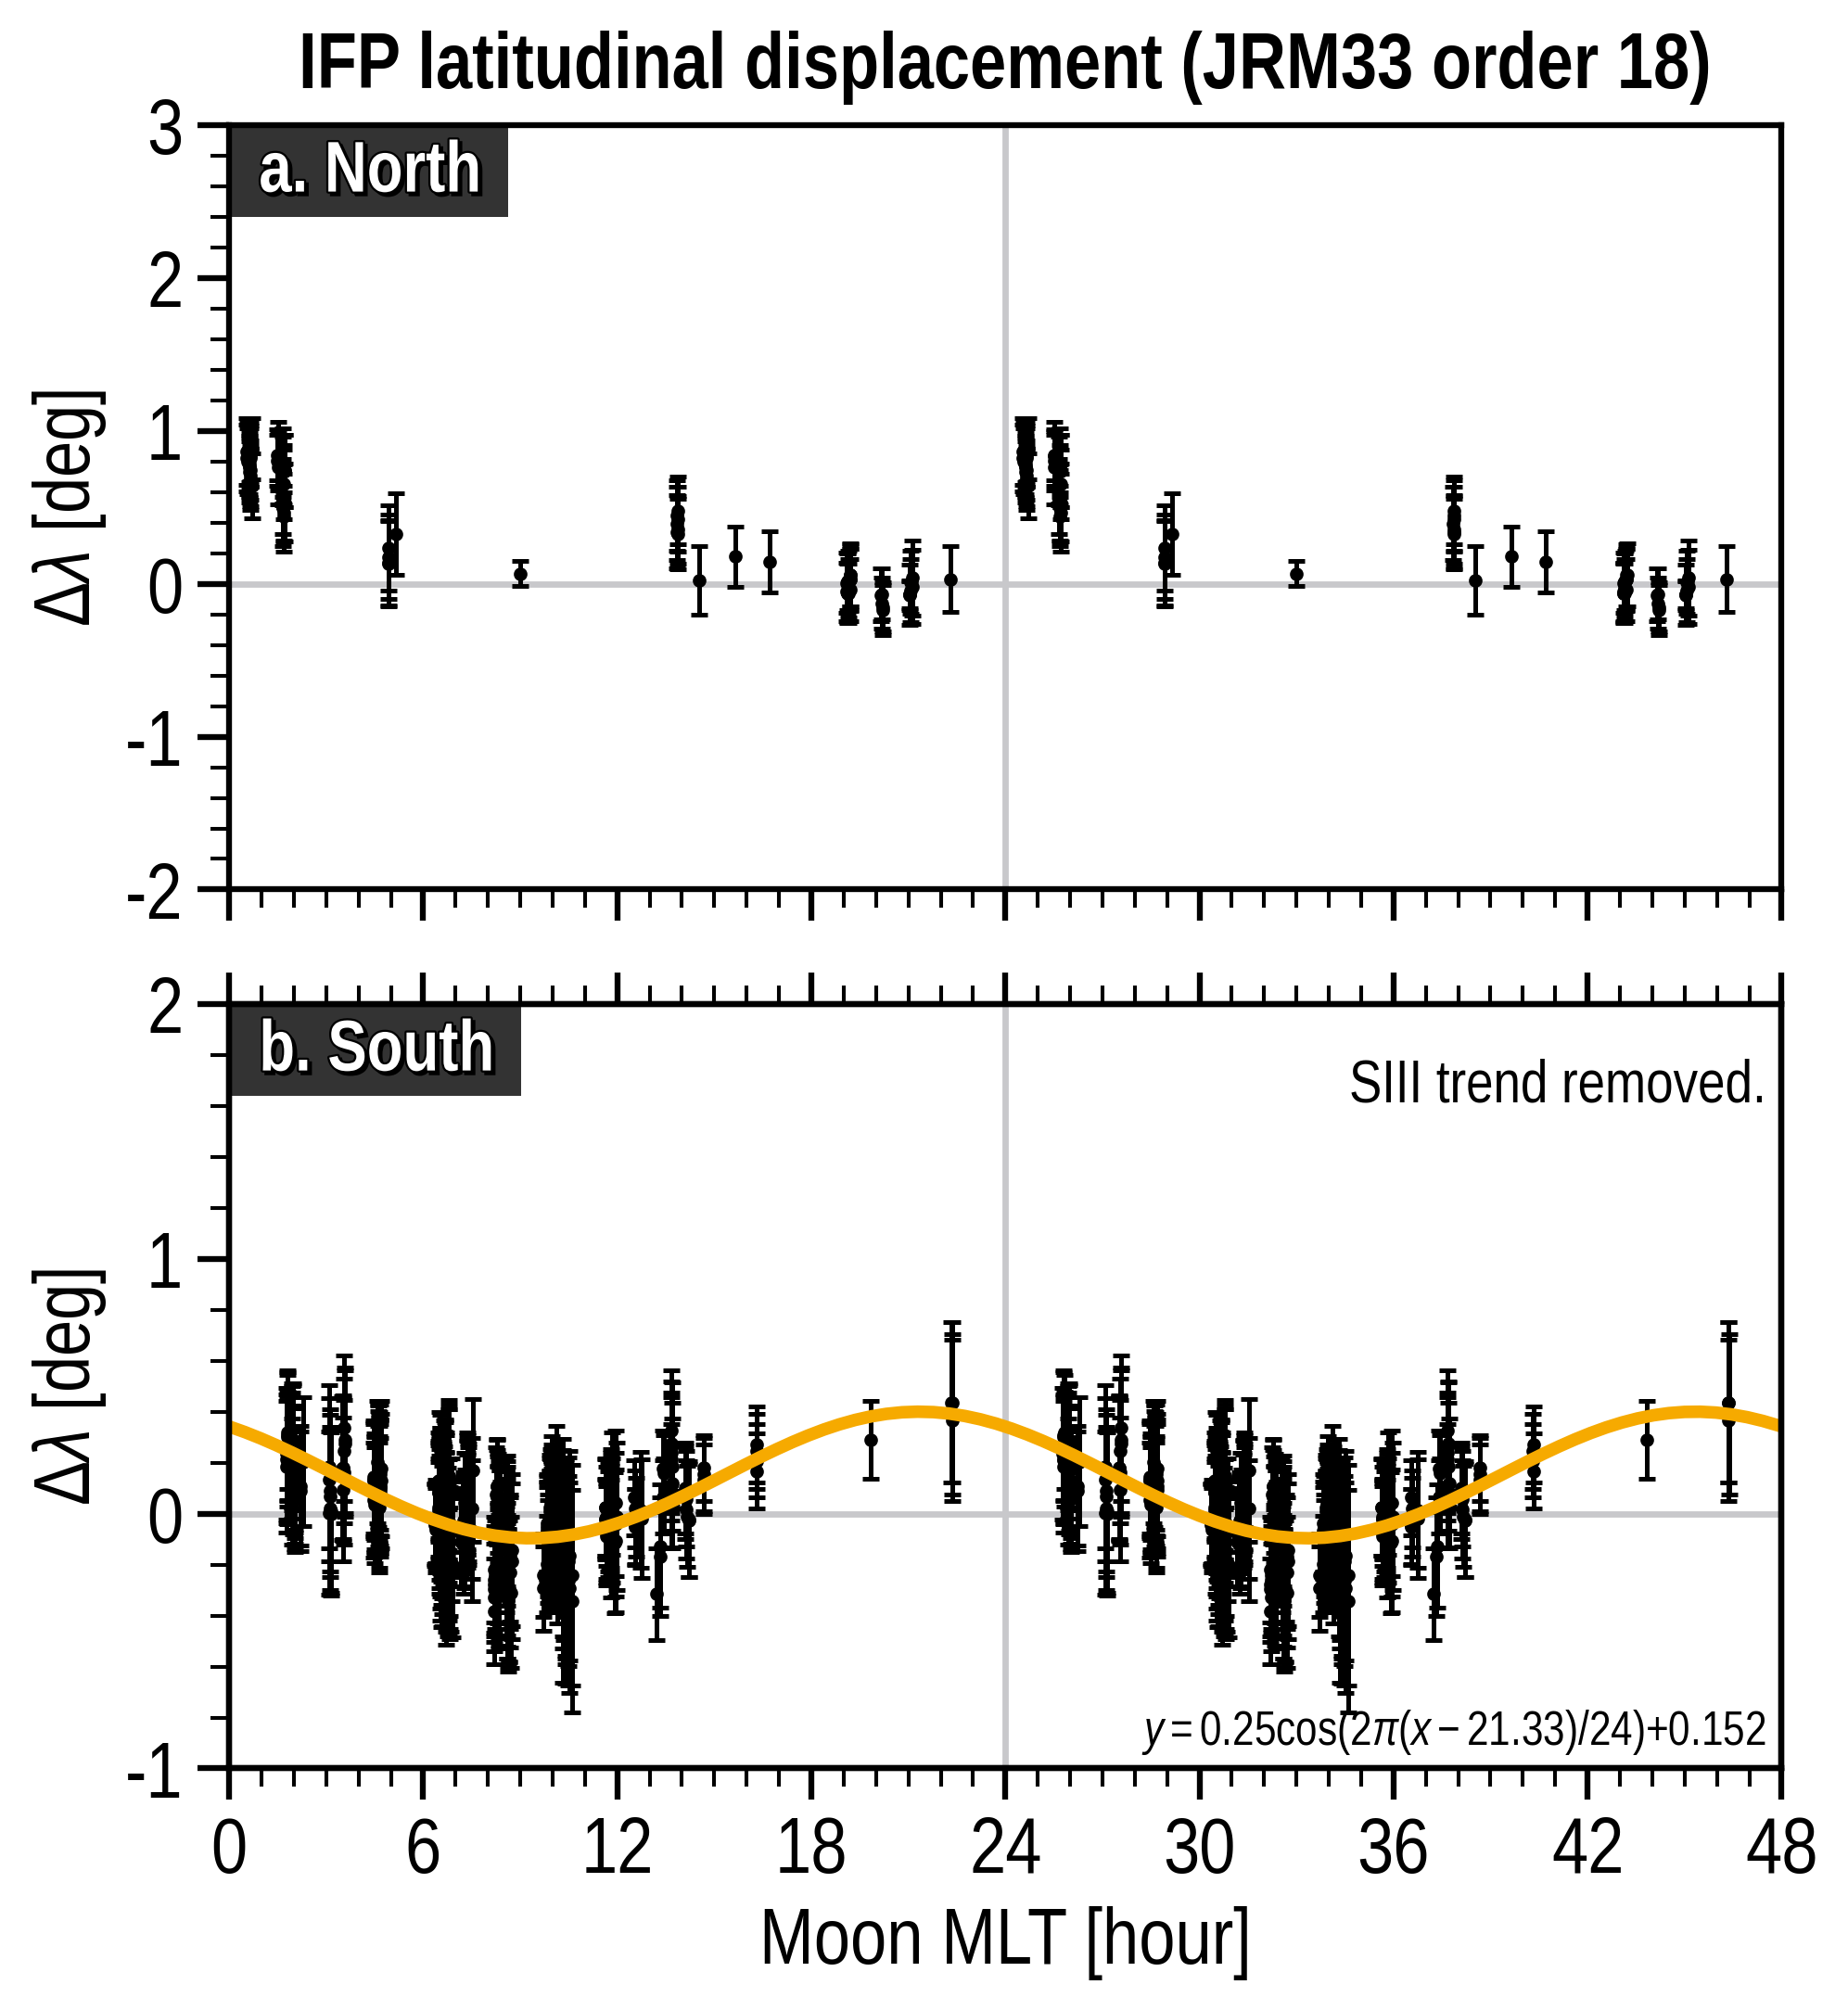

In [76]:
# SIII依存性を差し引いてMLT依存性をフィッティング(南)
def fitfunc_MLT(MLT, a, b, c):
    y = a + b*np.cos((2*np.pi/24.0)*(MLT-c))
    return y


F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(6.4, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta \lambda$ [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta \lambda$ [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

deltalat_N = []
deltalat_S = []
MLT_N = []
MLT_S = []
for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        data_list_j = deltalat_N
        MLT_list_j = MLT_N
    else:
        ax_idx = 1
        sgn = -1
        data_list_j = deltalat_S
        MLT_list_j = MLT_S

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)

    if hem_fp_select[j] < 0:
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])
    else:
        SIII_fit = fitfunc(moon_S3wlon_select[j]-eqlead_fp[j],
                           popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3], popt_s3[4],
                           popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8], popt_s3[9],
                           popt_s3[10])
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])-SIII_fit

    data_list_j += [y]
    MLT_list_j += [lt]

    for i in range(2):
        sc = F.ax[ax_idx].scatter(lt+24.0*i,
                                  y,
                                  s=5.0, c='k')
        F.ax[ax_idx].errorbar(x=lt+24.0*i,
                              y=y,
                              yerr=err_lat_fp_select[j],
                              elinewidth=1.1, linewidth=0., markersize=0.,
                              capsize=2.0, capthick=1.1,
                              color='k')

# Dawn fitting
sort = np.argsort(np.array(MLT_S))
popt_lt, pcov = curve_fit(fitfunc_MLT,
                          np.array(MLT_S)[sort],
                          np.array(deltalat_S)[sort])
print(popt_lt)
x_fit = np.linspace(0, 47.9, 100)
y_fit = fitfunc_MLT(x_fit, popt_lt[0], popt_lt[1], popt_lt[2])
F.ax[1].plot(x_fit, y_fit, linewidth=3.0, color=UC.orange)
y_fit_label = r'$y=$' + str(round(popt_lt[1], 2)) +\
    r'cos(2$\pi(x-$'+str(round(24.0+popt_lt[2], 2))+')/24)+' +\
    str(round(popt_lt[0], 3))

title = TARGET_MOON[0]+'FP ' + \
    r'latitudinal displacement (JRM33 order 18)'
F.ax[0].set_title(title, weight='bold')

F.ax[1].text(0.99, 0.93, r'SIII trend removed.',
             color='k',
             fontsize=F.fontsize*0.75,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)
F.ax[1].text(0.99, 0.08,
             y_fit_label,
             color='k',
             fontsize=F.fontsize*0.6,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    F.ax[i].axvline(x=24.0, color=UC.lightgray, zorder=0.9)

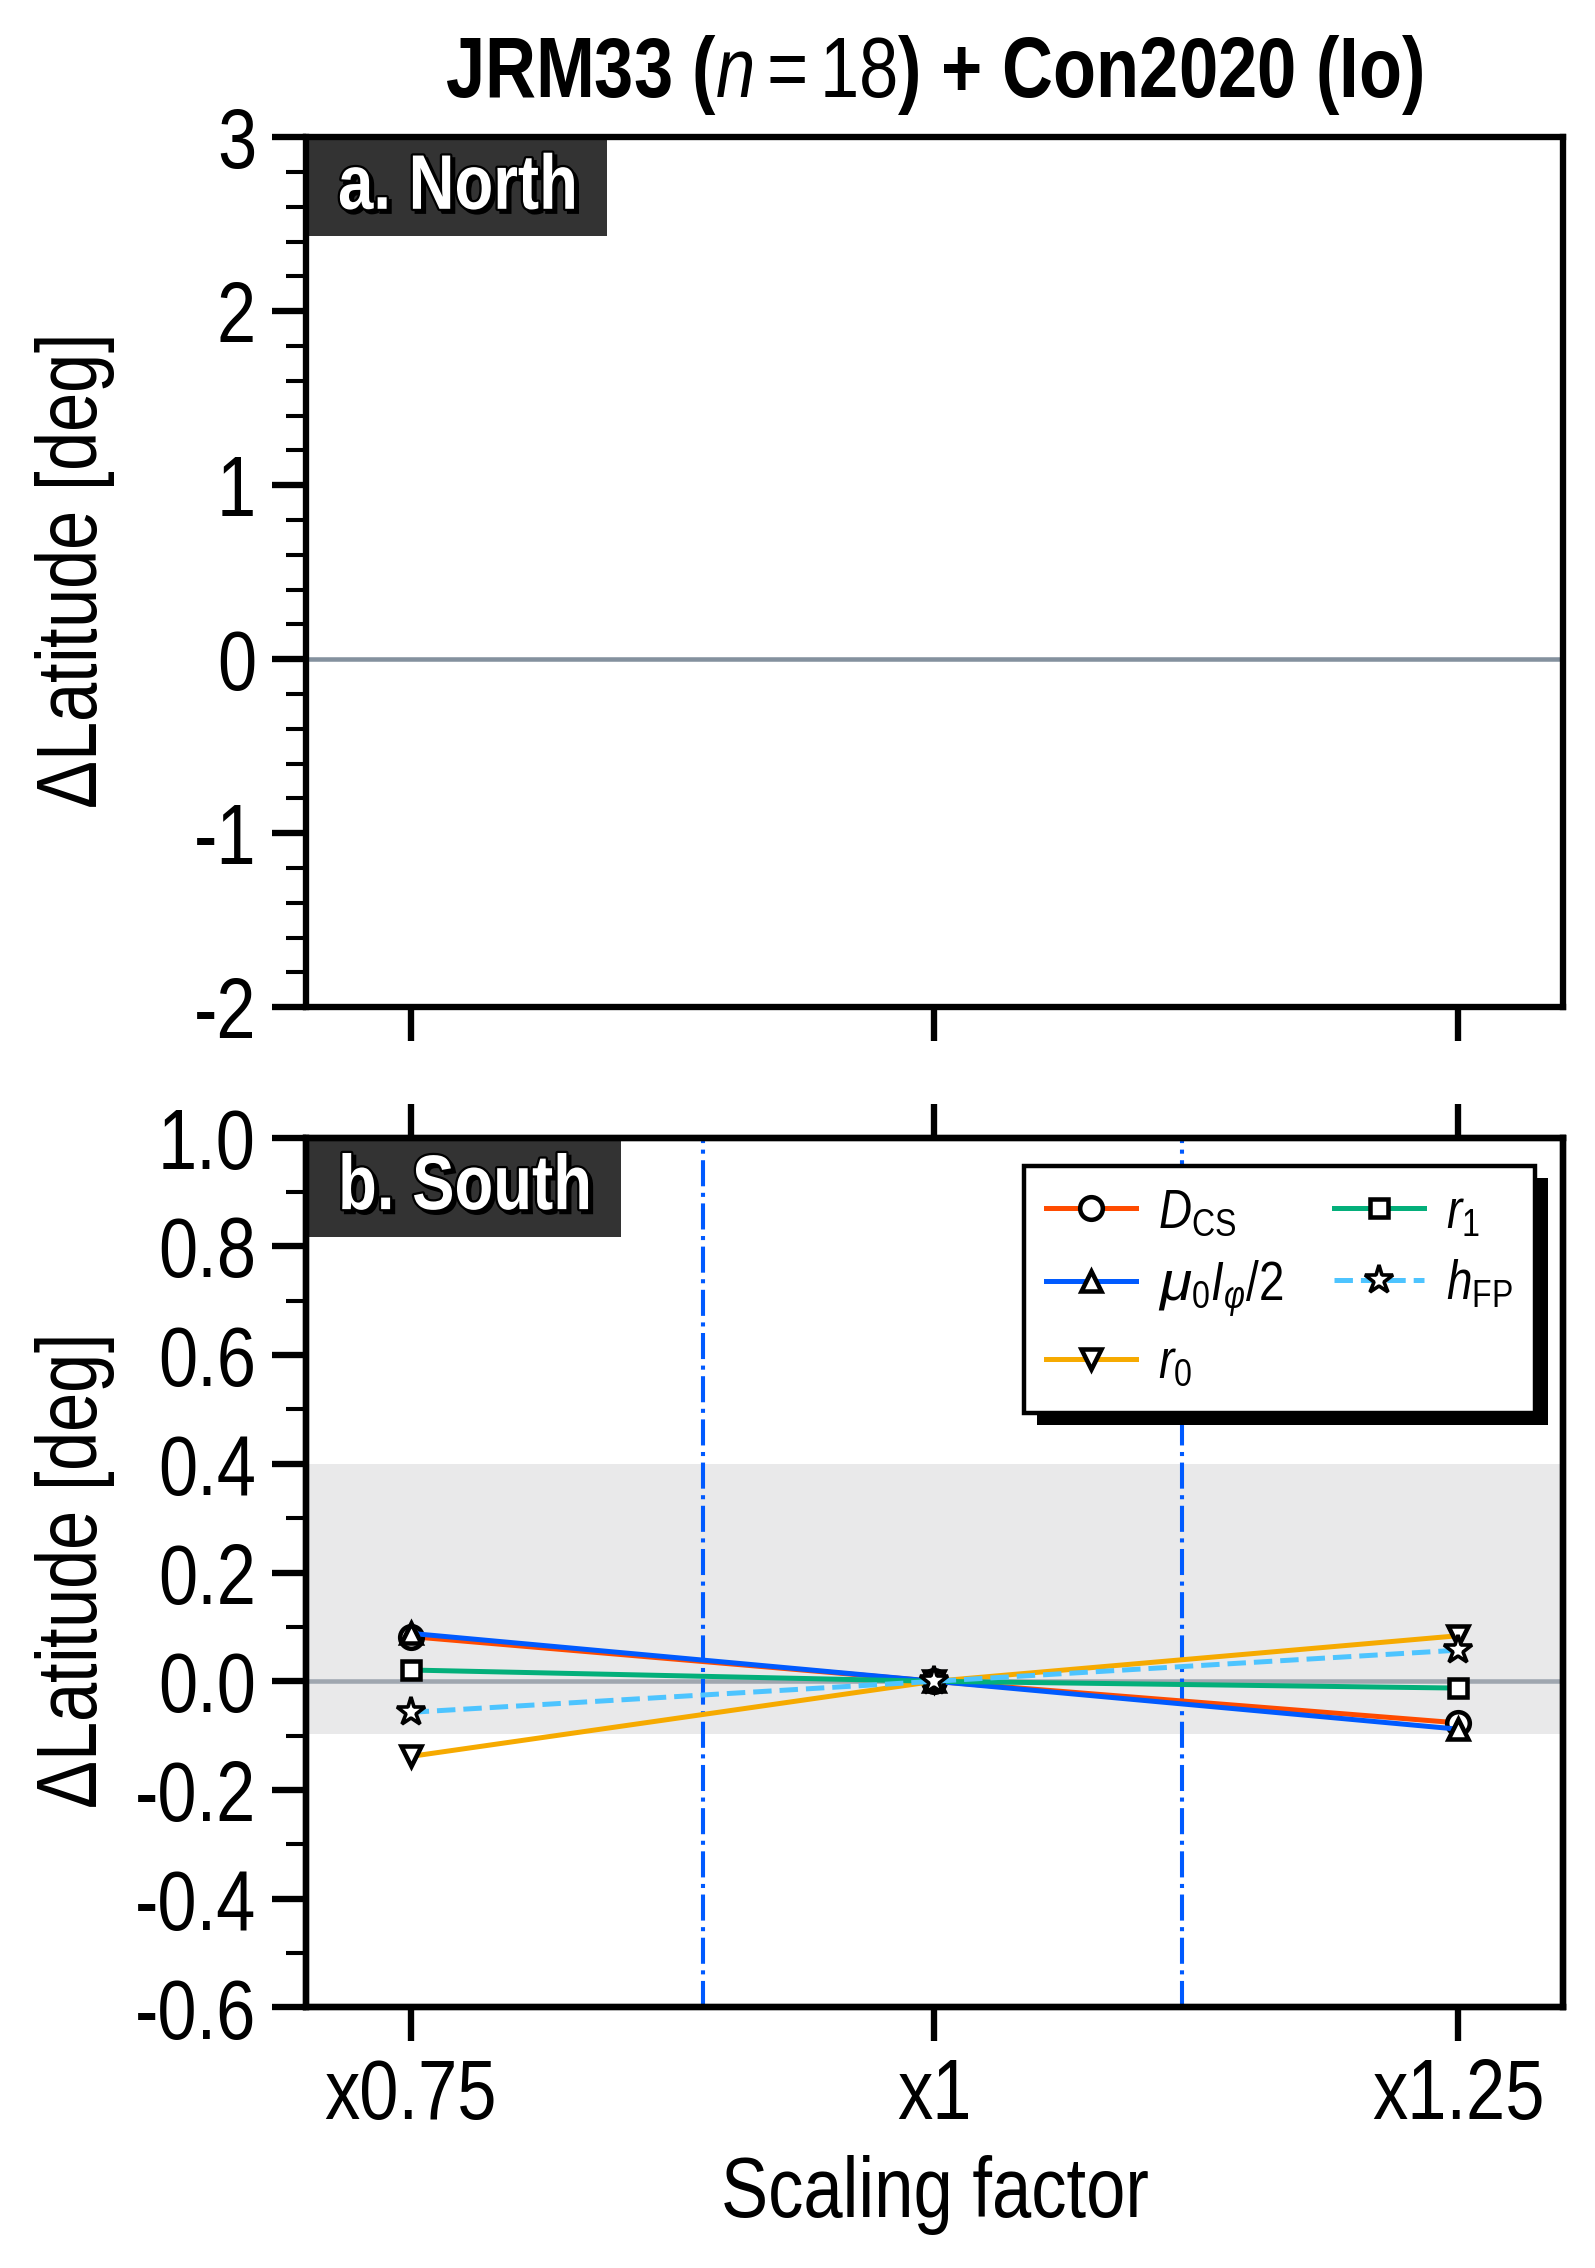

In [ ]:
# SIII依存性を差し引いてMLT依存性をフィッティング(南)
def fitfunc_MLT(MLT, a, b, c):
    y = a + b*np.cos((2*np.pi/24.0)*(MLT-c))
    return y


F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(5, 6.8), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.linspace(0.75, 1.25, 3)
xticklabels = ['x0.75', 'x1', 'x1.25']

F.set_xaxis(label=r'Scaling factor',
            min=0.7, max=1.3,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=1)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-0.6, max=1,
            ticks=np.linspace(-0.6, 1, 9),
            ticklabels=np.linspace(-6, 10, 9, dtype=int)/10,
            minor_num=2)

x_fit = np.linspace(0, 47.9, 100)
y_fit = fitfunc_MLT(x_fit, popt_lt[0], popt_lt[1], popt_lt[2])
F.ax[1].fill_between(x=[-1, 2], y1=np.min(y_fit), y2=np.max(y_fit),
                     fc=UC.lightgray, alpha=0.4,)

x_scale = np.linspace(0.75, 1.25, 3)
dif_d = np.array([np.average(lat_fp_trace_900s18_075d-lat_fp_traced_900s18),
                  0,
                  np.average(lat_fp_trace_900s18_125d-lat_fp_traced_900s18)])
dif_mui = np.array([np.average(lat_fp_trace_900s18_075mui-lat_fp_traced_900s18),
                    0,
                    np.average(lat_fp_trace_900s18_125mui-lat_fp_traced_900s18)])
dif_r0 = np.array([np.average(lat_fp_trace_900s18_075r0-lat_fp_traced_900s18),
                   0,
                   np.average(lat_fp_trace_900s18_125r0-lat_fp_traced_900s18)])
dif_r1 = np.array([np.average(lat_fp_trace_900s18_075r1-lat_fp_traced_900s18),
                   0,
                   np.average(lat_fp_trace_900s18_125r1-lat_fp_traced_900s18)])
dif_alt = np.array([np.average(lat_fp_traced_1125s18-lat_fp_traced_900s18),
                   0,
                   np.average(lat_fp_traced_675s18-lat_fp_traced_900s18)])
F.ax[1].plot(x_scale, -dif_d,
             color=UC.red, linewidth=1.1,
             marker='o', markersize=5.0,
             markeredgecolor='k', markerfacecolor='w',
             label=r'$D_{\rm CS}$')
F.ax[1].plot(x_scale, -dif_mui,
             color=UC.blue, linewidth=1.1,
             marker='^', markersize=4.5,
             markeredgecolor='k', markerfacecolor='w',
             label=r'$\mu_0 I_{\varphi} / 2$')
F.ax[1].plot(x_scale, -dif_r0,
             color=UC.orange, linewidth=1.1,
             marker='v', markersize=4.5,
             markeredgecolor='k', markerfacecolor='w',
             label=r'$r_0$')
F.ax[1].plot(x_scale, -dif_r1,
             color=UC.green, linewidth=1.1,
             marker='s', markersize=4.0,
             markeredgecolor='k', markerfacecolor='w',
             label=r'$r_1$')
F.ax[1].plot(x_scale, -dif_alt,
             color=UC.lightblue, linewidth=1.1,
             linestyle='--',
             marker='*', markersize=6.5,
             markeredgecolor='k', markerfacecolor='w',
             markeredgewidth=0.8,
             label=r'$h_{\rm FP}}$')

# Connerney+2020 mu_i range
F.ax[1].axvline(x=np.max(con20_mu_i_tot)/139.6, linestyle='-.',
                linewidth=0.9, color=UC.blue, zorder=1.0,)
F.ax[1].axvline(x=np.min(con20_mu_i_tot)/139.6, linestyle='-.',
                linewidth=0.9, color=UC.blue, zorder=1.0,)

F.ax[0].set_title(r'JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

legend = F.legend(ax_idx=1,
                  ncol=2, markerscale=1.0,
                  loc='upper right',
                  handlelength=1.6,
                  textcolor=False,
                  fontsize_scale=0.65,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[1], d=0.7)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.gray, linewidth=1.0, zorder=0.9)

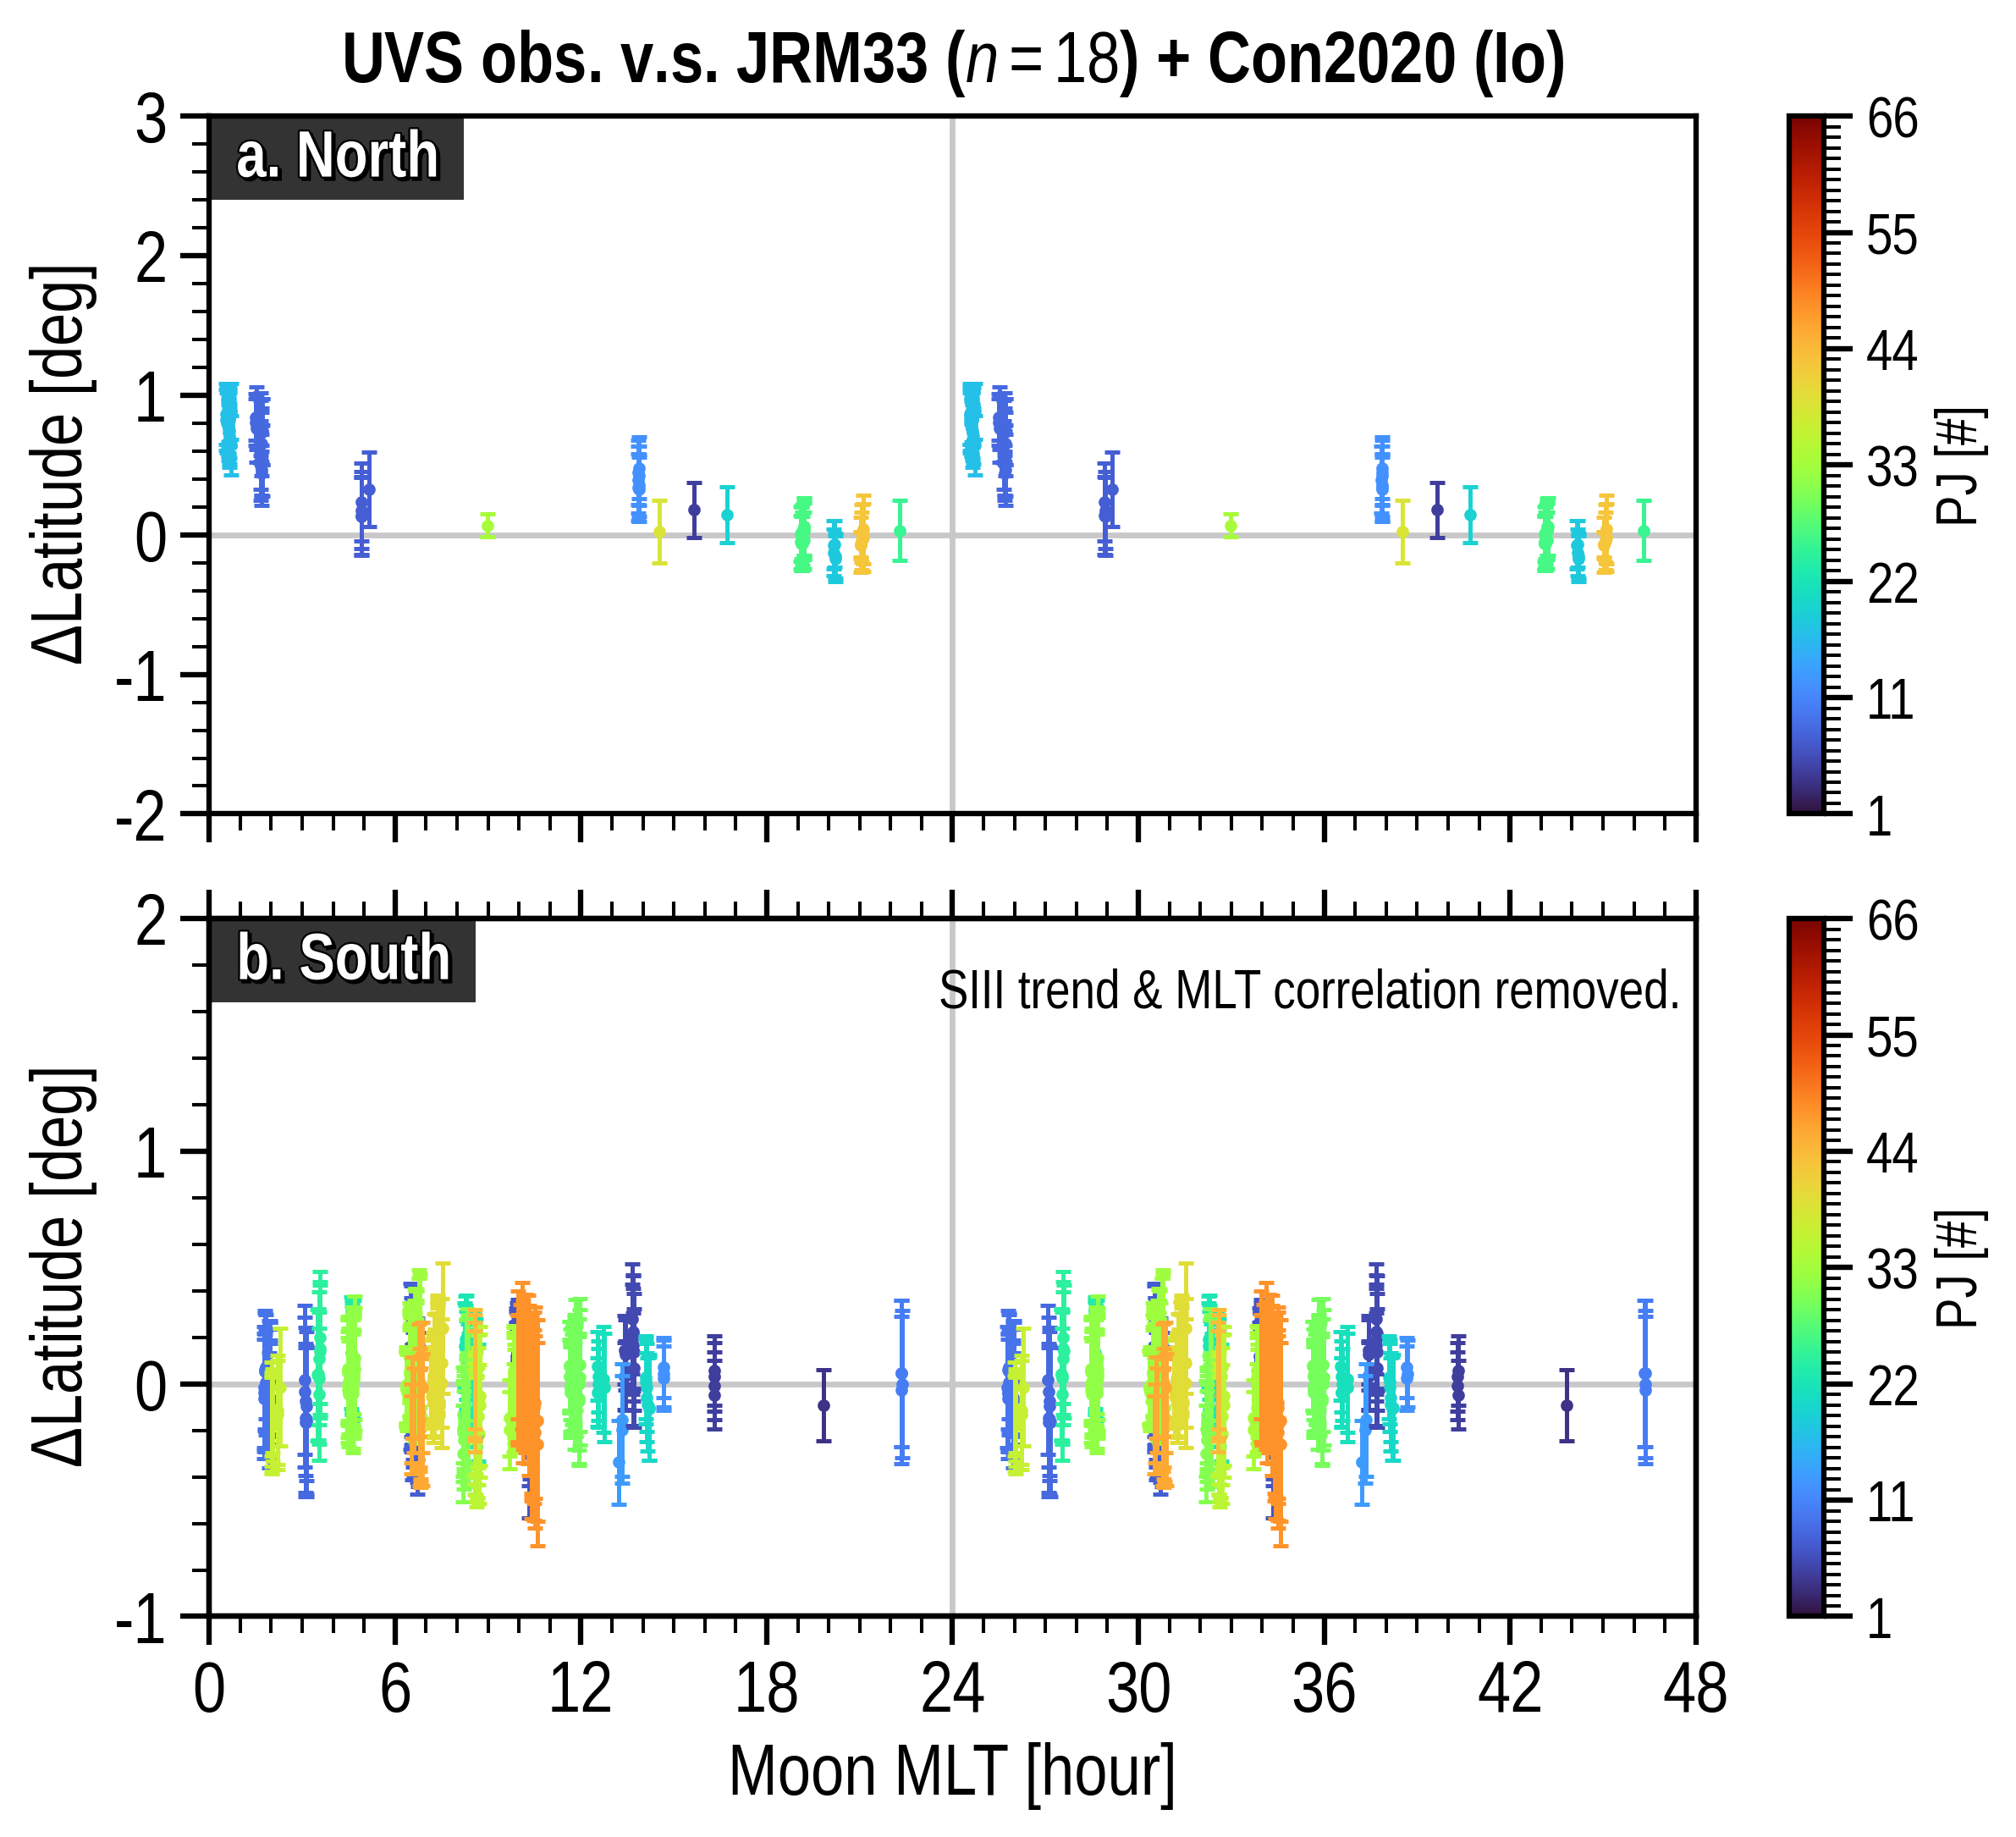

In [ ]:
# SIII依存性を差し引いてMLT依存性をフィッティングして, さらに差し引く(南)
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
    else:
        ax_idx = 1
        sgn = -1

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)
    lt_fit = fitfunc_MLT(lt, popt_lt[0], popt_lt[1], popt_lt[2])

    if hem_fp_select[j] < 0:
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])
    else:
        SIII_fit = fitfunc(moon_S3wlon_select[j]-eqlead_fp[j],
                           popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3], popt_s3[4],
                           popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8], popt_s3[9],
                           popt_s3[10])
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])-SIII_fit-lt_fit

    for i in range(2):
        sc = F.ax[ax_idx].scatter(lt+24.0*i,
                                  y,
                                  s=5.0, c=pj_fp[j], cmap=cmap, vmin=vmin, vmax=vmax)
        F.ax[ax_idx].errorbar(x=lt+24.0*i,
                              y=y,
                              yerr=err_lat_fp_select[j],
                              elinewidth=1.1, linewidth=0., markersize=0.,
                              capsize=2.0, capthick=1.1,
                              color=cmap(norm(pj_fp[j])))

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

F.ax[1].text(0.99, 0.93, r'SIII trend & MLT correlation removed.',
             color='k',
             fontsize=F.fontsize*0.75,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    F.ax[i].axvline(x=24.0, color=UC.lightgray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(1, 66, 7))
    cax.ax.set_yticklabels(np.linspace(
        1, 66, 7, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(11))
    cax.ax.set_ylabel(r'PJ [#]', fontsize=F.fontsize*0.8)

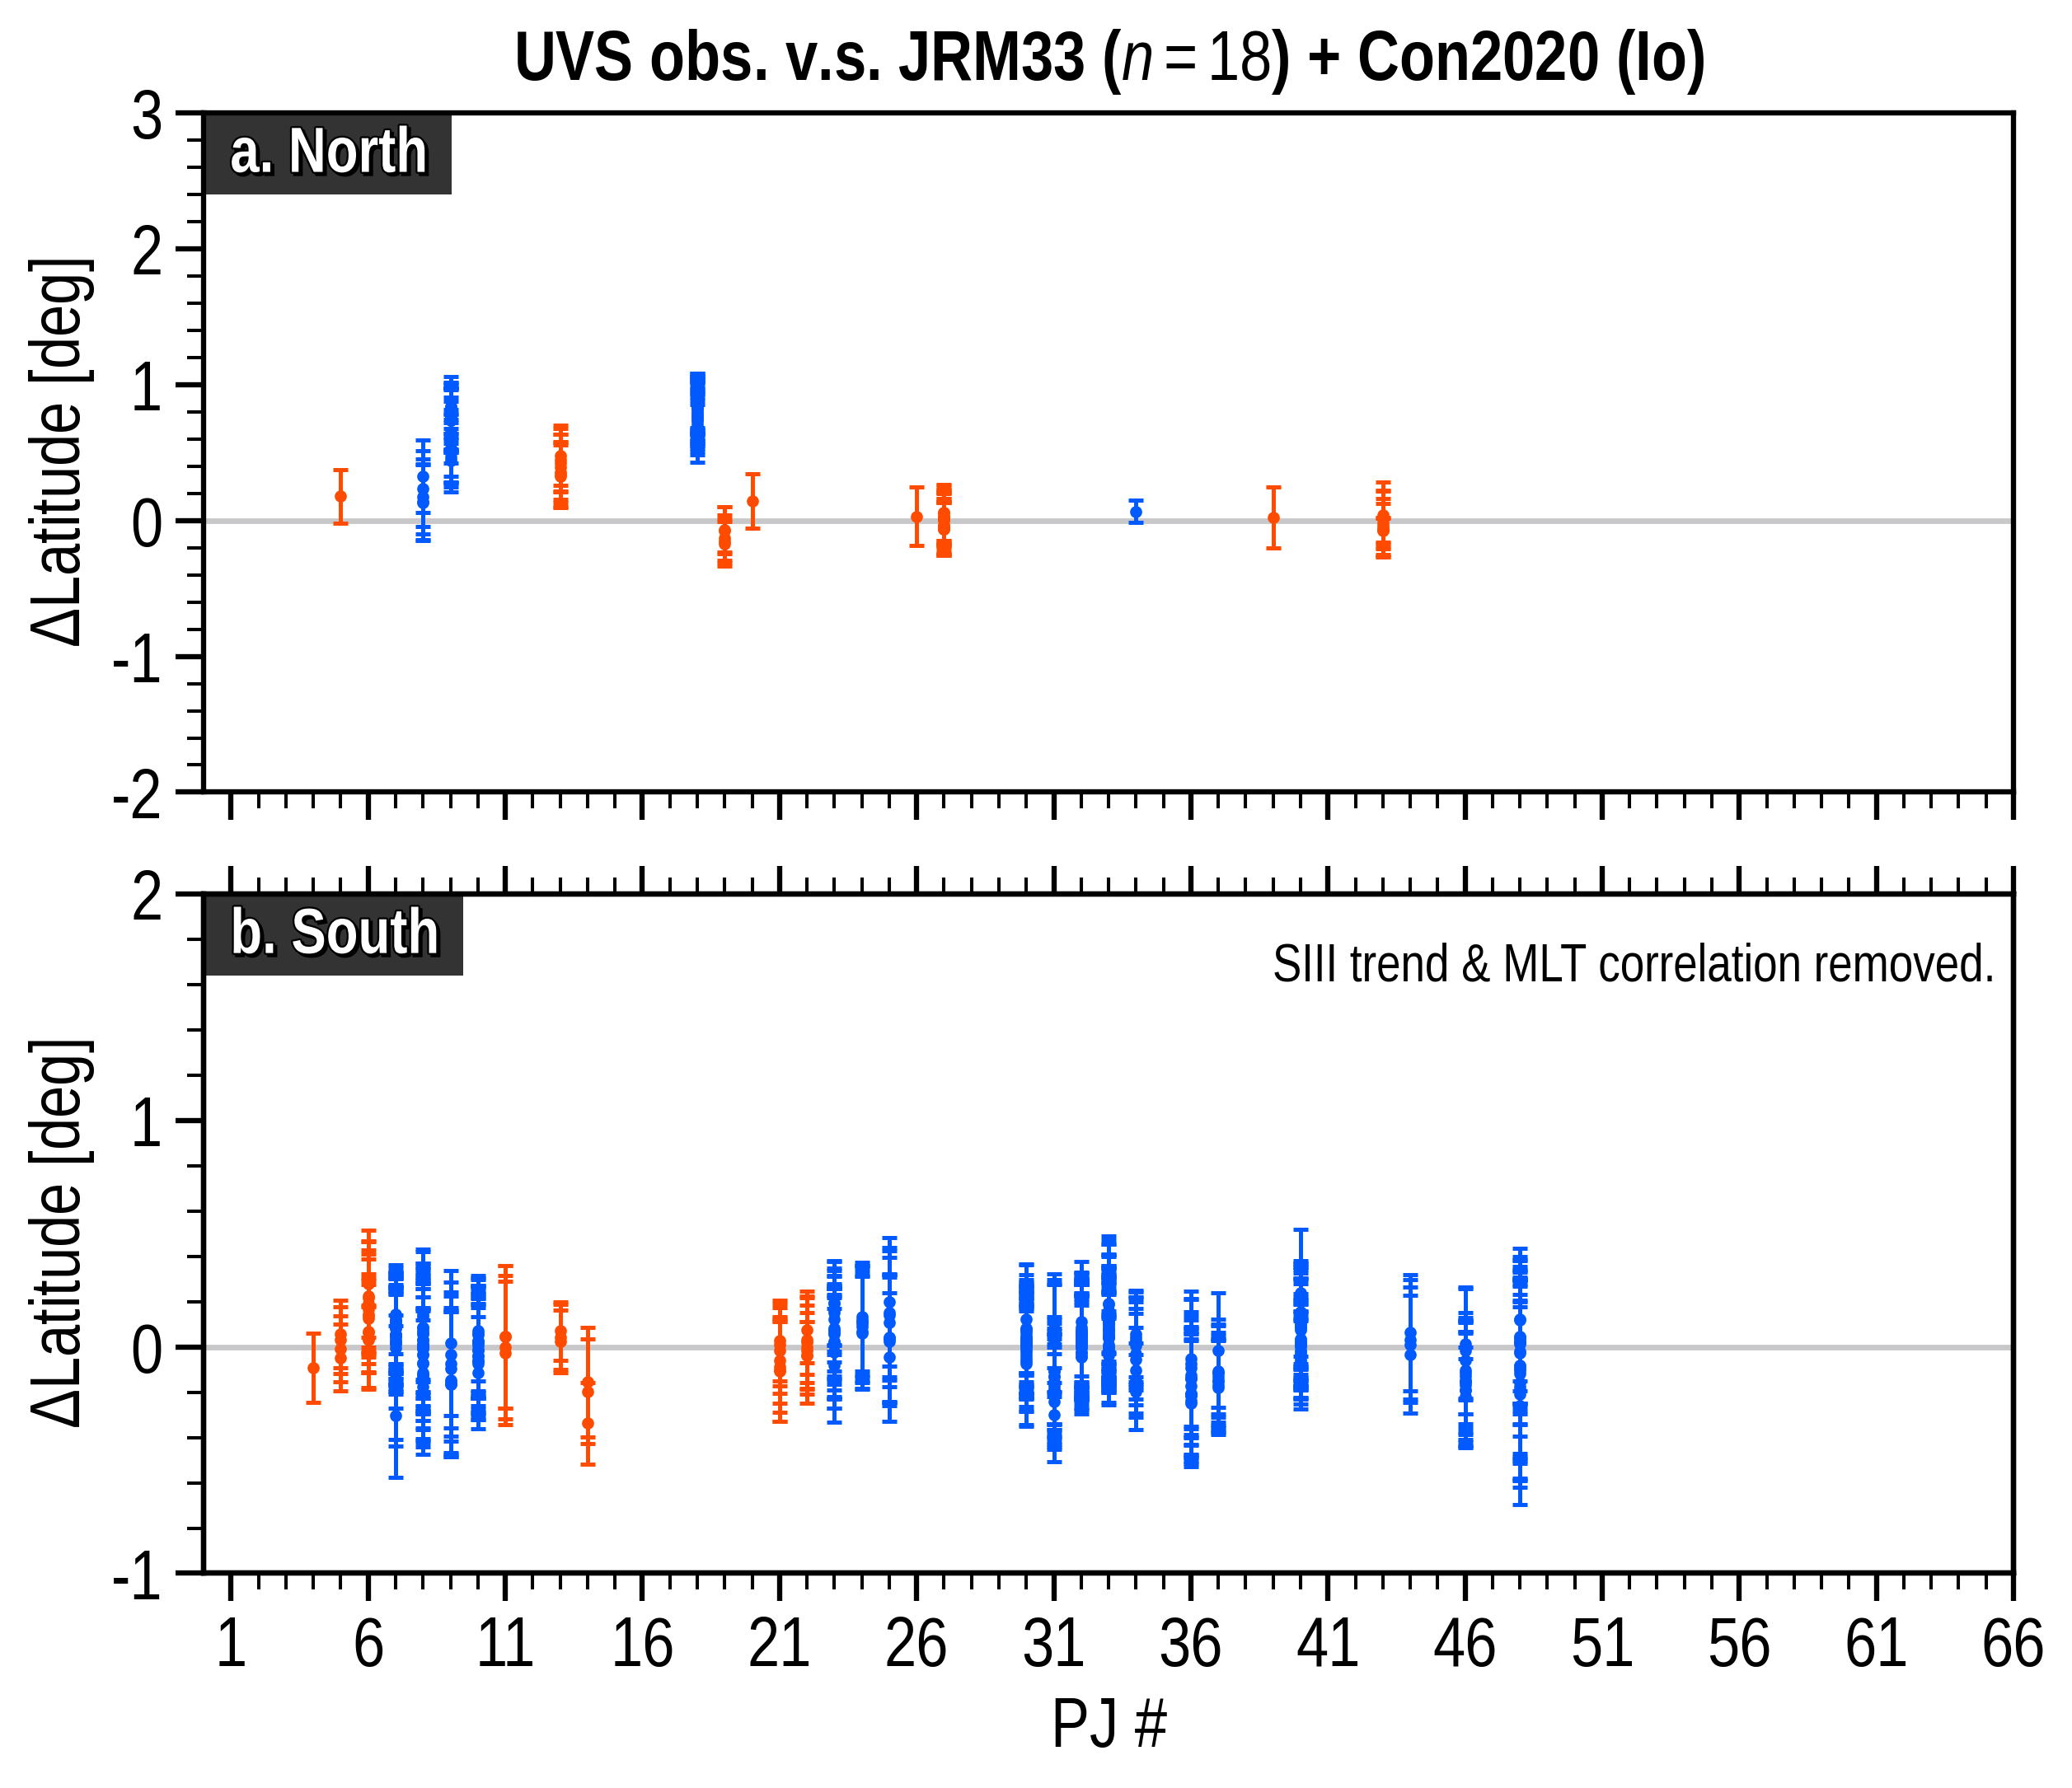

In [ ]:
# SIII依存性を差し引いてMLT依存性をフィッティングして, さらに差し引く(南)
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(1, 66+1, 5)
xticklabels = np.arange(1, 66+1, 5, dtype=int)

F.set_xaxis(label=r'PJ #',
            min=0, max=66,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=5)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
    else:
        ax_idx = 1
        sgn = -1

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)
    lt_fit = fitfunc_MLT(lt, popt_lt[0], popt_lt[1], popt_lt[2])

    if hem_fp_select[j] < 0:
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])
    else:
        SIII_fit = fitfunc(moon_S3wlon_select[j]-eqlead_fp[j],
                           popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3], popt_s3[4],
                           popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8], popt_s3[9],
                           popt_s3[10])
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])-SIII_fit-lt_fit

    if lt < 12.0:
        color = UC.blue
    else:
        color = UC.red

    sc = F.ax[ax_idx].scatter(pj_fp[j],
                              y,
                              s=5.0, c=color)
    F.ax[ax_idx].errorbar(pj_fp[j],
                          y=y,
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color=color)

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

F.ax[1].text(0.99, 0.93, r'SIII trend & MLT correlation removed.',
             color='k',
             fontsize=F.fontsize*0.75,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)

/opt/homebrew/Caskroom/miniforge/base/envs/py3104/lib/python3.10/site-packages/numpy/lib/function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/homebrew/Caskroom/miniforge/base/envs/py3104/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/homebrew/Caskroom/miniforge/base/envs/py3104/lib/python3.10/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/opt/homebrew/Caskroom/miniforge/base/envs/py3104/lib/python3.10/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


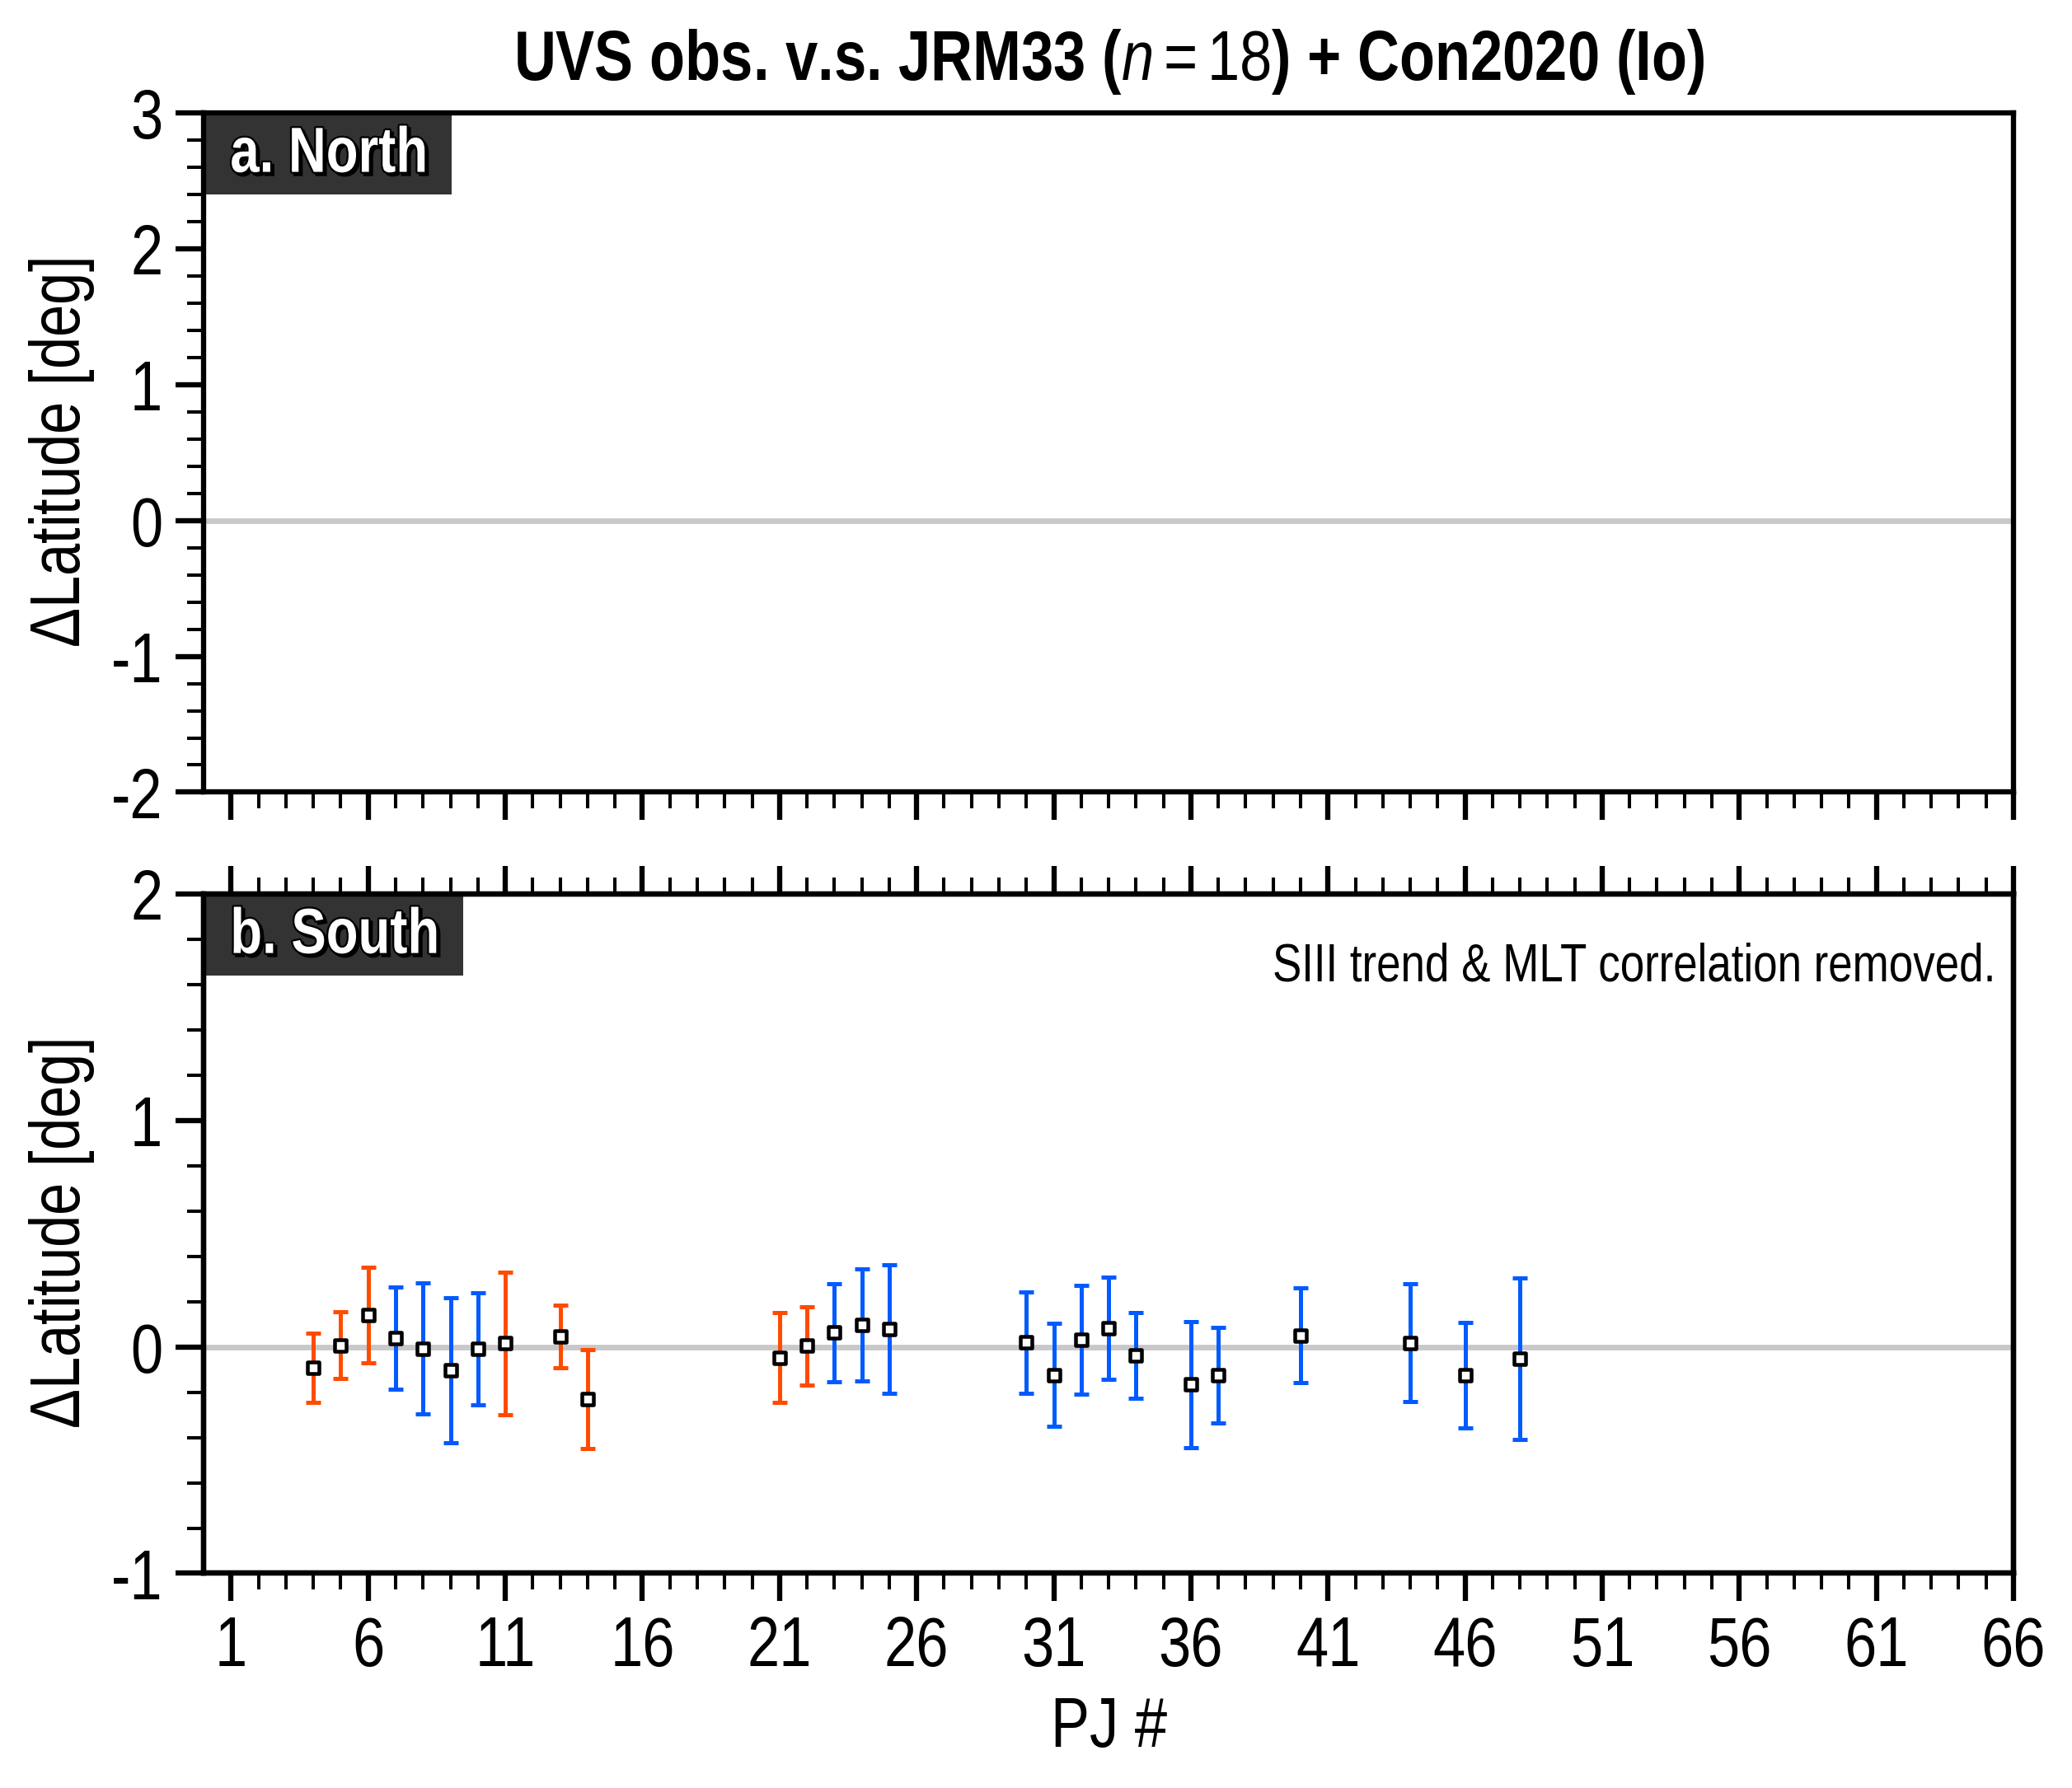

In [ ]:
# SIII依存性を差し引いてMLT依存性をフィッティングして, さらに差し引く(南)
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(1, 66+1, 5)
xticklabels = np.arange(1, 66+1, 5, dtype=int)

F.set_xaxis(label=r'PJ #',
            min=0, max=66,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=5)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

y_arr = np.zeros(moon_S3wlon_select.size)
lt_arr = np.zeros(moon_S3wlon_select.size)
for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
    else:
        ax_idx = 1
        sgn = -1

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)
    lt_fit = fitfunc_MLT(lt, popt_lt[0], popt_lt[1], popt_lt[2])

    if hem_fp_select[j] < 0:
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])
    else:
        SIII_fit = fitfunc(moon_S3wlon_select[j]-eqlead_fp[j],
                           popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3], popt_s3[4],
                           popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8], popt_s3[9],
                           popt_s3[10])
        y = sgn*(lat_fp_select[j]-lat_defaultfp_18[j])-SIII_fit-lt_fit

    y_arr[j] = y
    lt_arr[j] = lt

for i in range(len(PJ_LIST)):
    south = np.where(hem_fp_select > 0)
    y_ave = np.average(y_arr[south][np.where(pj_fp[south] == PJ_LIST[i])])
    lt_ave = np.average(lt_arr[south][np.where(pj_fp[south] == PJ_LIST[i])])

    if lt_ave < 12.0:
        color = UC.blue
    else:
        color = UC.red

    F.ax[1].scatter(PJ_LIST[i], y_ave,
                    s=10.0, marker='s', ec='k', fc='w', zorder=2.1)

    F.ax[1].errorbar(PJ_LIST[i],
                     y=y_ave,
                     yerr=np.average(
                         err_lat_fp_select[south][np.where(pj_fp[south] == PJ_LIST[i])]),
                     elinewidth=1.1, linewidth=0., markersize=0.,
                     capsize=2.0, capthick=1.1,
                     color=color, zorder=2.0)


F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

F.ax[1].text(0.99, 0.93, r'SIII trend & MLT correlation removed.',
             color='k',
             fontsize=F.fontsize*0.75,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)

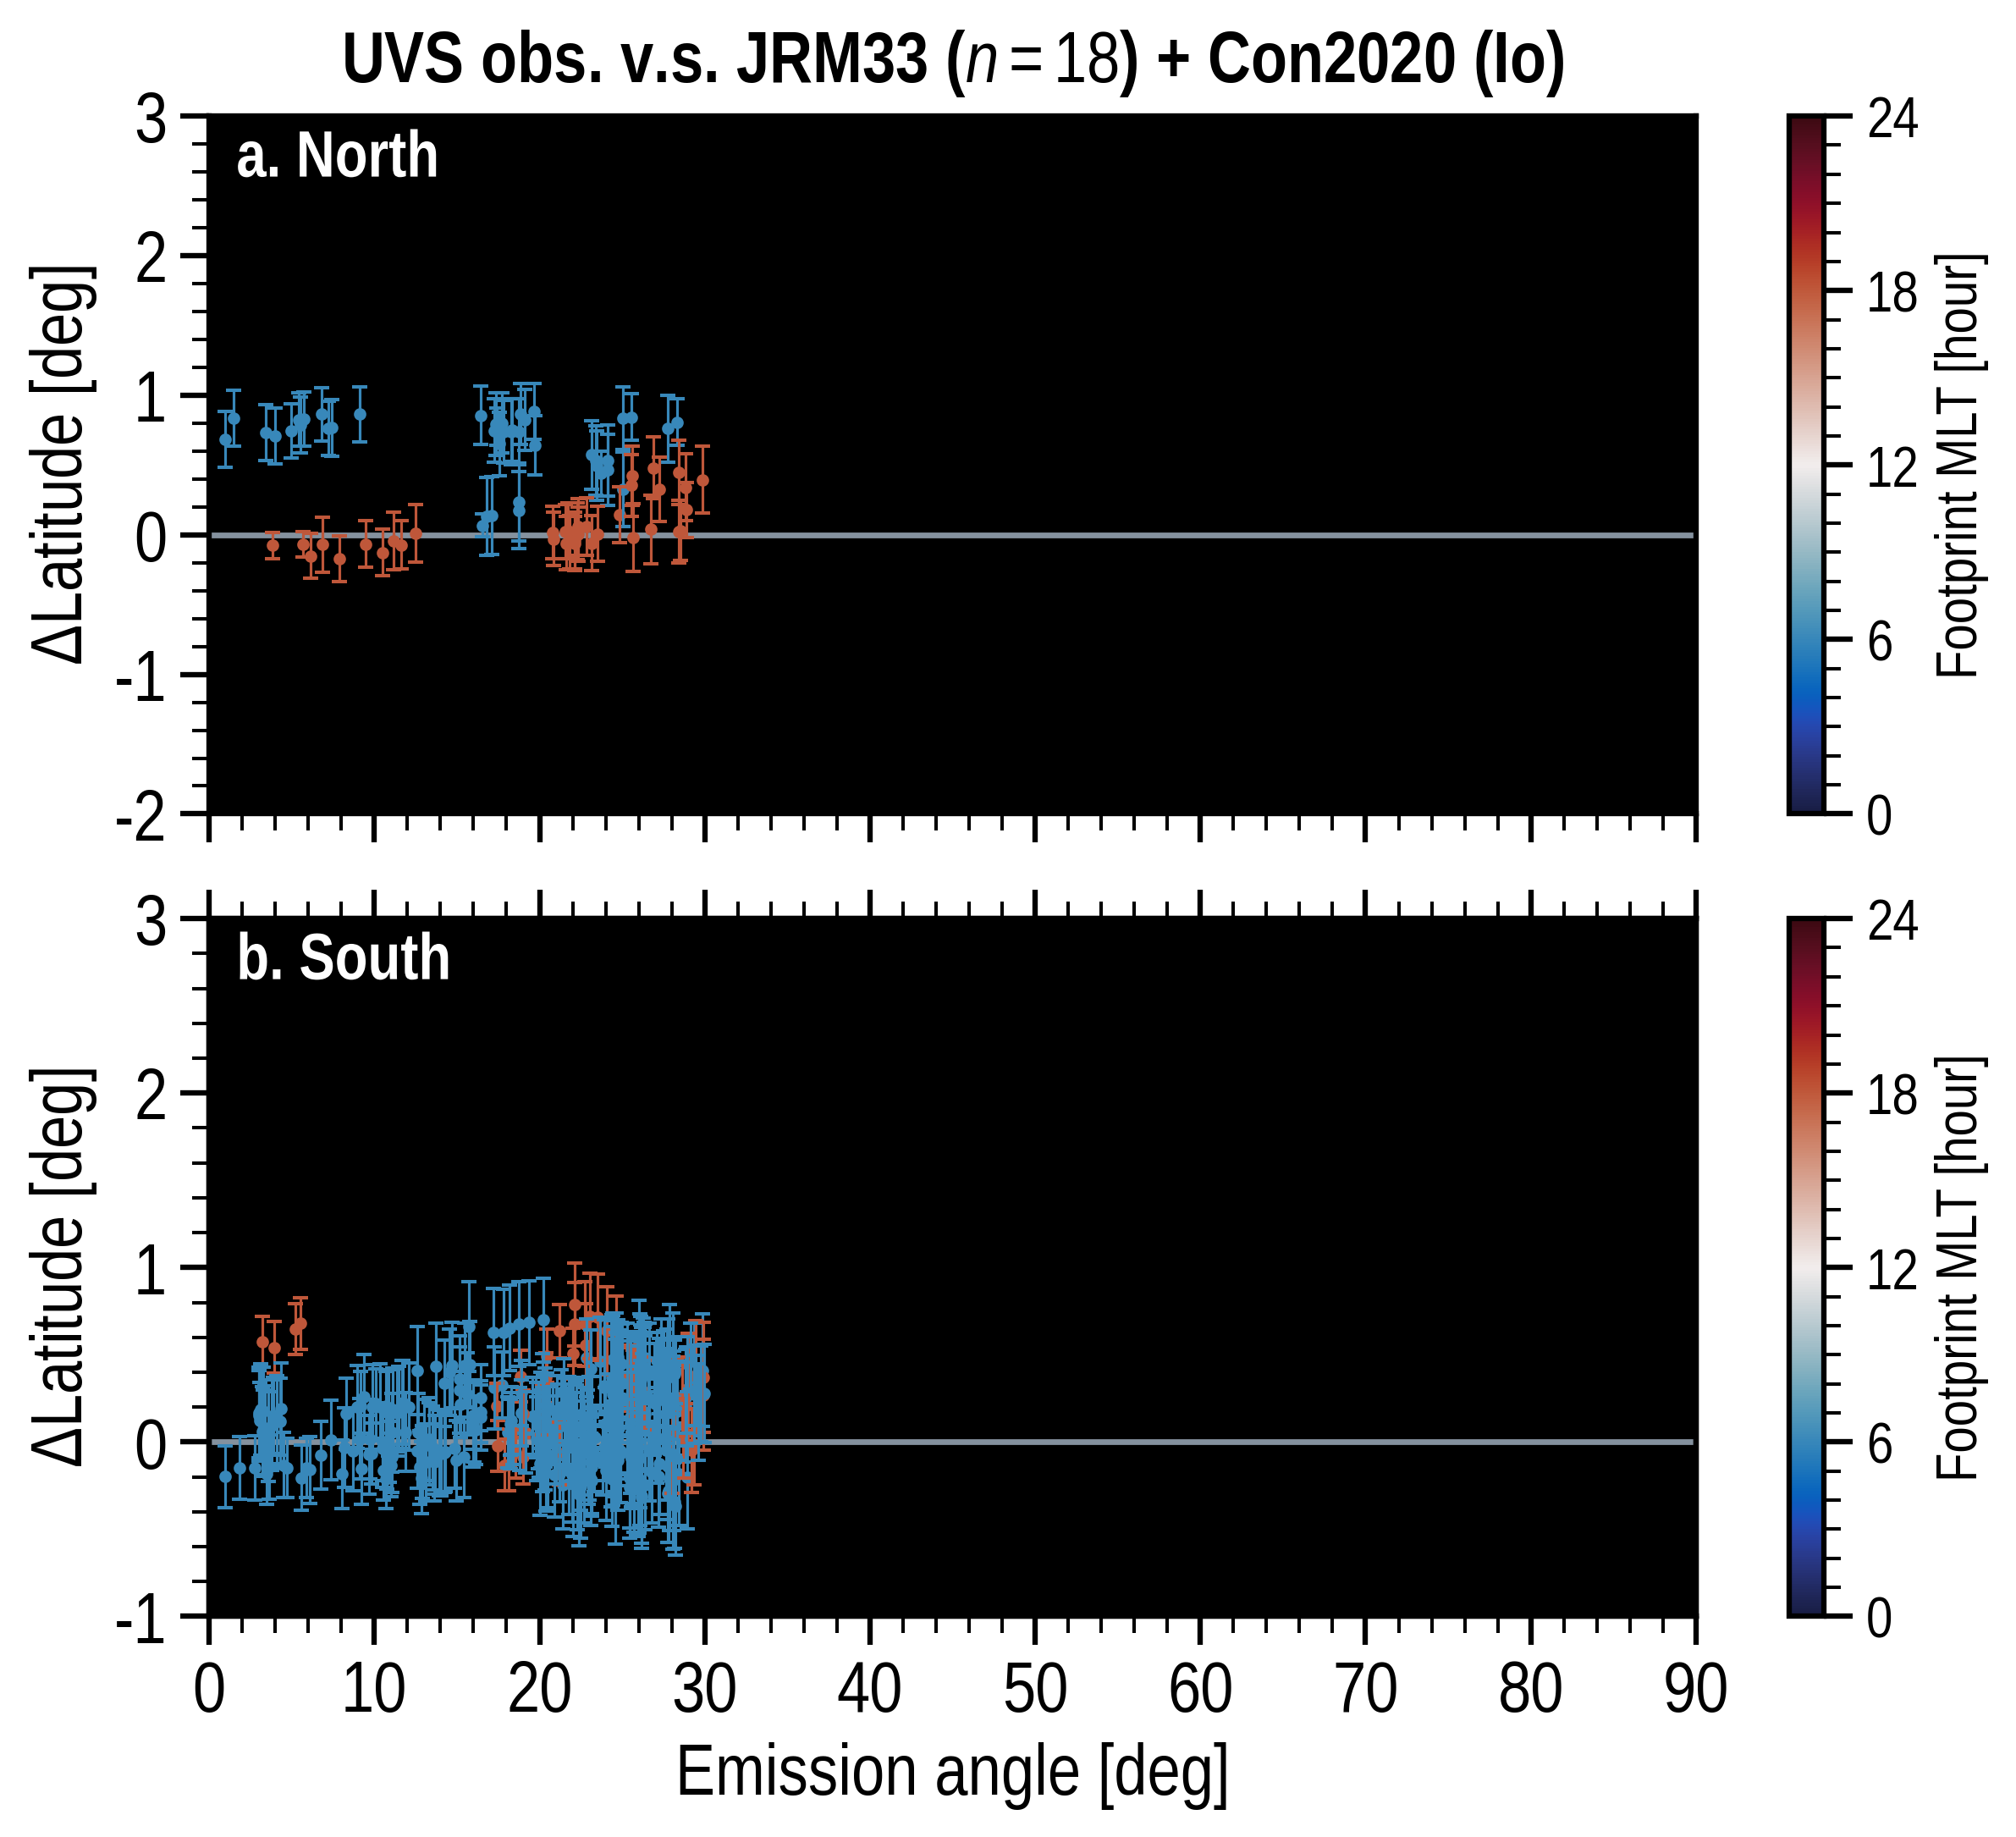

In [ ]:
# 横軸をemission angleに
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.linspace(0, 90, 10)
xticklabels = np.linspace(0, 90, 10, dtype=int)

F.set_xaxis(label=r'Emission angle [deg]',
            min=0.0, max=65.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=5)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 3, 5),
            ticklabels=np.linspace(-1, 3, 5, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 0.0
vmax = 24.0
cmap = cmocean.cm.balance
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1
    lt = local_time_moon(et_fp_select[j], TARGET_MOON)
    if lt < 12.0:
        lt = 6.0
    else:
        lt = 18.0

    sc = F.ax[ax_idx].scatter(view_angle_select[j],
                              sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                              s=5.0, c=lt, cmap=cmap, vmin=vmin, vmax=vmax)
    F.ax[ax_idx].errorbar(x=view_angle_select[j],
                          y=sgn*(lat_fp_select[j]-lat_defaultfp_18[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=0.7, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=0.9,
                          color=cmap(norm(lt)))

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

for i in range(2):
    F.ax[i].set_facecolor('k')
    F.ax[i].axhline(y=0, color=UC.gray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(0, 24, 5))
    cax.ax.set_yticklabels(np.linspace(
        0, 24, 5, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(6))
    cax.ax.set_ylabel(r'Footprint MLT [hour]', fontsize=F.fontsize*0.8)

# 内側境界 ($r_0$) を変える

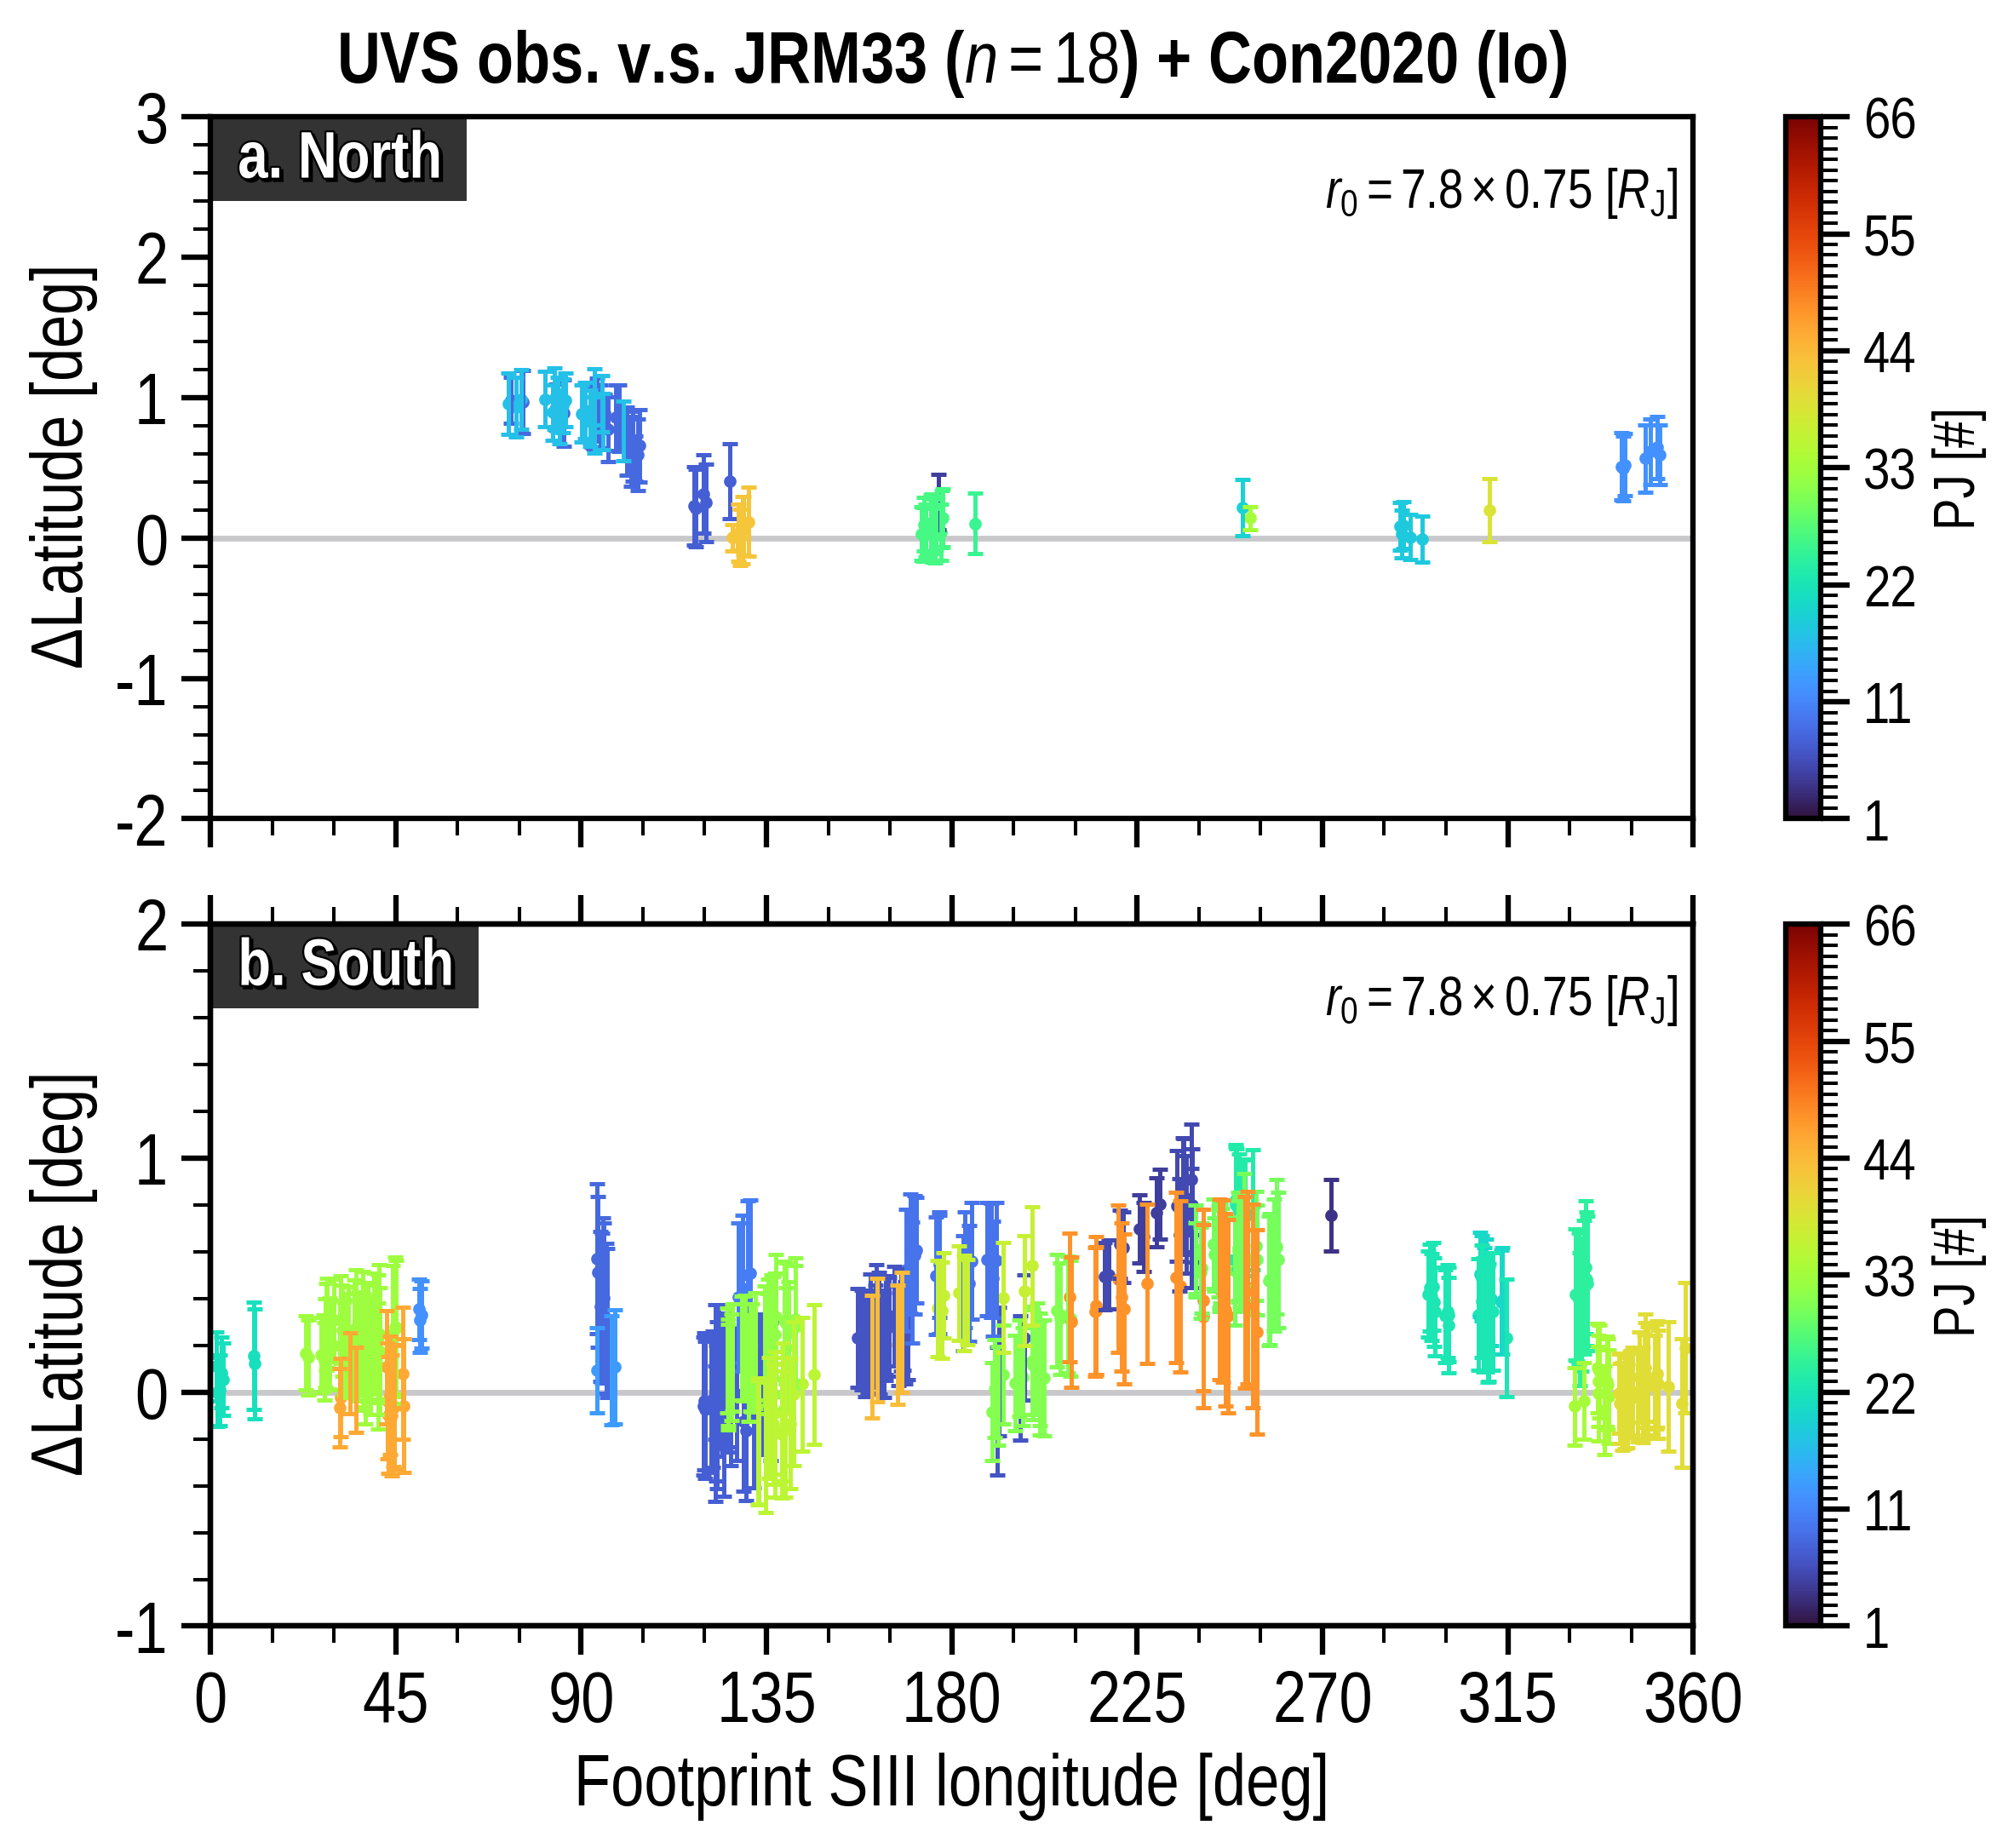

In [ ]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Footprint SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1
    sc = F.ax[ax_idx].scatter(wlon_fp_select[j],
                              sgn*(lat_fp_select[j]-lat_fp_18_075r0[j]),
                              s=5.0, c=pj_fp[j], cmap=cmap, vmin=vmin, vmax=vmax)
    F.ax[ax_idx].errorbar(x=wlon_fp_select[j],
                          y=sgn*(lat_fp_select[j]-lat_fp_18_075r0[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color=cmap(norm(pj_fp[j])))

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

for i in range(2):
    F.ax[i].text(0.99, 0.93, r'$r_0 = 7.8 \times 0.75$ [$R_{\rm J}$]',
                 color='k',
                 fontsize=F.fontsize*0.75,
                 verticalalignment='top',
                 horizontalalignment='right',
                 transform=F.ax[i].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(1, 66, 7))
    cax.ax.set_yticklabels(np.linspace(
        1, 66, 7, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(11))
    cax.ax.set_ylabel(r'PJ [#]', fontsize=F.fontsize*0.8)

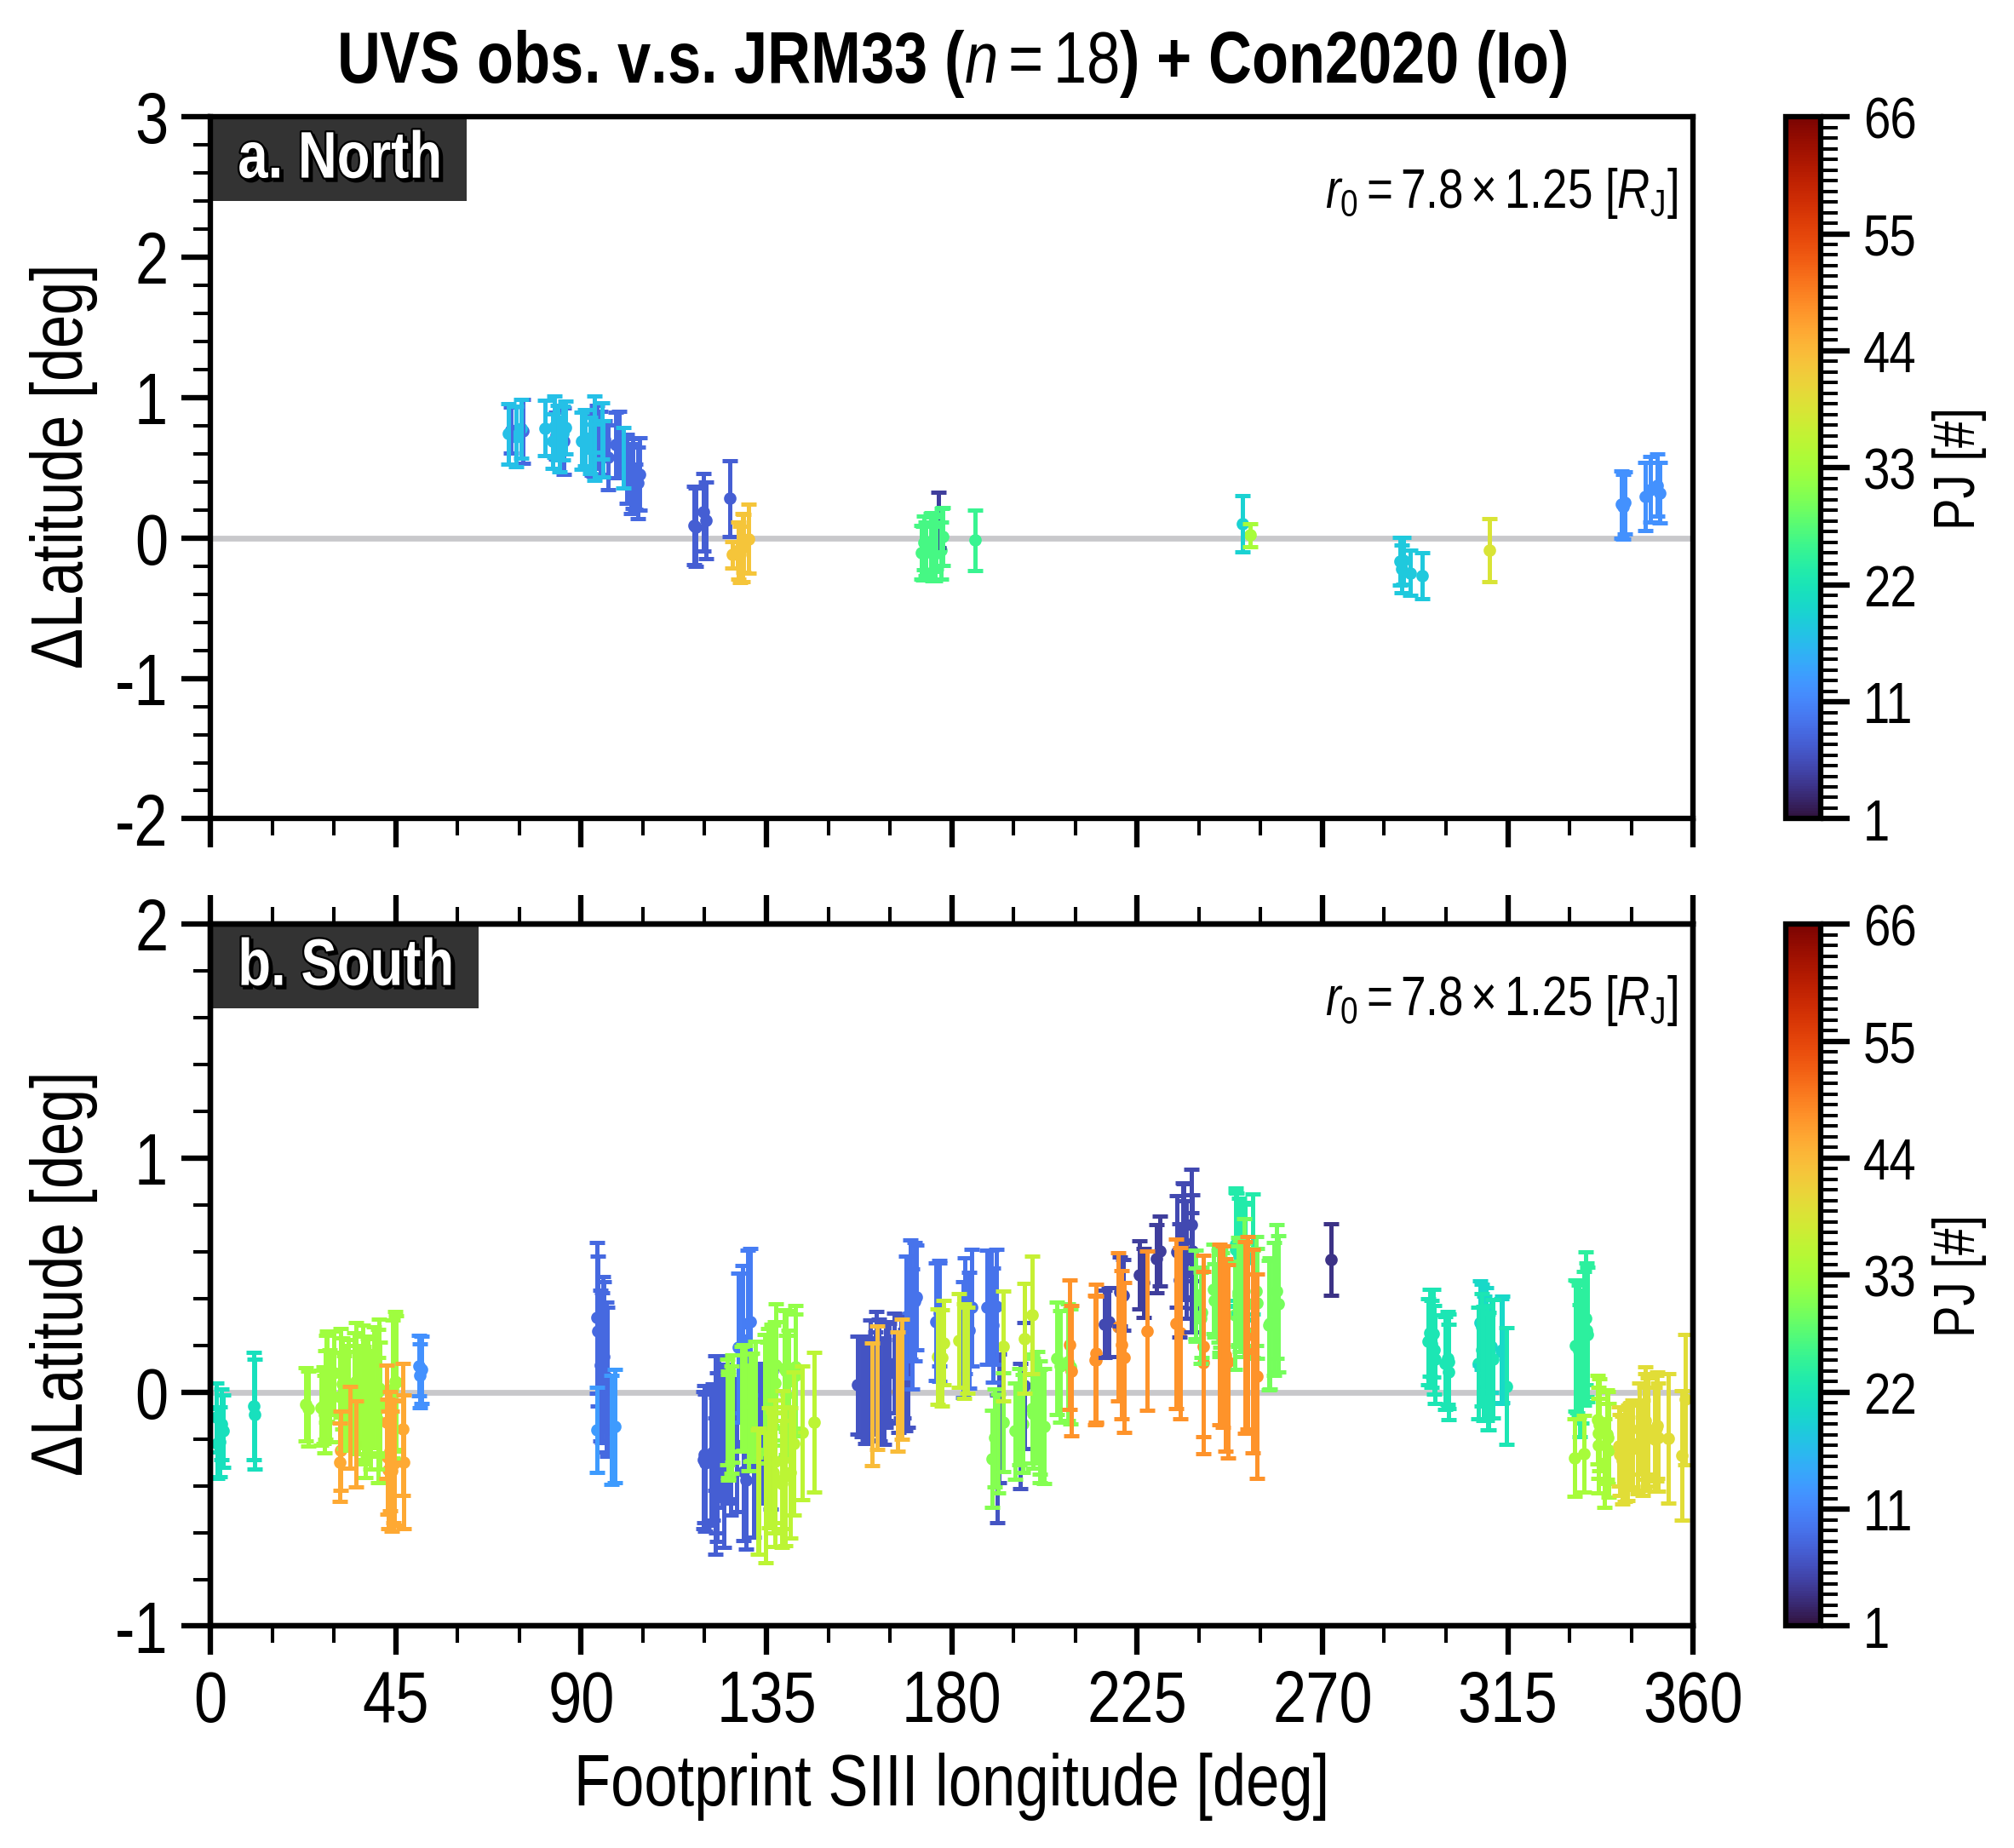

In [ ]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Footprint SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1
    sc = F.ax[ax_idx].scatter(wlon_fp_select[j],
                              sgn*(lat_fp_select[j]-lat_fp_18_125r0[j]),
                              s=5.0, c=pj_fp[j], cmap=cmap, vmin=vmin, vmax=vmax)
    F.ax[ax_idx].errorbar(x=wlon_fp_select[j],
                          y=sgn*(lat_fp_select[j]-lat_fp_18_125r0[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color=cmap(norm(pj_fp[j])))

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

for i in range(2):
    F.ax[i].text(0.99, 0.93, r'$r_0 = 7.8 \times 1.25$ [$R_{\rm J}$]',
                 color='k',
                 fontsize=F.fontsize*0.75,
                 verticalalignment='top',
                 horizontalalignment='right',
                 transform=F.ax[i].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(1, 66, 7))
    cax.ax.set_yticklabels(np.linspace(
        1, 66, 7, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(11))
    cax.ax.set_ylabel(r'PJ [#]', fontsize=F.fontsize*0.8)

[ 0.10225606 -0.07509569 -0.40893059  0.23729786 -1.29053673  0.14047552
  0.59265528 -0.08318368  0.74048241  0.13464075  0.94035971]


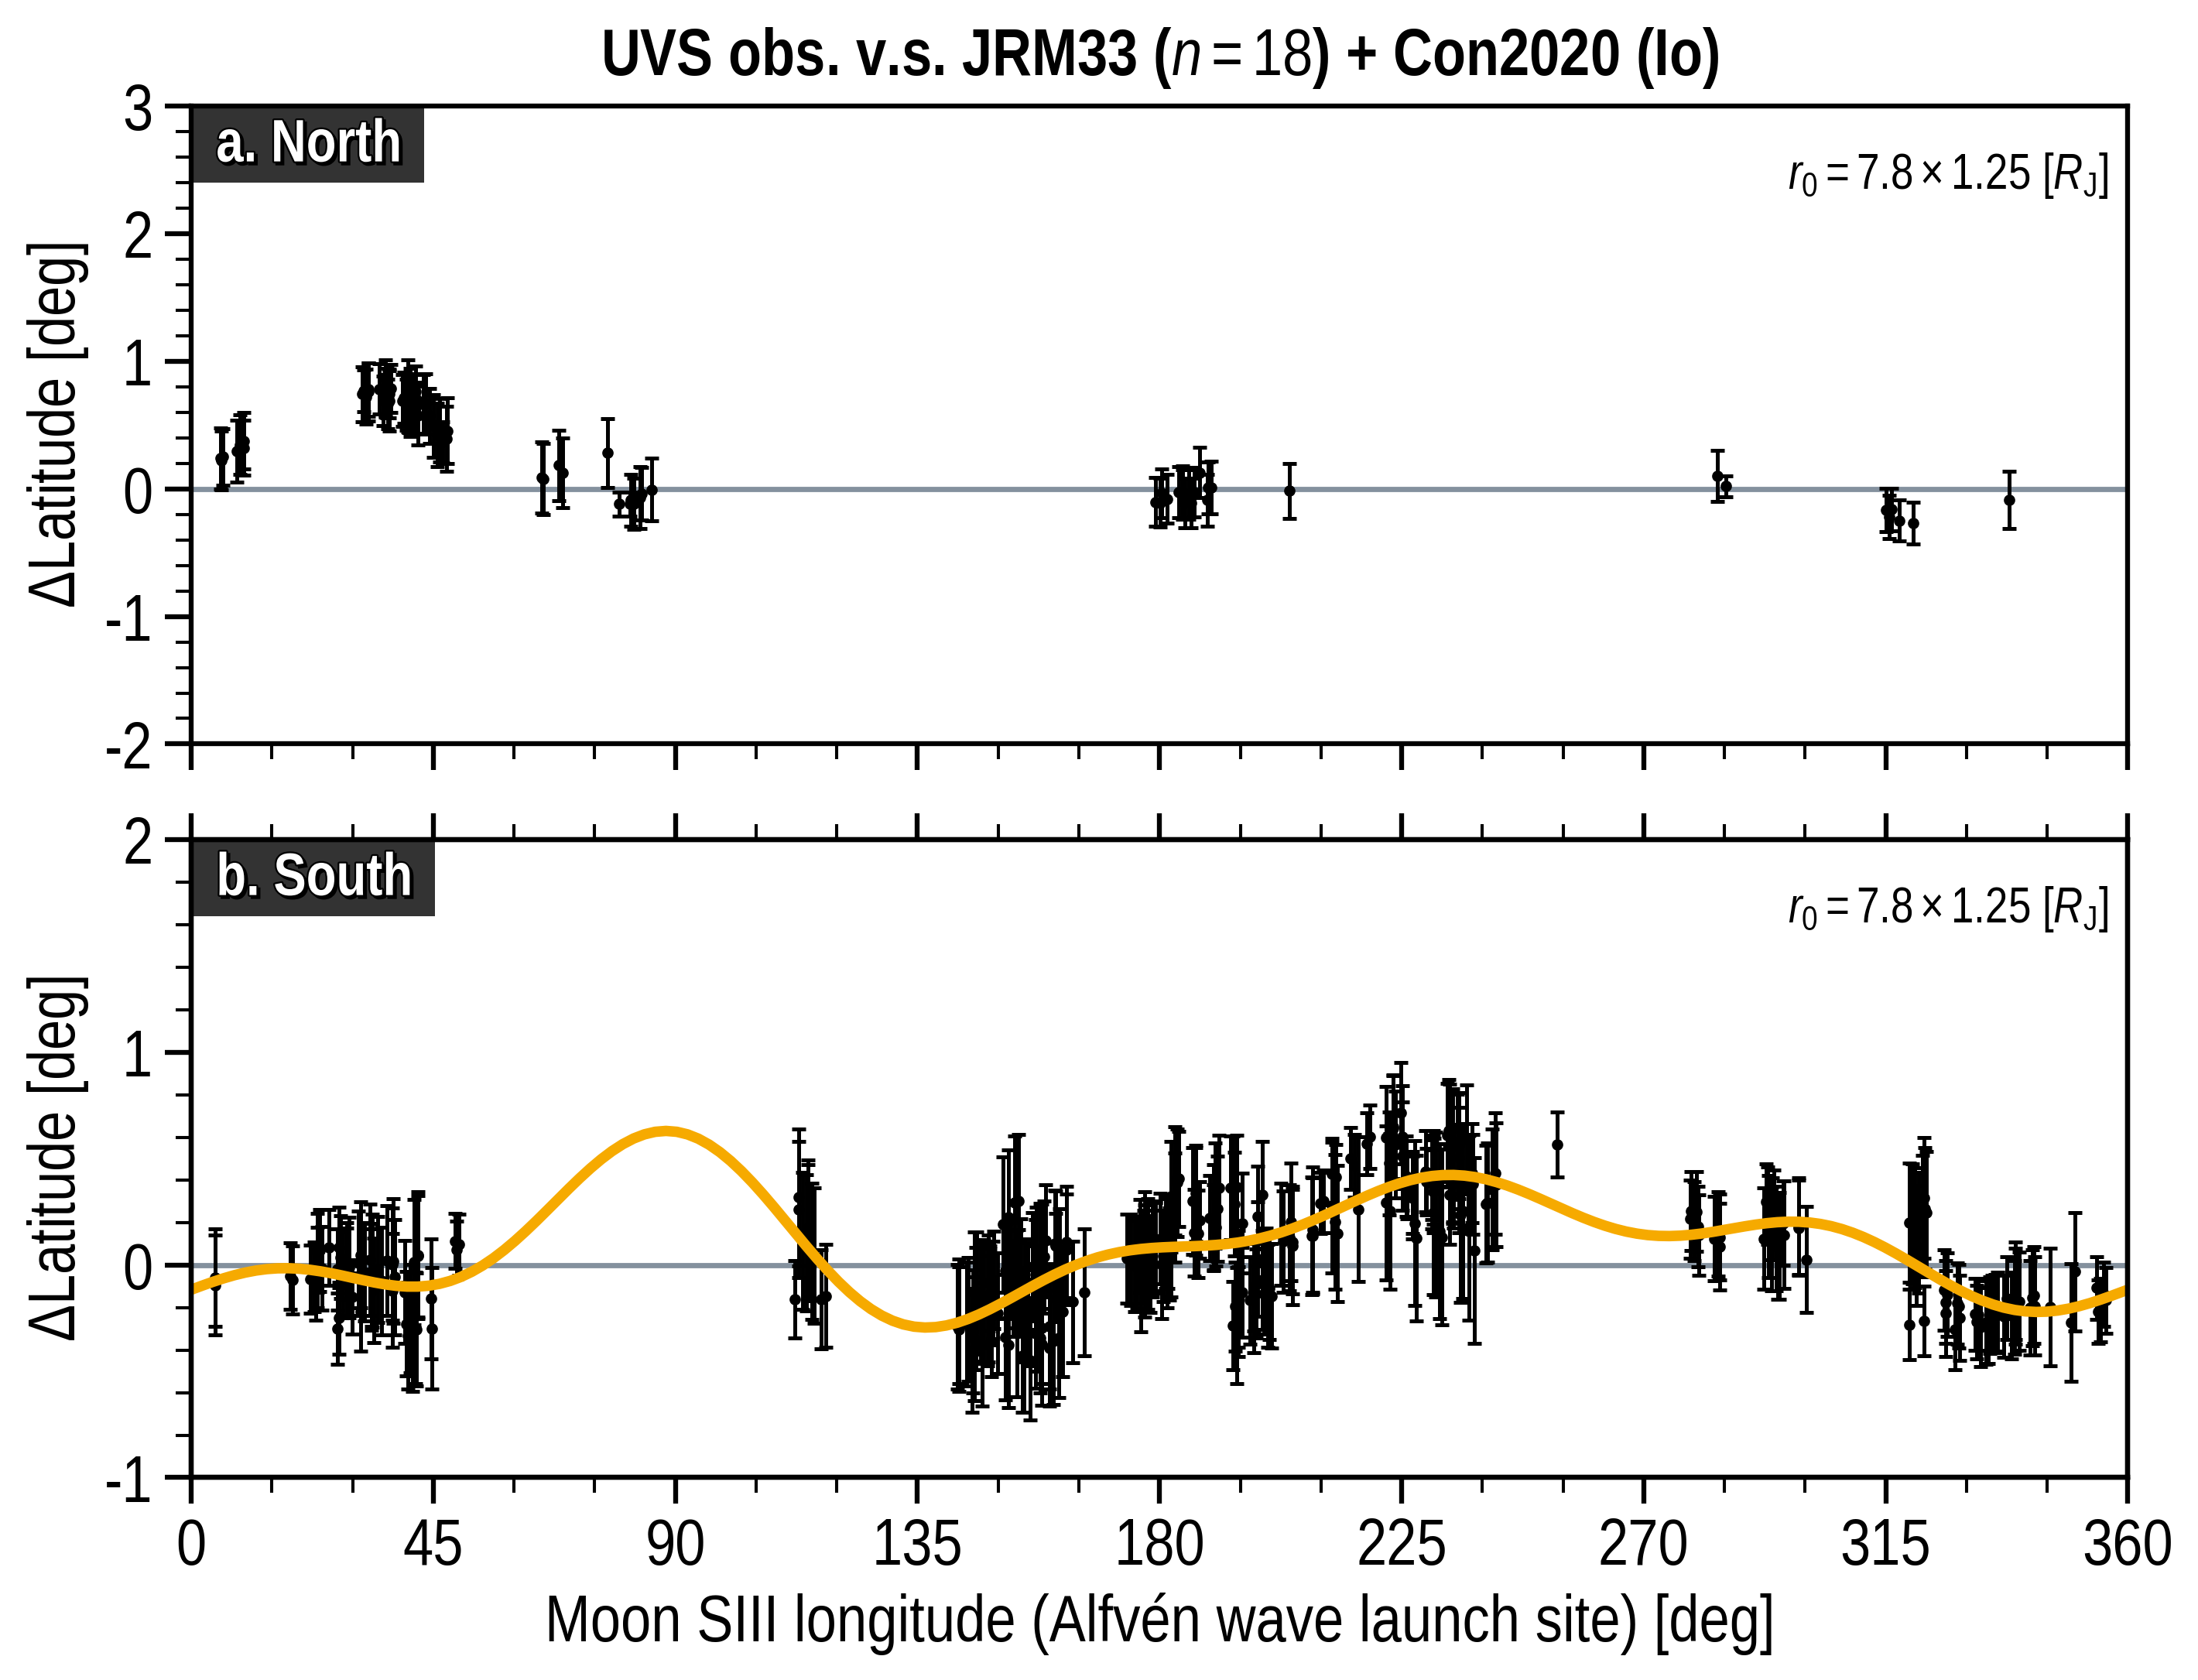

In [ ]:
# SIII依存性をフィッティング(南Dawn)
from scipy.optimize import curve_fit


def fitfunc(x, a0, a, b, c, d, e, f, g, h, i, j):
    # x: SIII west longitude [deg]
    phi = np.radians(360.0-x)
    y = a0 + a*np.cos(phi-b) + c*np.cos(2.0*(phi-d)) + \
        e*np.cos(3.0*(phi-f)) + g*np.cos(4.0*(phi-h)) + i*np.cos(5.0*(phi-j))
    return y


F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(9, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Moon SIII longitude (Alfvén wave launch site) [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 0.0
vmax = 24.0
cmap = cmocean.cm.balance
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

deltalat_N = []
deltalat_S = []
moonS3wlon_N = []
moonS3wlon_S = []
for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        data_list_j = deltalat_N
        data_list_j_moonS3wlon = moonS3wlon_N
    else:
        ax_idx = 1
        sgn = -1
        data_list_j = deltalat_S
        data_list_j_moonS3wlon = moonS3wlon_S

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    r_JSO = IAU2JSO(et=et_fp_select[j],
                    r_IAU=np.array([x_fp_polar, y_fp_polar, z_fp_polar]))

    delta = wlon_fp_select[j]-wlon_defaultfp[j]
    lt = 12

    data_list_j_moonS3wlon += [moon_S3wlon_select[j]-eqlead_fp[j]]
    data_list_j += [sgn*(lat_fp_select[j]-lat_fp_18_125r0[j])]

    sc = F.ax[ax_idx].scatter(moon_S3wlon_select[j]-eqlead_fp[j],
                              sgn*(lat_fp_select[j]-lat_fp_18_125r0[j]),
                              s=5.0, c='k')
    F.ax[ax_idx].errorbar(x=moon_S3wlon_select[j]-eqlead_fp[j],
                          y=sgn*(lat_fp_select[j]-lat_fp_18_125r0[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color='k')

# South fitting
sort = np.argsort(np.array(moonS3wlon_S))
popt_s3, pcov = curve_fit(fitfunc,
                          np.array(moonS3wlon_S)[sort],
                          np.array(deltalat_S)[sort])
print(popt_s3)
x_fit = np.linspace(0, 359.0, 180)
y_fit = fitfunc(x_fit, popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3],
                popt_s3[4], popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8],
                popt_s3[9], popt_s3[10])
F.ax[1].plot(x_fit, y_fit, linewidth=3.0, color=UC.orange)

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

for i in range(2):
    F.ax[i].text(0.99, 0.93, r'$r_0 = 7.8 \times 1.25$ [$R_{\rm J}$]',
                 color='k',
                 fontsize=F.fontsize*0.75,
                 verticalalignment='top',
                 horizontalalignment='right',
                 transform=F.ax[i].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.gray, zorder=0.9)

[ 0.15236781  0.24901154 -2.67047321]


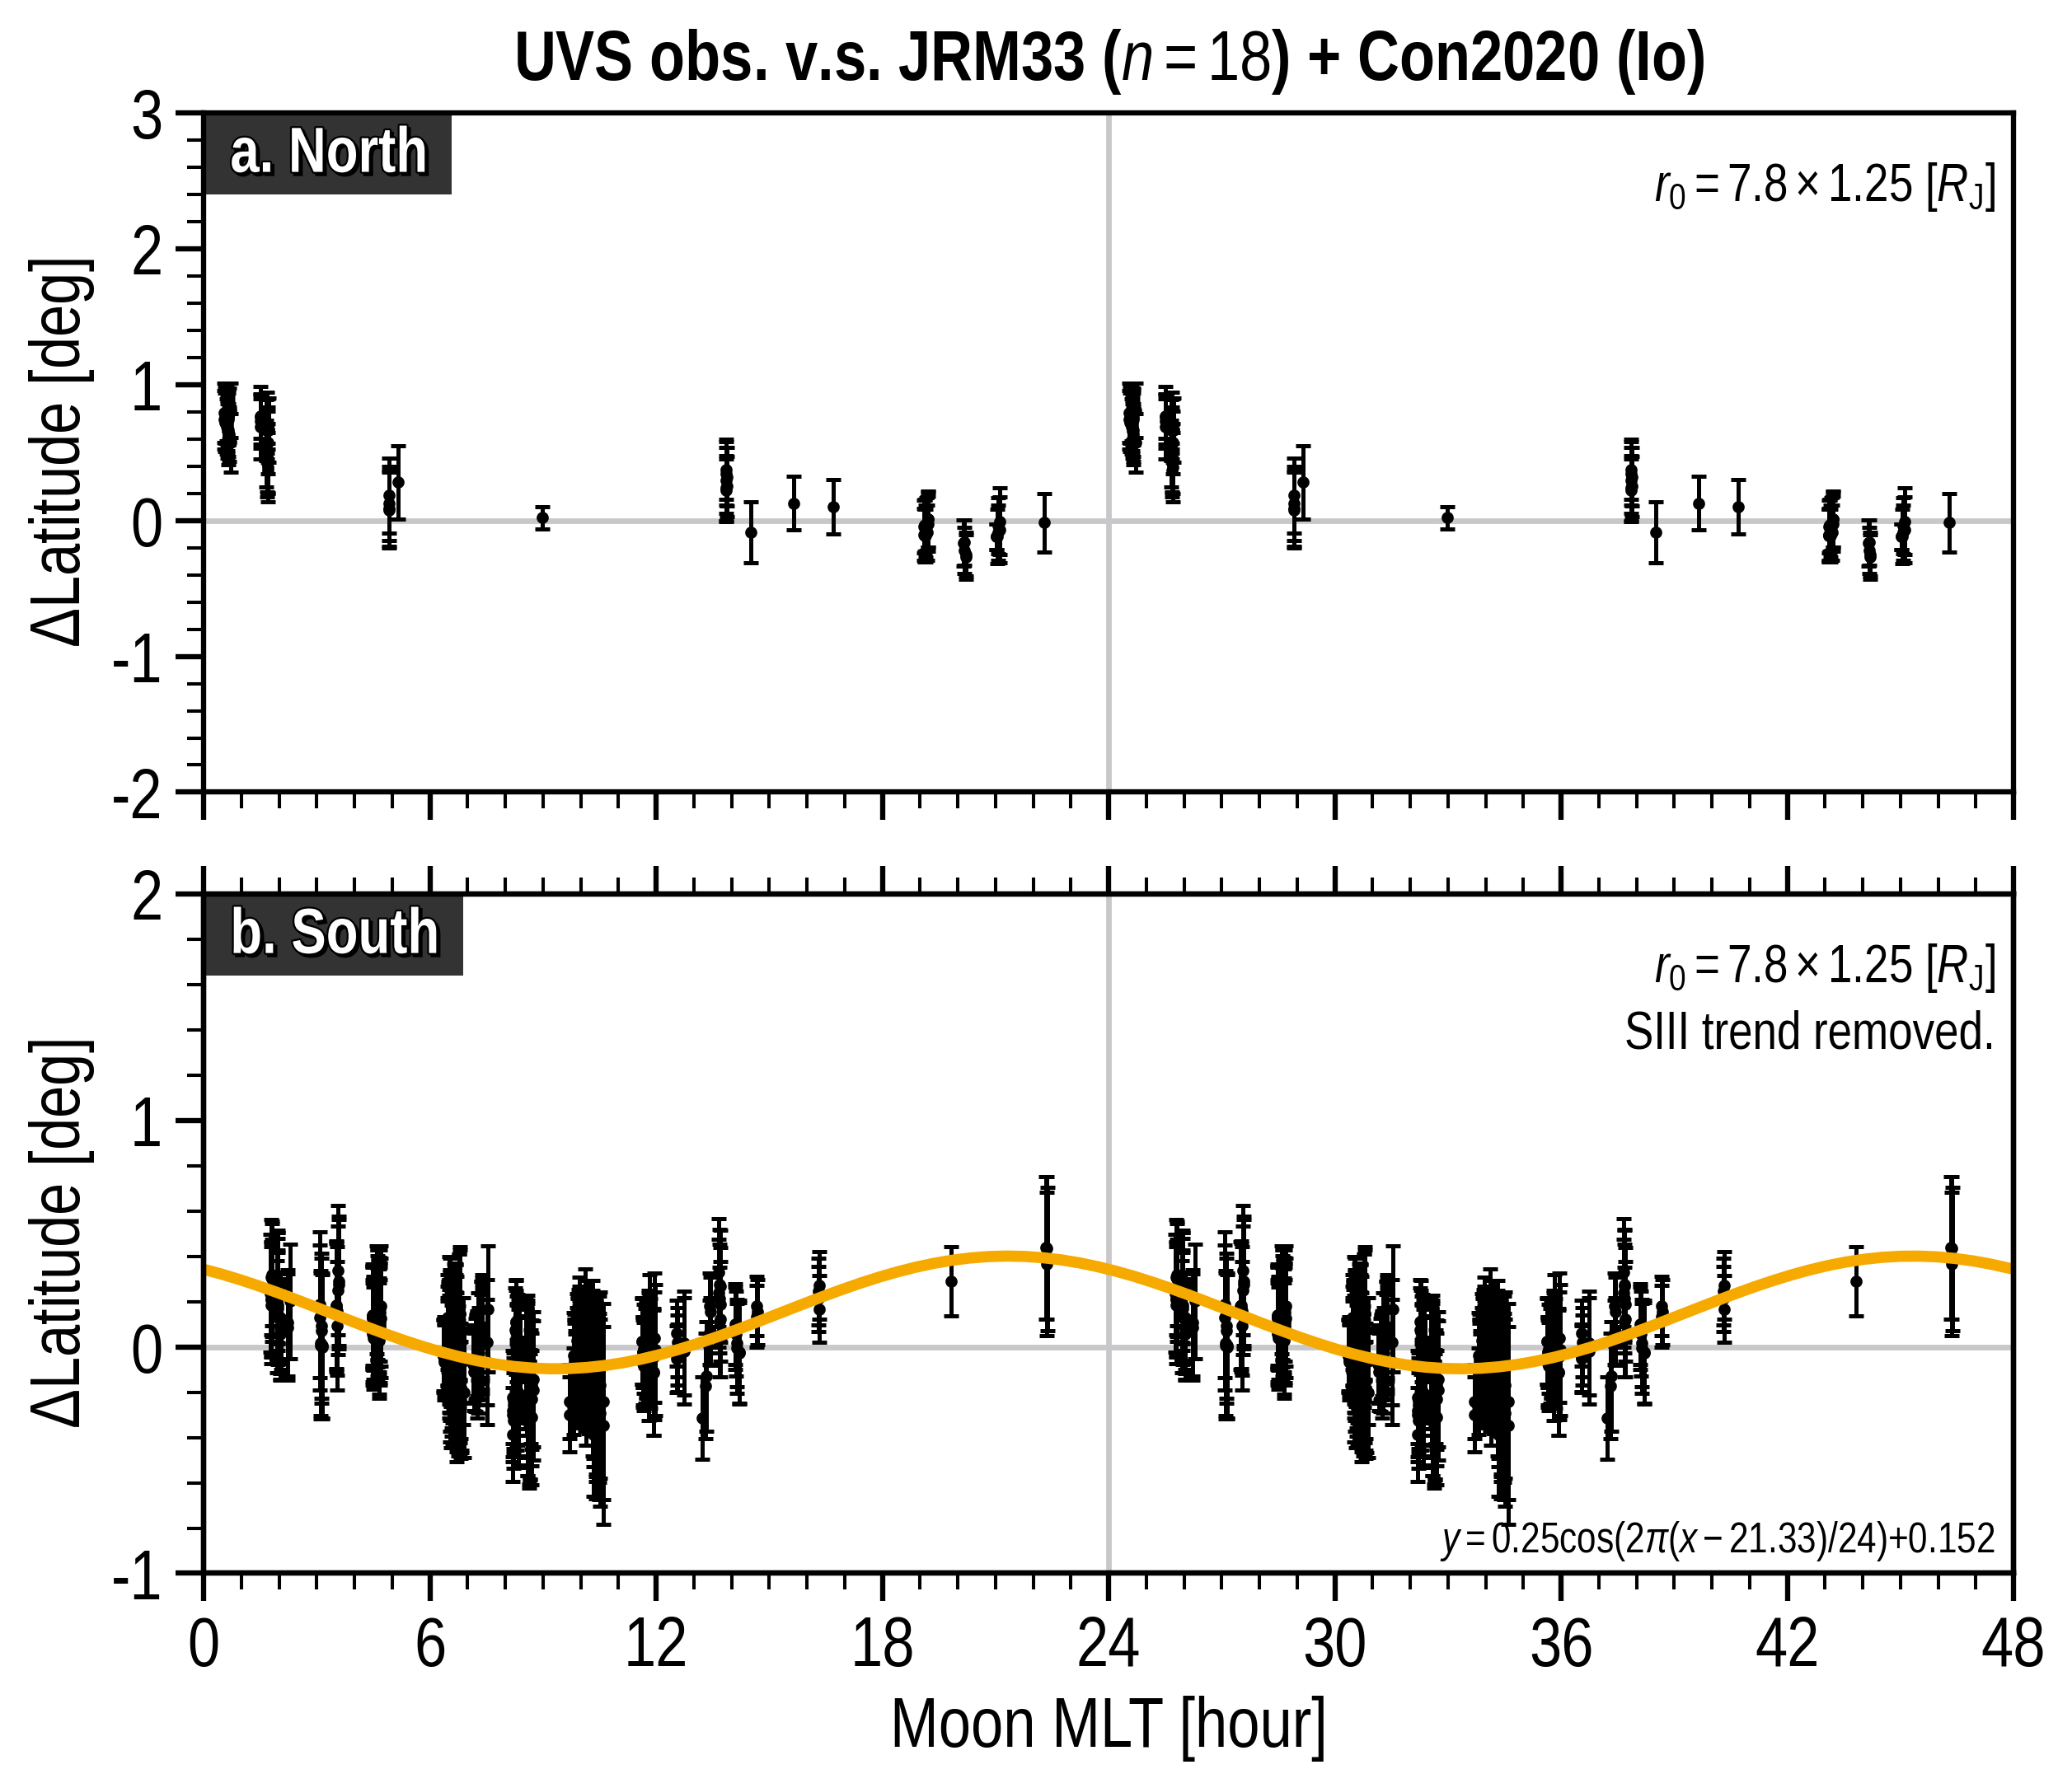

In [ ]:
# SIII依存性を差し引いてMLT依存性をフィッティング(南)
def fitfunc_MLT(MLT, a, b, c):
    y = a + b*np.cos((2*np.pi/24.0)*(MLT-c))
    return y


F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

deltalat_N = []
deltalat_S = []
MLT_N = []
MLT_S = []
for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        data_list_j = deltalat_N
        MLT_list_j = MLT_N
    else:
        ax_idx = 1
        sgn = -1
        data_list_j = deltalat_S
        MLT_list_j = MLT_S

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)

    if hem_fp_select[j] < 0:
        y = sgn*(lat_fp_select[j]-lat_fp_18_125r0[j])
    else:
        SIII_fit = fitfunc(moon_S3wlon_select[j]-eqlead_fp[j],
                           popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3], popt_s3[4],
                           popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8], popt_s3[9],
                           popt_s3[10])
        y = sgn*(lat_fp_select[j]-lat_fp_18_125r0[j])-SIII_fit

    data_list_j += [y]
    MLT_list_j += [lt]

    for i in range(2):
        sc = F.ax[ax_idx].scatter(lt+24.0*i,
                                  y,
                                  s=5.0, c='k')
        F.ax[ax_idx].errorbar(x=lt+24.0*i,
                              y=y,
                              yerr=err_lat_fp_select[j],
                              elinewidth=1.1, linewidth=0., markersize=0.,
                              capsize=2.0, capthick=1.1,
                              color='k')

# Dawn fitting
sort = np.argsort(np.array(MLT_S))
popt_lt, pcov = curve_fit(fitfunc_MLT,
                          np.array(MLT_S)[sort],
                          np.array(deltalat_S)[sort])
print(popt_lt)
x_fit = np.linspace(0, 47.9, 100)
y_fit = fitfunc_MLT(x_fit, popt_lt[0], popt_lt[1], popt_lt[2])
F.ax[1].plot(x_fit, y_fit, linewidth=3.0, color=UC.orange)
y_fit_label = r'$y=$' + str(round(popt_lt[1], 2)) +\
    r'cos(2$\pi(x-$'+str(round(24.0+popt_lt[2], 2))+')/24)+' +\
    str(round(popt_lt[0], 3))

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

F.ax[1].text(0.99, 0.83, r'SIII trend removed.',
             color='k',
             fontsize=F.fontsize*0.75,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)
F.ax[1].text(0.99, 0.08,
             y_fit_label,
             color='k',
             fontsize=F.fontsize*0.6,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

for i in range(2):
    F.ax[i].text(0.99, 0.93, r'$r_0 = 7.8 \times 1.25$ [$R_{\rm J}$]',
                 color='k',
                 fontsize=F.fontsize*0.75,
                 verticalalignment='top',
                 horizontalalignment='right',
                 transform=F.ax[i].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    F.ax[i].axvline(x=24.0, color=UC.lightgray, zorder=0.9)

# Duskで双極子化する電流シートをテストする 1

<span style="color: yellow;">Azimuthal current constantと内側境界距離にMLT依存性ありの場合</span>

In [ ]:
# 合成した電流シートをプロット
MLT_arr = np.linspace(0.0, 47.999, 100)

F = ShareXaxis()
F.fontsize = 21
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=1, figsize=(7, 4), dpi='XL')
F.hspace = 0.15
F.initialize()

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\mu_0 I_\varphi /2$ [nT]',
            min=80, max=200,
            ticks=np.linspace(80, 200, 7),
            ticklabels=np.linspace(80, 200, 7, dtype=int),
            minor_num=4,
            labelcolor=UC.blue,
            axiscolor=UC.blue)
F.ax.plot(MLT_arr, mui_MLT(MLT_arr), linewidth=2.0, color=UC.blue,)

ax2 = F.ax.twinx()
ax2.tick_params(axis='y', which='both',
                labelsize=F.fontsize,
                colors=UC.orange)
ax2.set_ylabel(r'$r_0$ [$R_{\rm J}$]', fontsize=F.fontsize,
               color=UC.orange)
ax2.spines['left'].set_color(UC.blue)
ax2.spines['right'].set_color(UC.orange)
ax2.set_ylim(5, 11)
ax2.set_yticks(np.linspace(5, 11, 7))
ax2.yaxis.set_minor_locator(ptick.AutoMinorLocator(4))
ax2.plot(MLT_arr, r0_MLT(MLT_arr), linewidth=2.0, color=UC.orange,)

F.ax.set_title(r'Adjusted current sheet parameter', weight='bold')

F.ax.axvline(x=24.0, color=UC.lightgray, zorder=0.9)

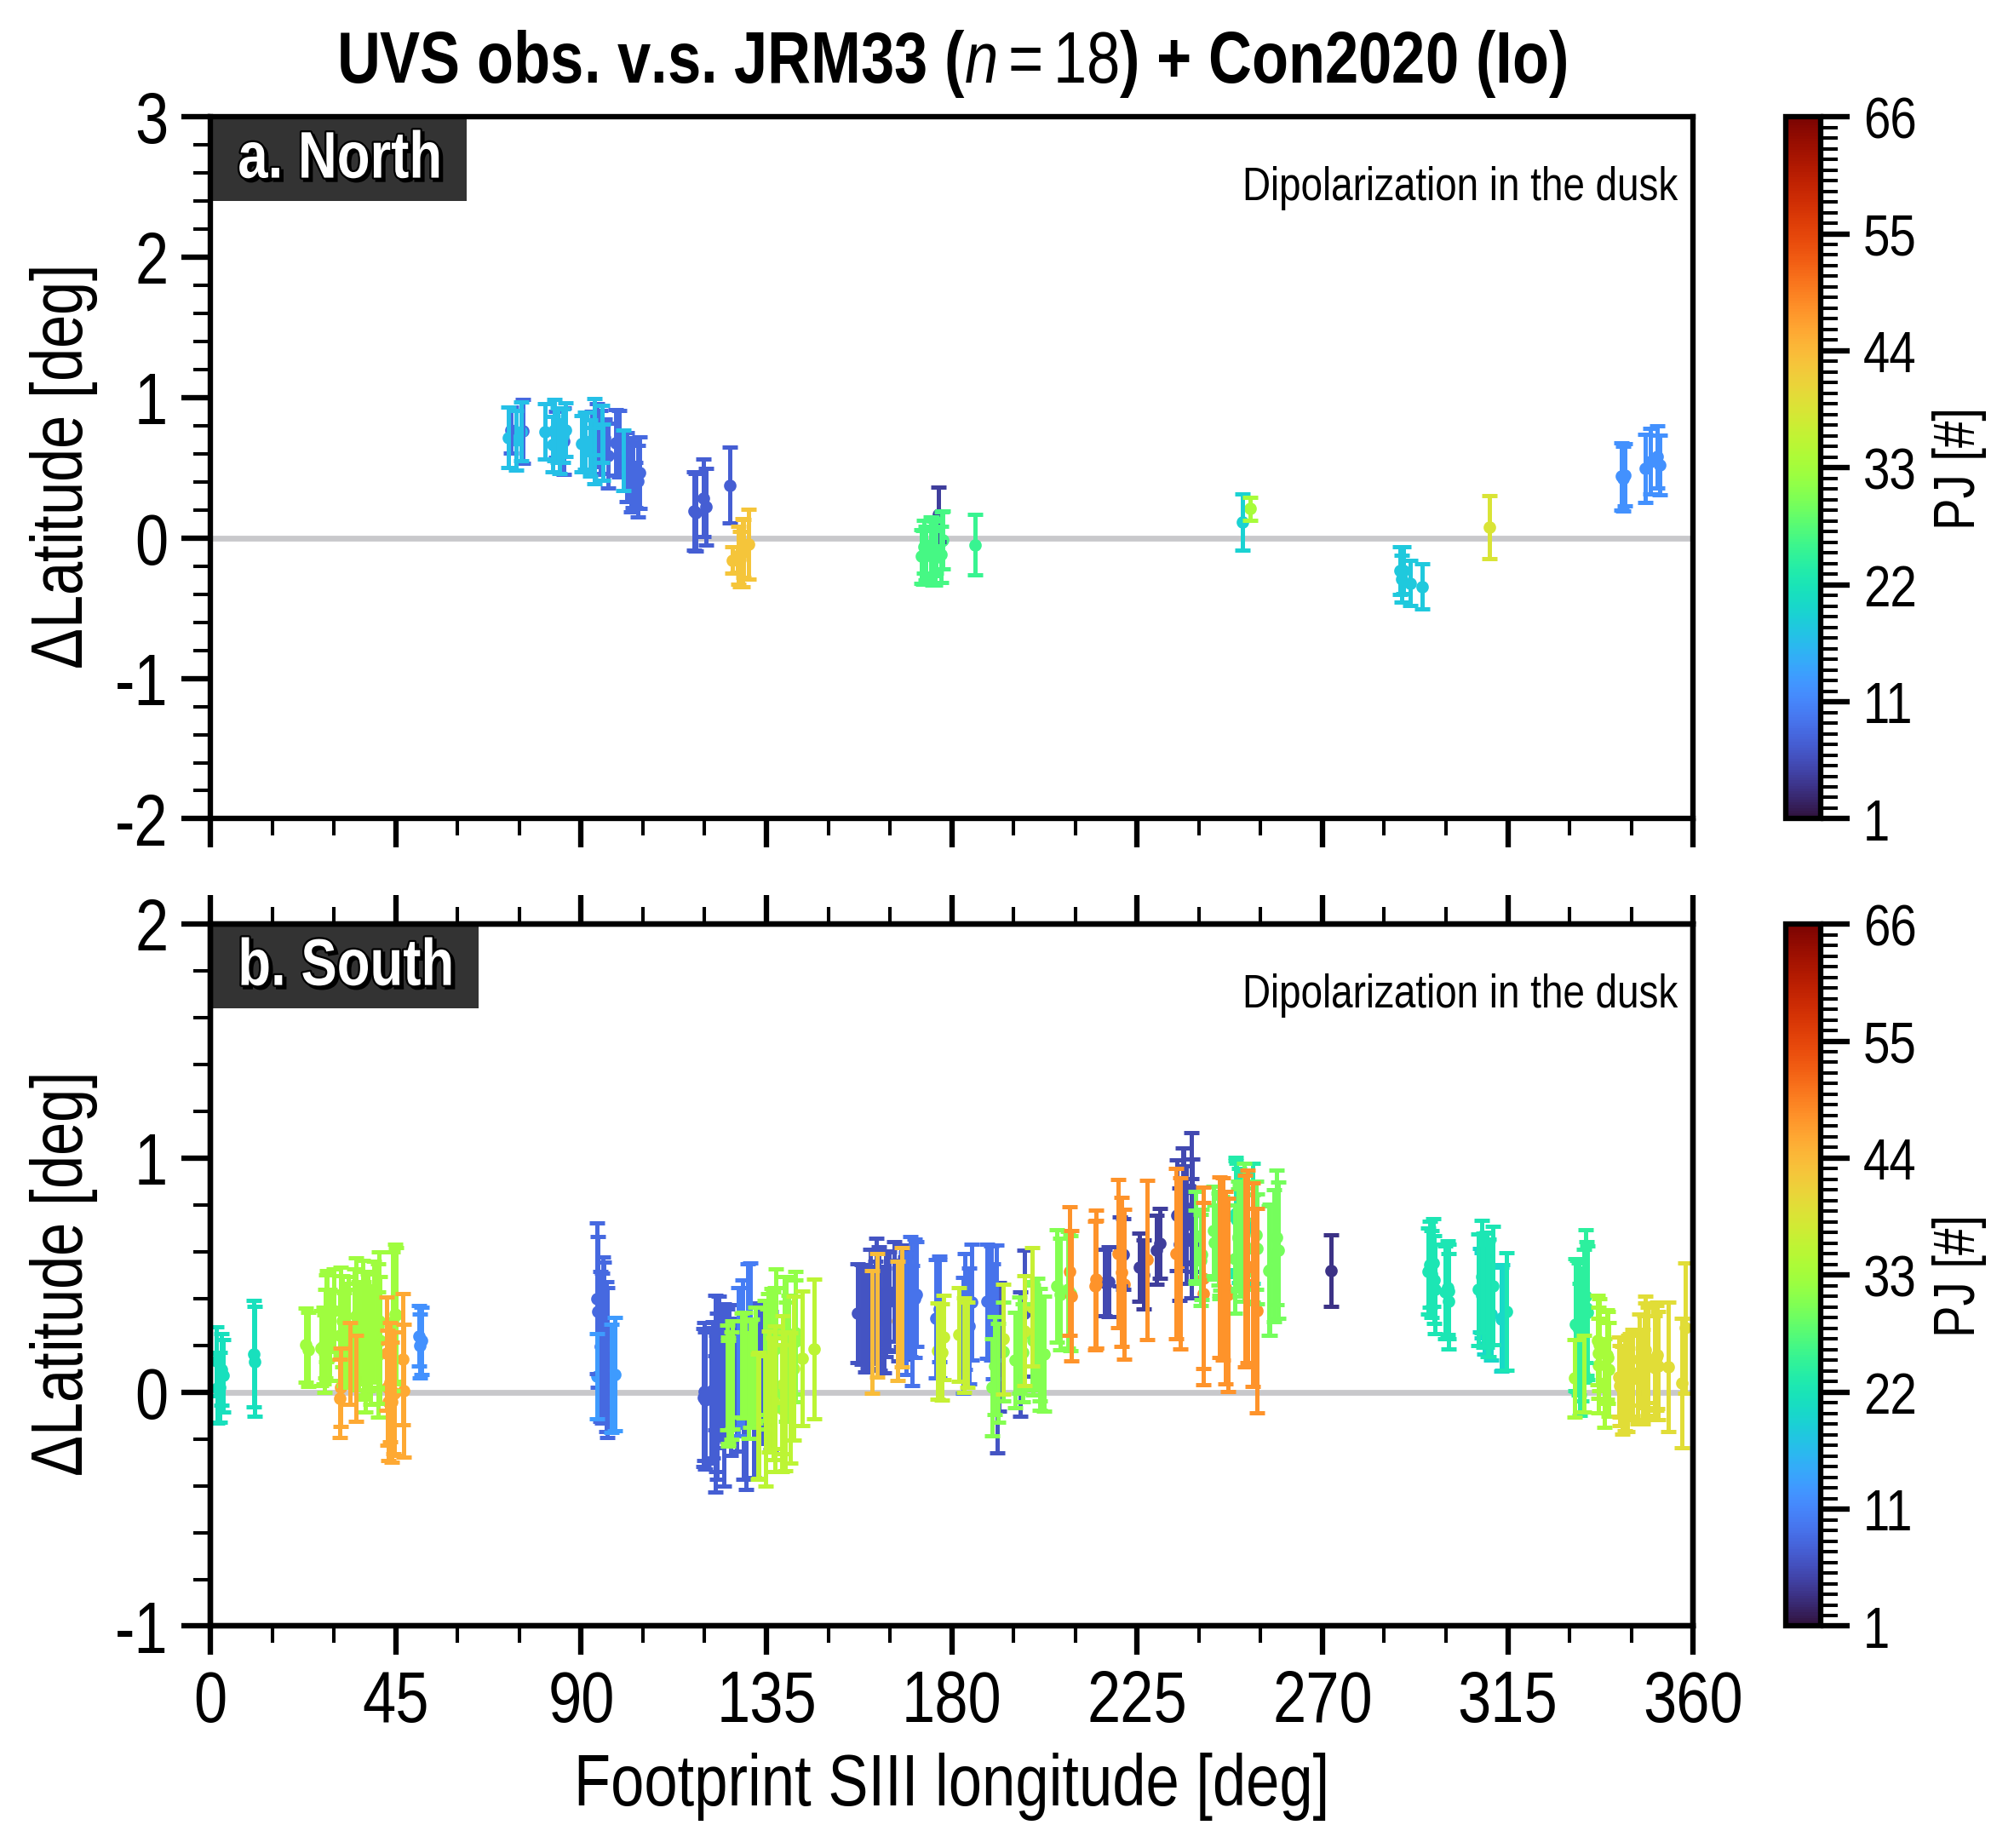

In [ ]:
# 合成した電流シートをプロット
MLT_arr = np.linspace(0.0, 47.999, 100)

F = ShareXaxis()
F.fontsize = 21
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=1, figsize=(7, 4), dpi='XL')
F.hspace = 0.15
F.initialize()

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\mu_0 I_\varphi /2$ [nT]',
            min=80, max=200,
            ticks=np.linspace(80, 200, 7),
            ticklabels=np.linspace(80, 200, 7, dtype=int),
            minor_num=4,
            labelcolor=UC.blue,
            axiscolor=UC.blue)
F.ax.plot(MLT_arr, mui_MLT(MLT_arr), linewidth=2.0, color=UC.blue,)

ax2 = F.ax.twinx()
ax2.tick_params(axis='y', which='both',
                labelsize=F.fontsize,
                colors=UC.orange)
ax2.set_ylabel(r'$r_0$ [$R_{\rm J}$]', fontsize=F.fontsize,
               color=UC.orange)
ax2.spines['left'].set_color(UC.blue)
ax2.spines['right'].set_color(UC.orange)
ax2.set_ylim(5, 11)
ax2.set_yticks(np.linspace(5, 11, 7))
ax2.yaxis.set_minor_locator(ptick.AutoMinorLocator(4))
ax2.plot(MLT_arr, r0_MLT(MLT_arr), linewidth=2.0, color=UC.orange,)

F.ax.set_title(r'Adjusted current sheet parameter', weight='bold')

F.ax.axvline(x=24.0, color=UC.lightgray, zorder=0.9)

[ 0.31774039  0.08874865  1.97967616  0.21295169 -1.22280842  0.09903626
  0.60449441 -0.07134975  0.77266757  0.11153098  0.94992559]


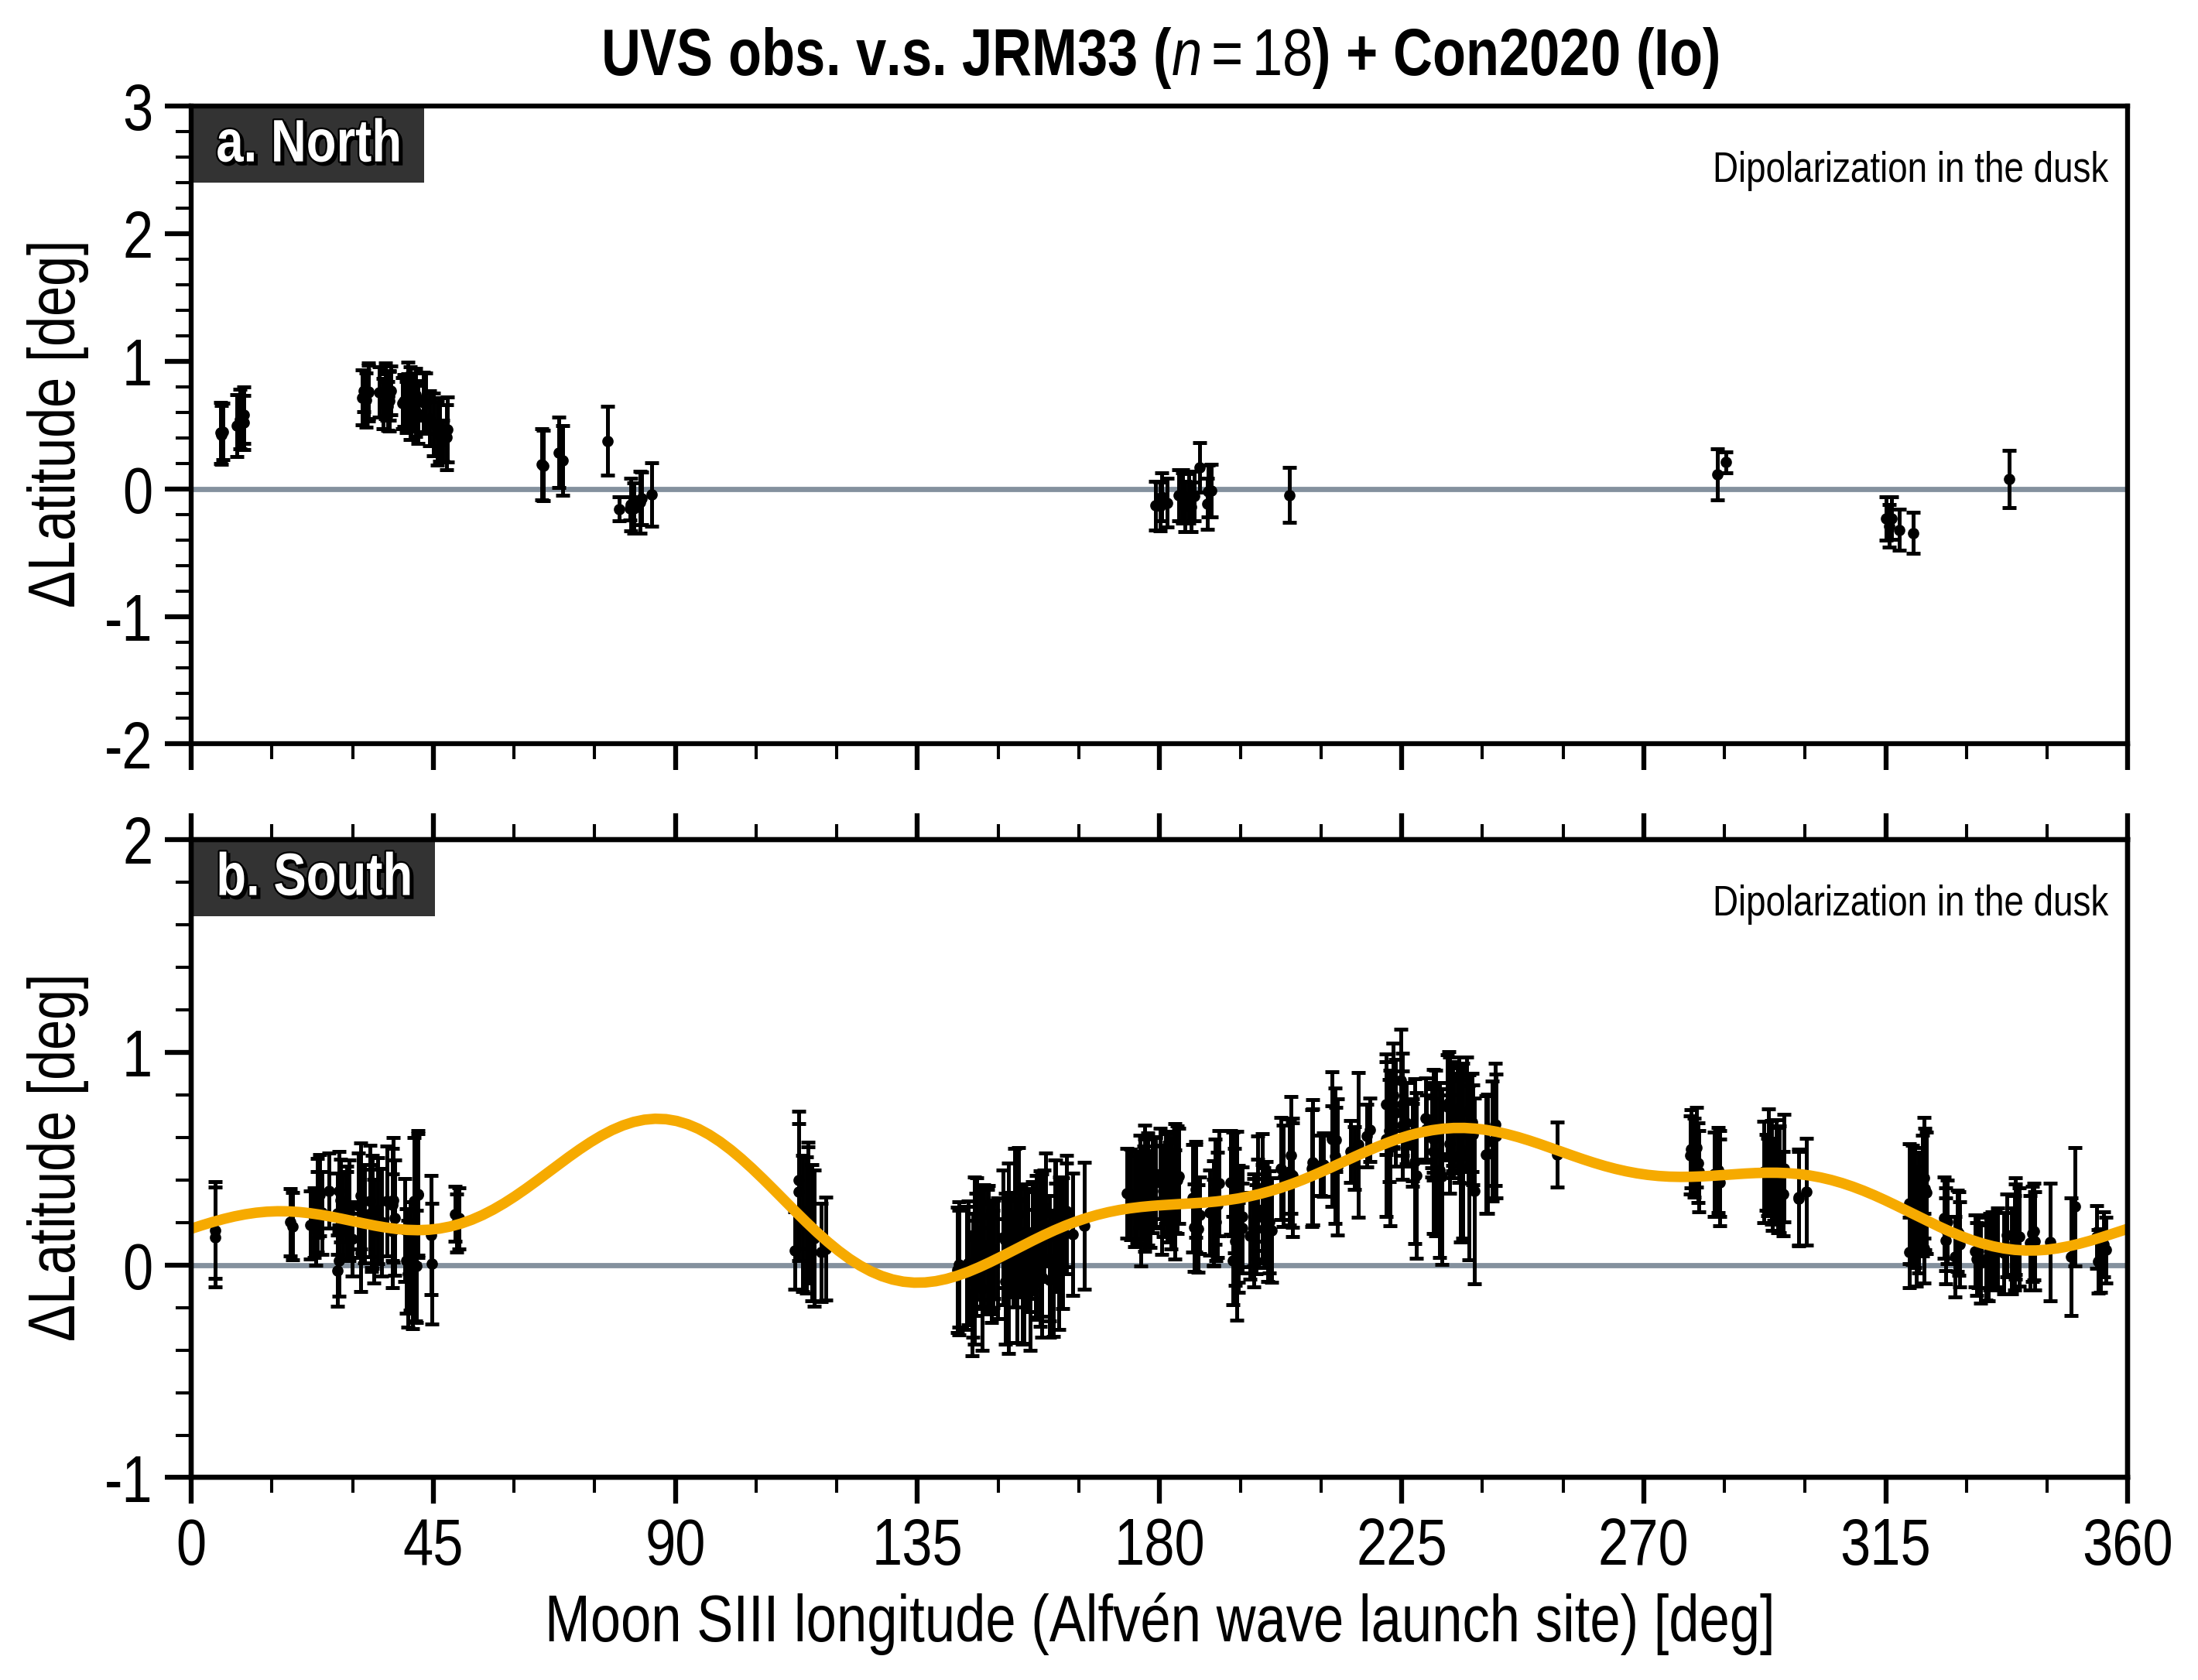

In [ ]:
# SIII依存性をフィッティング(南Dawn)
from scipy.optimize import curve_fit


def fitfunc(x, a0, a, b, c, d, e, f, g, h, i, j):
    # x: SIII west longitude [deg]
    phi = np.radians(360.0-x)
    y = a0 + a*np.cos(phi-b) + c*np.cos(2.0*(phi-d)) + \
        e*np.cos(3.0*(phi-f)) + g*np.cos(4.0*(phi-h)) + i*np.cos(5.0*(phi-j))
    return y


F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(9, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Moon SIII longitude (Alfvén wave launch site) [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 0.0
vmax = 24.0
cmap = cmocean.cm.balance
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

deltalat_N = []
deltalat_S = []
moonS3wlon_N = []
moonS3wlon_S = []
for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        data_list_j = deltalat_N
        data_list_j_moonS3wlon = moonS3wlon_N
    else:
        ax_idx = 1
        sgn = -1
        data_list_j = deltalat_S
        data_list_j_moonS3wlon = moonS3wlon_S

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    r_JSO = IAU2JSO(et=et_fp_select[j],
                    r_IAU=np.array([x_fp_polar, y_fp_polar, z_fp_polar]))

    delta = wlon_fp_select[j]-wlon_defaultfp[j]
    lt = 12

    data_list_j_moonS3wlon += [moon_S3wlon_select[j]-eqlead_fp[j]]
    data_list_j += [sgn*(lat_fp_select[j]-lat_fp_18_mui_r0[j])]

    sc = F.ax[ax_idx].scatter(moon_S3wlon_select[j]-eqlead_fp[j],
                              sgn*(lat_fp_select[j]-lat_fp_18_mui_r0[j]),
                              s=5.0, c='k')
    F.ax[ax_idx].errorbar(x=moon_S3wlon_select[j]-eqlead_fp[j],
                          y=sgn*(lat_fp_select[j]-lat_fp_18_mui_r0[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color='k')

# South fitting
sort = np.argsort(np.array(moonS3wlon_S))
popt_s3, pcov = curve_fit(fitfunc,
                          np.array(moonS3wlon_S)[sort],
                          np.array(deltalat_S)[sort])
print(popt_s3)
x_fit = np.linspace(0, 359.0, 180)
y_fit = fitfunc(x_fit, popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3],
                popt_s3[4], popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8],
                popt_s3[9], popt_s3[10])
F.ax[1].plot(x_fit, y_fit, linewidth=3.0, color=UC.orange)

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

for i in range(2):
    F.ax[i].text(0.99, 0.93, r'Dipolarization in the dusk',
                 color='k',
                 fontsize=F.fontsize*0.65,
                 verticalalignment='top',
                 horizontalalignment='right',
                 transform=F.ax[i].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.gray, zorder=0.9)

[ 0.03087533  0.05124294 -2.53136932]


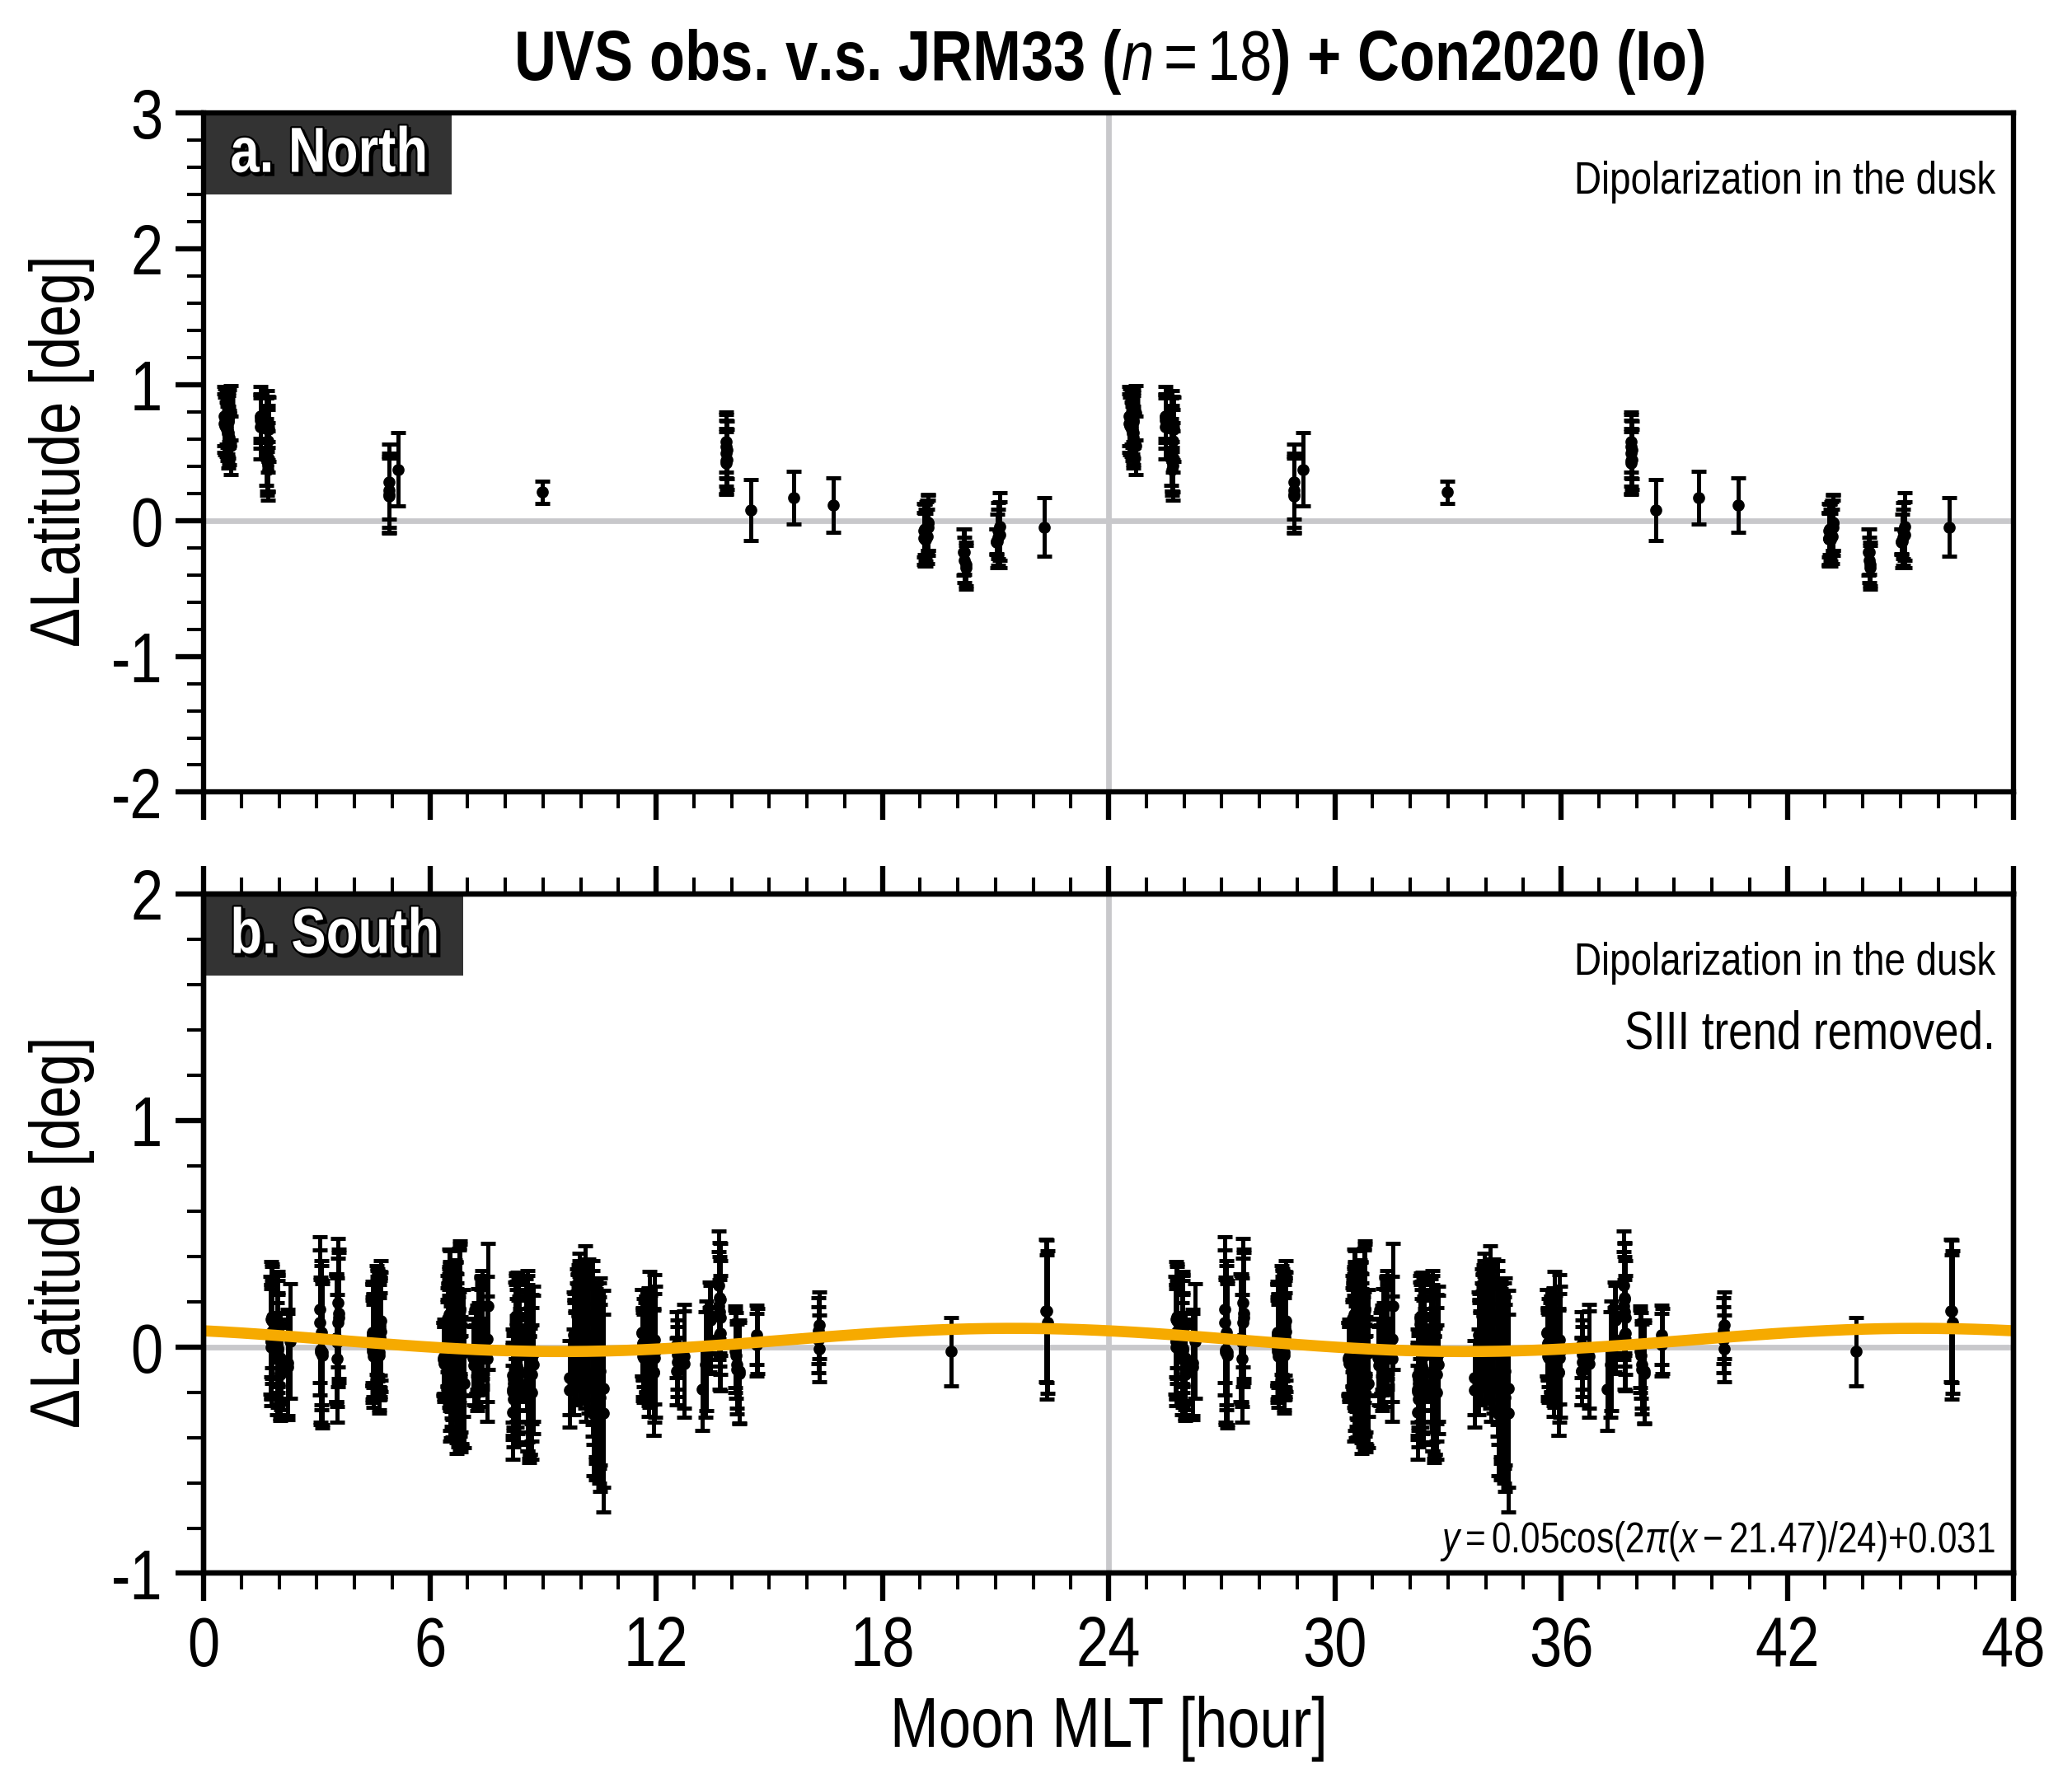

In [ ]:
# SIII依存性を差し引いてMLT依存性をフィッティング(南)
def fitfunc_MLT(MLT, a, b, c):
    y = a + b*np.cos((2*np.pi/24.0)*(MLT-c))
    return y


F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

deltalat_N = []
deltalat_S = []
MLT_N = []
MLT_S = []
for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        data_list_j = deltalat_N
        MLT_list_j = MLT_N
    else:
        ax_idx = 1
        sgn = -1
        data_list_j = deltalat_S
        MLT_list_j = MLT_S

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)

    if hem_fp_select[j] < 0:
        y = sgn*(lat_fp_select[j]-lat_fp_18_mui_r0[j])
    else:
        SIII_fit = fitfunc(moon_S3wlon_select[j]-eqlead_fp[j],
                           popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3], popt_s3[4],
                           popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8], popt_s3[9],
                           popt_s3[10])
        y = sgn*(lat_fp_select[j]-lat_fp_18_mui_r0[j])-SIII_fit

    data_list_j += [y]
    MLT_list_j += [lt]

    for i in range(2):
        sc = F.ax[ax_idx].scatter(lt+24.0*i,
                                  y,
                                  s=5.0, c='k')
        F.ax[ax_idx].errorbar(x=lt+24.0*i,
                              y=y,
                              yerr=err_lat_fp_select[j],
                              elinewidth=1.1, linewidth=0., markersize=0.,
                              capsize=2.0, capthick=1.1,
                              color='k')

# Dawn fitting
sort = np.argsort(np.array(MLT_S))
popt_lt, pcov = curve_fit(fitfunc_MLT,
                          np.array(MLT_S)[sort],
                          np.array(deltalat_S)[sort])
print(popt_lt)
x_fit = np.linspace(0, 47.9, 100)
y_fit = fitfunc_MLT(x_fit, popt_lt[0], popt_lt[1], popt_lt[2])
F.ax[1].plot(x_fit, y_fit, linewidth=3.0, color=UC.orange)
y_fit_label = r'$y=$' + str(round(popt_lt[1], 2)) +\
    r'cos(2$\pi(x-$'+str(round(24.0+popt_lt[2], 2))+')/24)+' +\
    str(round(popt_lt[0], 3))

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

F.ax[1].text(0.99, 0.83, r'SIII trend removed.',
             color='k',
             fontsize=F.fontsize*0.65,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)
F.ax[1].text(0.99, 0.08,
             y_fit_label,
             color='k',
             fontsize=F.fontsize*0.6,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

for i in range(2):
    F.ax[i].text(0.99, 0.93, r'Dipolarization in the dusk',
                 color='k',
                 fontsize=F.fontsize*0.65,
                 verticalalignment='top',
                 horizontalalignment='right',
                 transform=F.ax[i].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    F.ax[i].axvline(x=24.0, color=UC.lightgray, zorder=0.9)

RMSE = np.sum(np.sqrt((y_fit-0.0)**2))/np.size(y_fit)
F.ax[1].text(0.99, 0.73, 'RMSE = '+str(round(RMSE, 3)),
             color='k',
             fontsize=F.fontsize*0.65,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

# Duskで双極子化する電流シートをテストする EFPとGFPのベストフィット

<span style="color: yellow;">Azimuthal current constantにだけMLT依存性ありの場合</span>

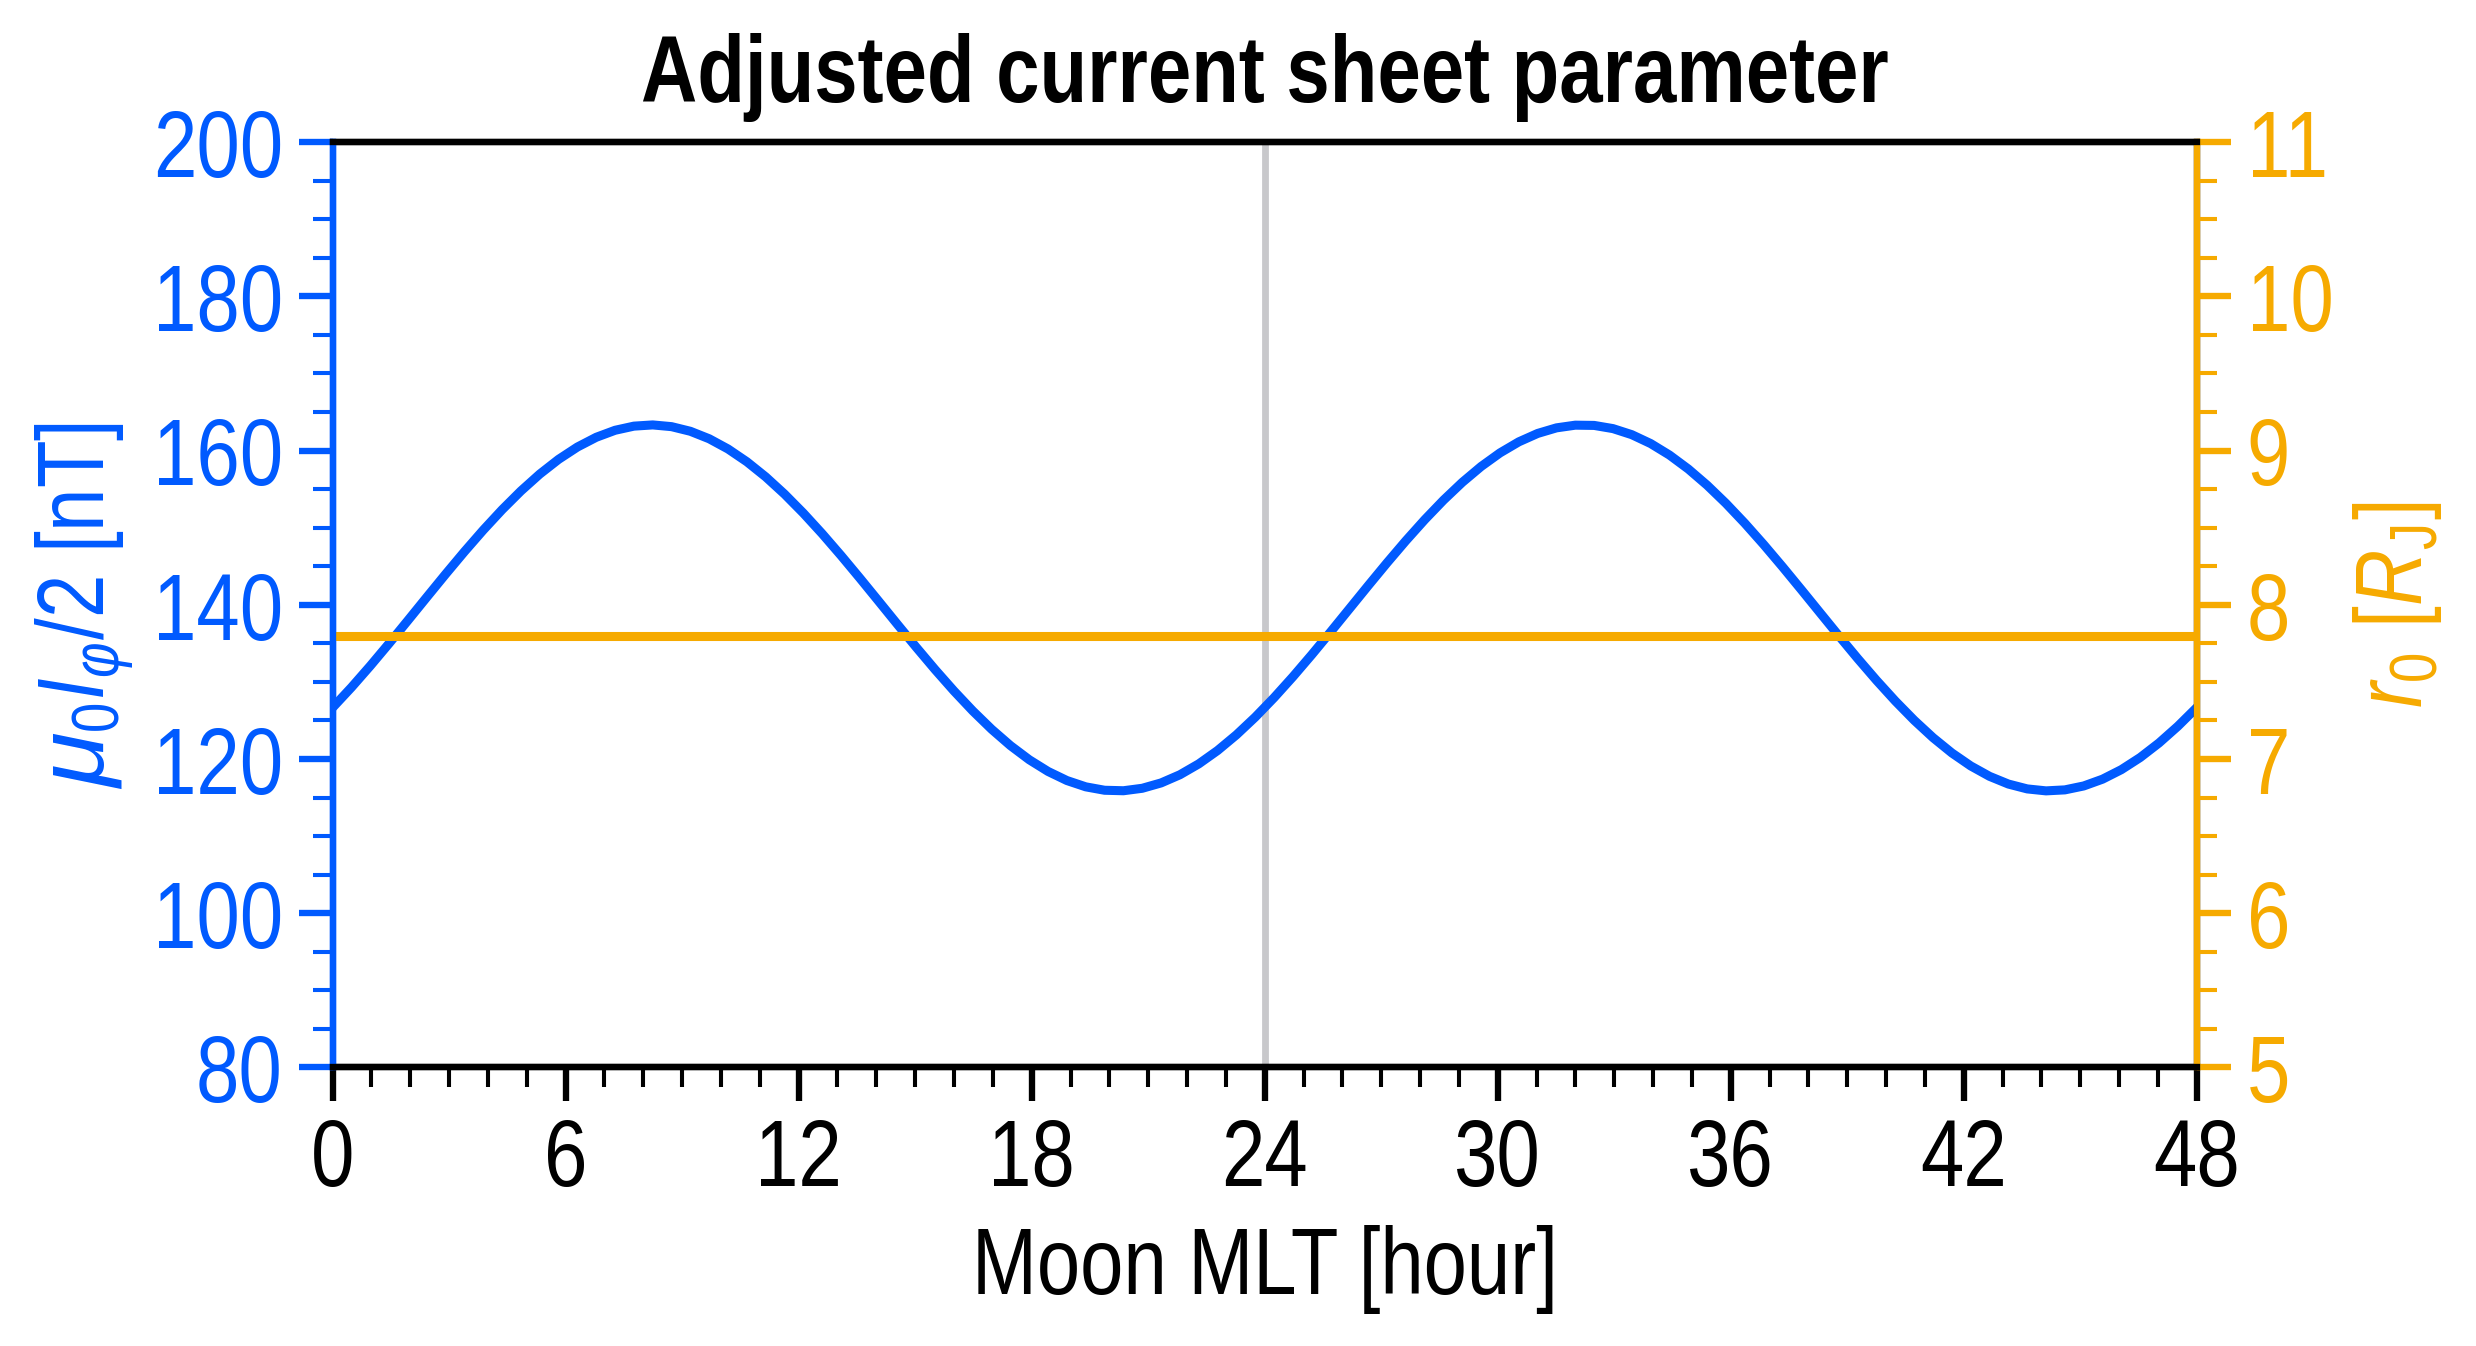

In [ ]:
# 合成した電流シートをプロット
MLT_arr = np.linspace(0.0, 47.999, 100)

F = ShareXaxis()
F.fontsize = 21
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=1, figsize=(7, 4), dpi='XL')
F.hspace = 0.15
F.initialize()

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\mu_0 I_\varphi /2$ [nT]',
            min=80, max=200,
            ticks=np.linspace(80, 200, 7),
            ticklabels=np.linspace(80, 200, 7, dtype=int),
            minor_num=4,
            labelcolor=UC.blue,
            axiscolor=UC.blue)
F.ax.plot(MLT_arr, mui_MLT(MLT_arr, amp=-0.17, phs=20.20),
          linewidth=2.0, color=UC.blue,)

ax2 = F.ax.twinx()
ax2.tick_params(axis='y', which='both',
                labelsize=F.fontsize,
                colors=UC.orange)
ax2.set_ylabel(r'$r_0$ [$R_{\rm J}$]', fontsize=F.fontsize,
               color=UC.orange)
ax2.spines['left'].set_color(UC.blue)
ax2.spines['right'].set_color(UC.orange)
ax2.set_ylim(5, 11)
ax2.set_yticks(np.linspace(5, 11, 7))
ax2.yaxis.set_minor_locator(ptick.AutoMinorLocator(4))
ax2.plot(MLT_arr, r0_MLT(MLT_arr, amp=0.0), linewidth=2.0, color=UC.orange,)

F.ax.set_title(r'Adjusted current sheet parameter', weight='bold')

F.ax.axvline(x=24.0, color=UC.lightgray, zorder=0.9)

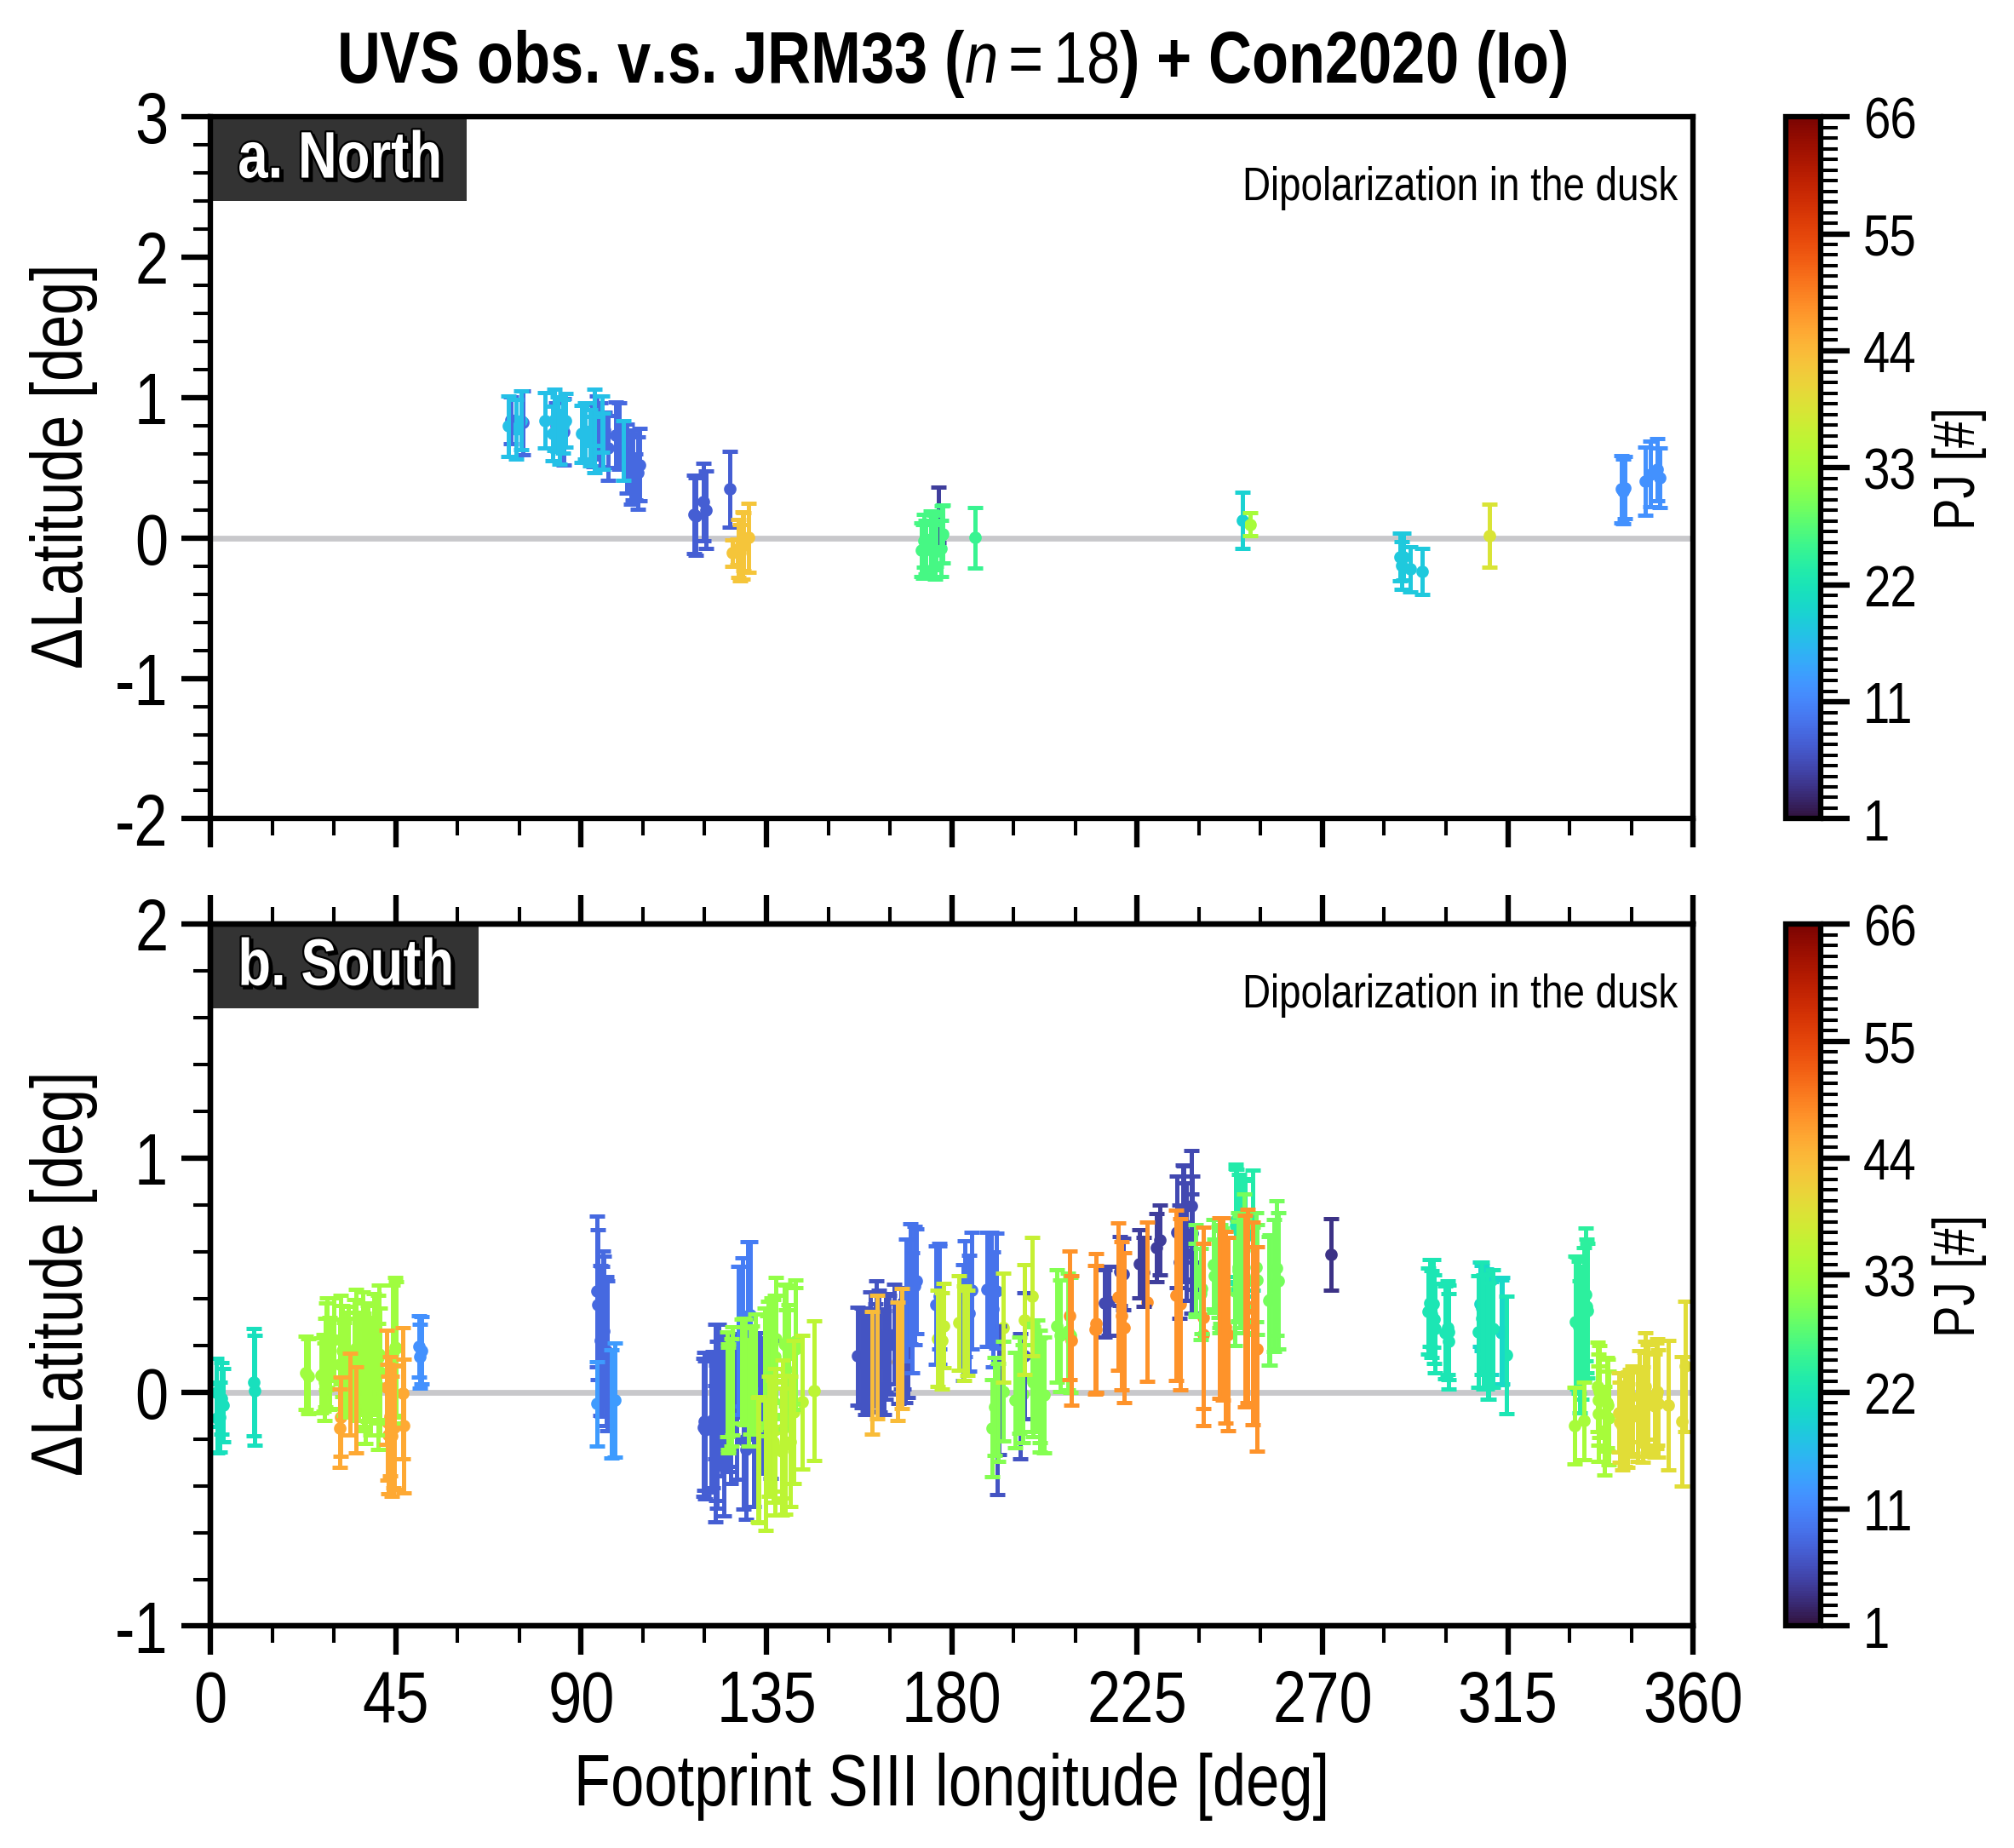

In [ ]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Footprint SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        # print(lat_modelfp_select[j])
    else:
        ax_idx = 1
        sgn = -1
    sc = F.ax[ax_idx].scatter(wlon_fp_select[j],
                              sgn*(lat_fp_select[j]-lat_fp_18_mui_017[j]),
                              s=5.0, c=pj_fp[j], cmap=cmap, vmin=vmin, vmax=vmax)
    F.ax[ax_idx].errorbar(x=wlon_fp_select[j],
                          y=sgn*(lat_fp_select[j]-lat_fp_18_mui_017[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color=cmap(norm(pj_fp[j])))

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

for i in range(2):
    F.ax[i].text(0.99, 0.93, r'Dipolarization in the dusk',
                 color='k',
                 fontsize=F.fontsize*0.65,
                 verticalalignment='top',
                 horizontalalignment='right',
                 transform=F.ax[i].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    cax = F.fig.colorbar(sc, ax=F.ax[i])
    cax.ax.set_yticks(np.linspace(1, 66, 7))
    cax.ax.set_yticklabels(np.linspace(
        1, 66, 7, dtype=int), fontsize=F.fontsize*0.8)
    cax.ax.yaxis.set_minor_locator(ptick.AutoMinorLocator(11))
    cax.ax.set_ylabel(r'PJ [#]', fontsize=F.fontsize*0.8)

[ 0.21294228  0.07488261  2.53456     0.21797061 -1.28226881  0.11875981
  0.58129441 -0.07214956  0.72073332  0.12242657  0.92988717]


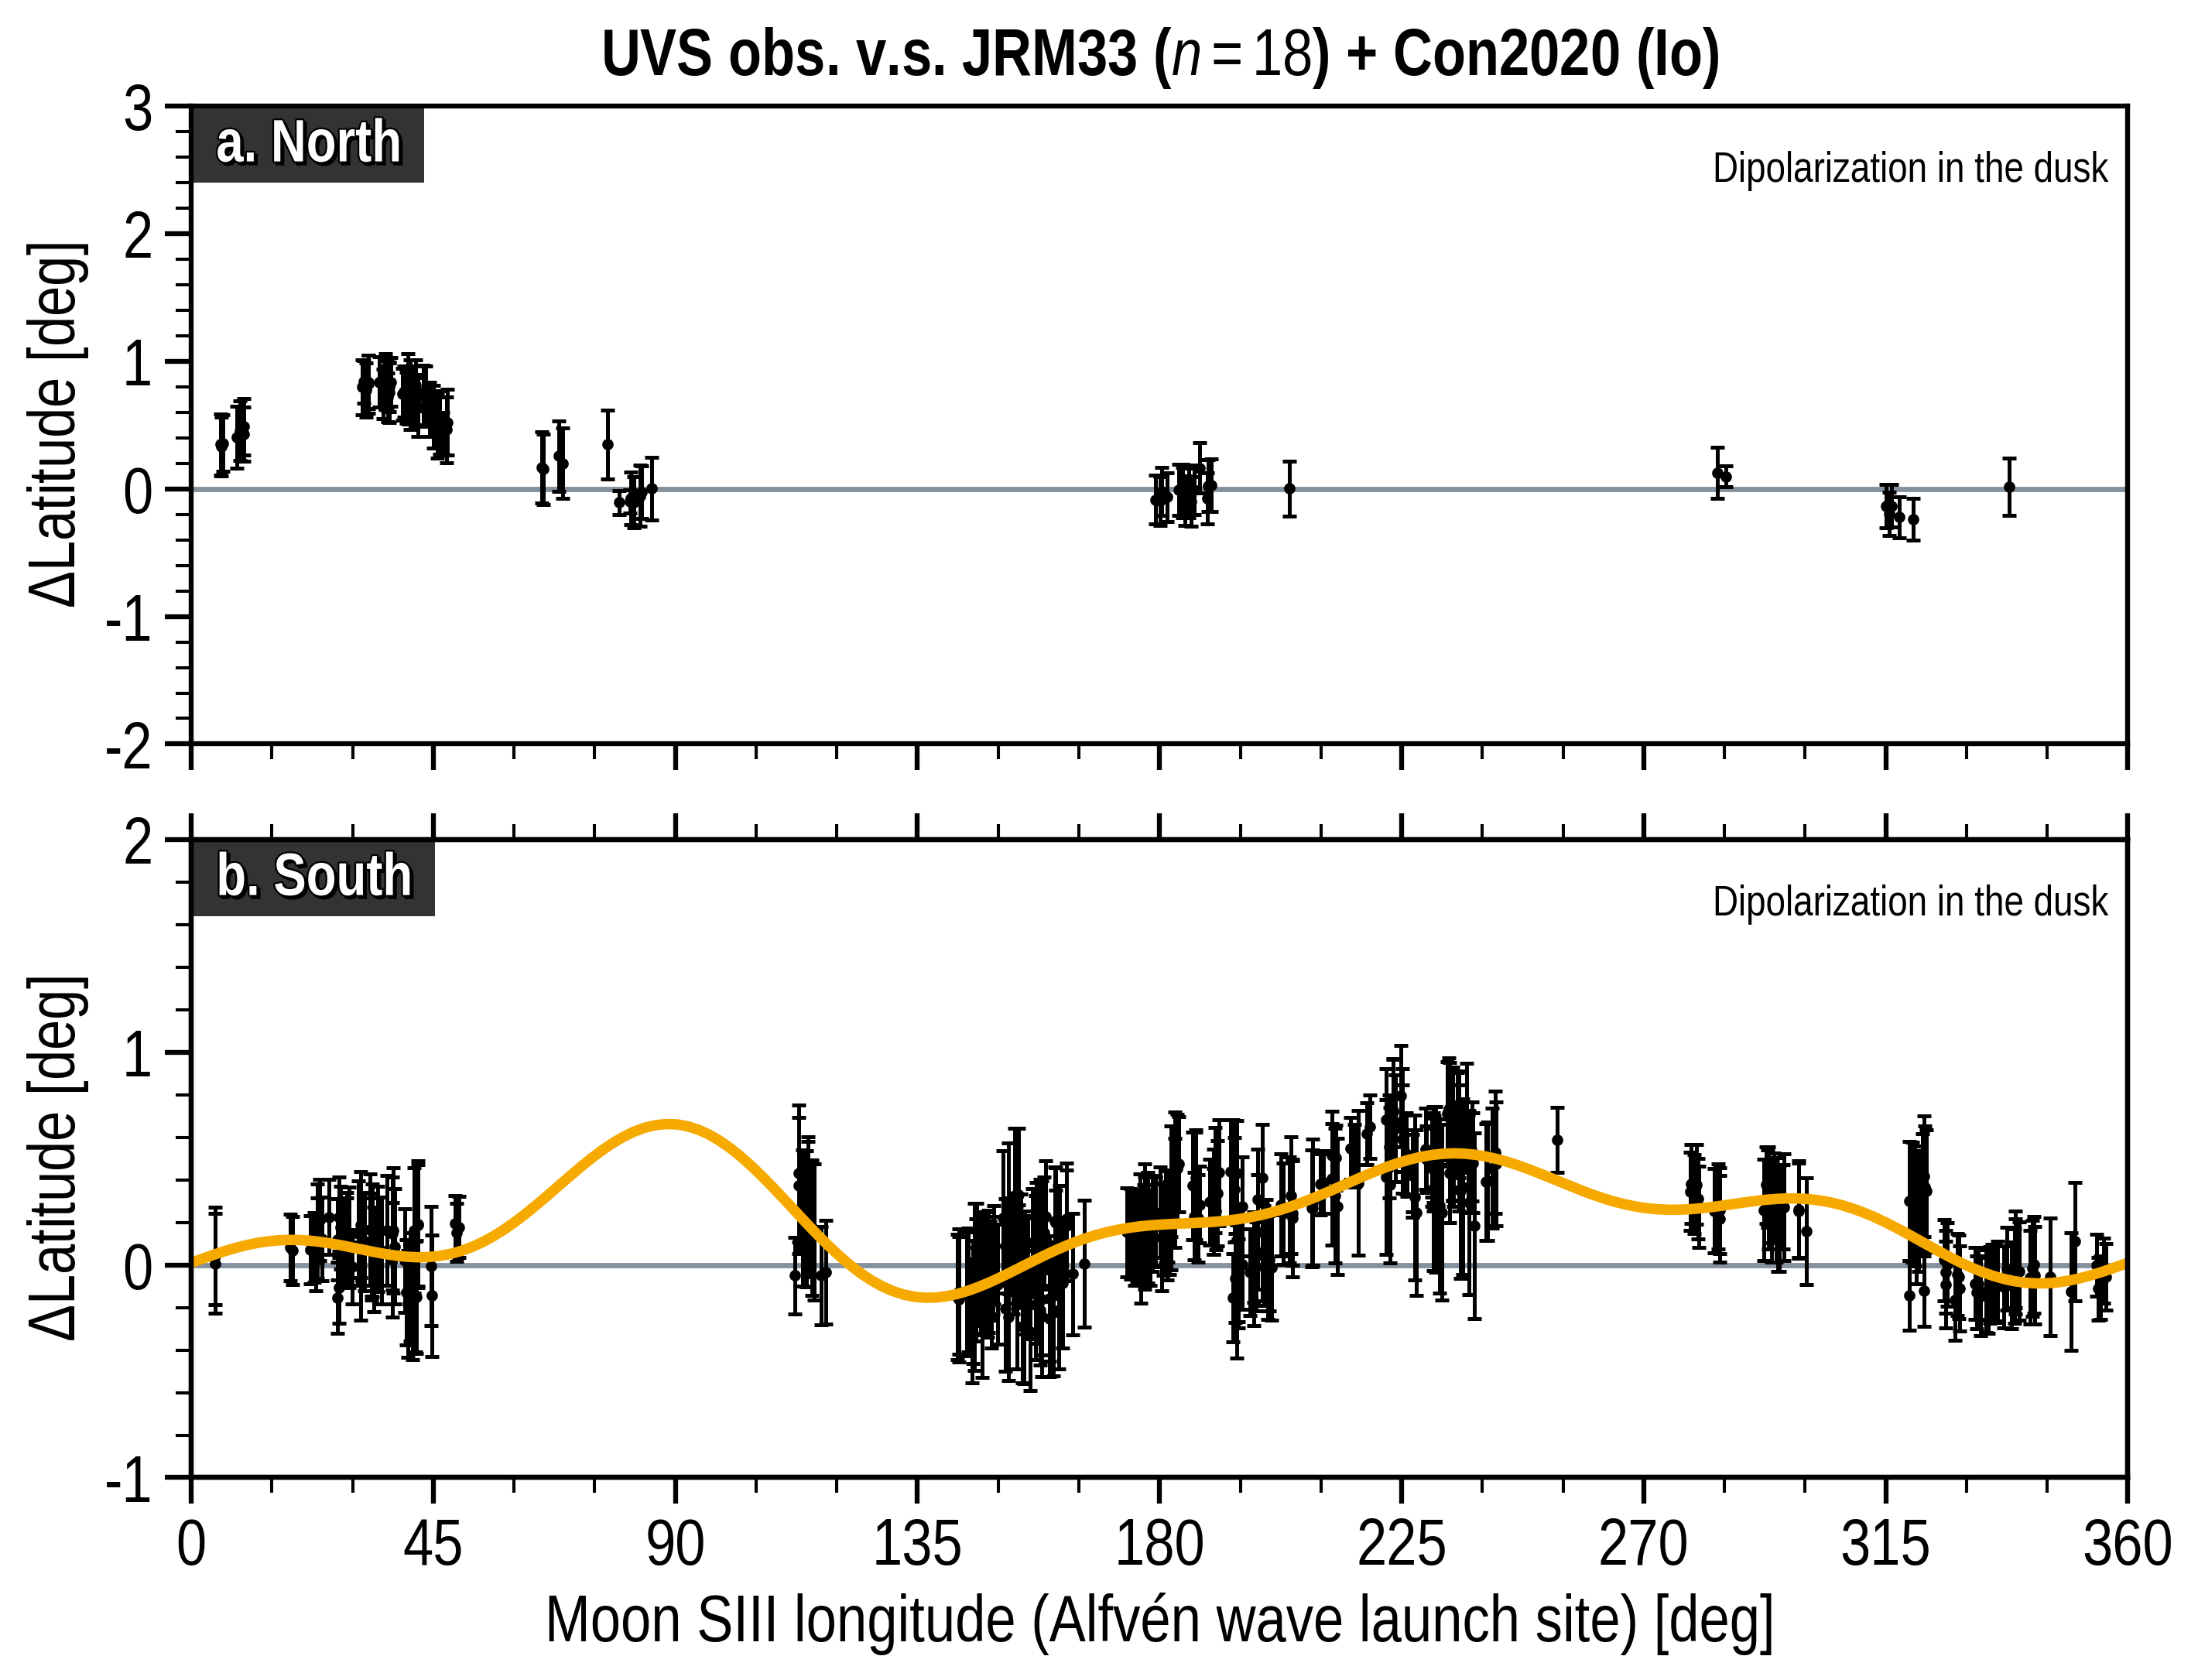

In [ ]:
# SIII依存性をフィッティング(南Dawn)
from scipy.optimize import curve_fit


def fitfunc(x, a0, a, b, c, d, e, f, g, h, i, j):
    # x: SIII west longitude [deg]
    phi = np.radians(360.0-x)
    y = a0 + a*np.cos(phi-b) + c*np.cos(2.0*(phi-d)) + \
        e*np.cos(3.0*(phi-f)) + g*np.cos(4.0*(phi-h)) + i*np.cos(5.0*(phi-j))
    return y


F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(9, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Moon SIII longitude (Alfvén wave launch site) [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=3)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 0.0
vmax = 24.0
cmap = cmocean.cm.balance
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

deltalat_N = []
deltalat_S = []
moonS3wlon_N = []
moonS3wlon_S = []
for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        data_list_j = deltalat_N
        data_list_j_moonS3wlon = moonS3wlon_N
    else:
        ax_idx = 1
        sgn = -1
        data_list_j = deltalat_S
        data_list_j_moonS3wlon = moonS3wlon_S

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    delta = wlon_fp_select[j]-wlon_defaultfp[j]
    lt = 12

    data_list_j_moonS3wlon += [moon_S3wlon_select[j]-eqlead_fp[j]]
    data_list_j += [sgn*(lat_fp_select[j]-lat_fp_18_mui_017[j])]

    sc = F.ax[ax_idx].scatter(moon_S3wlon_select[j]-eqlead_fp[j],
                              sgn*(lat_fp_select[j]-lat_fp_18_mui_017[j]),
                              s=5.0, c='k')
    F.ax[ax_idx].errorbar(x=moon_S3wlon_select[j]-eqlead_fp[j],
                          y=sgn*(lat_fp_select[j]-lat_fp_18_mui_017[j]),
                          yerr=err_lat_fp_select[j],
                          elinewidth=1.1, linewidth=0., markersize=0.,
                          capsize=2.0, capthick=1.1,
                          color='k')

# South fitting
sort = np.argsort(np.array(moonS3wlon_S))
popt_s3, pcov = curve_fit(fitfunc,
                          np.array(moonS3wlon_S)[sort],
                          np.array(deltalat_S)[sort])
print(popt_s3)
x_fit = np.linspace(0, 359.0, 180)
y_fit = fitfunc(x_fit, popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3],
                popt_s3[4], popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8],
                popt_s3[9], popt_s3[10])
F.ax[1].plot(x_fit, y_fit, linewidth=3.0, color=UC.orange)

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

for i in range(2):
    F.ax[i].text(0.99, 0.93, r'Dipolarization in the dusk',
                 color='k',
                 fontsize=F.fontsize*0.65,
                 verticalalignment='top',
                 horizontalalignment='right',
                 transform=F.ax[i].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.gray, zorder=0.9)

[ 0.12137815  0.20251231 -2.48683891]


Text(0.99, 0.73, 'RMSE = 0.154')

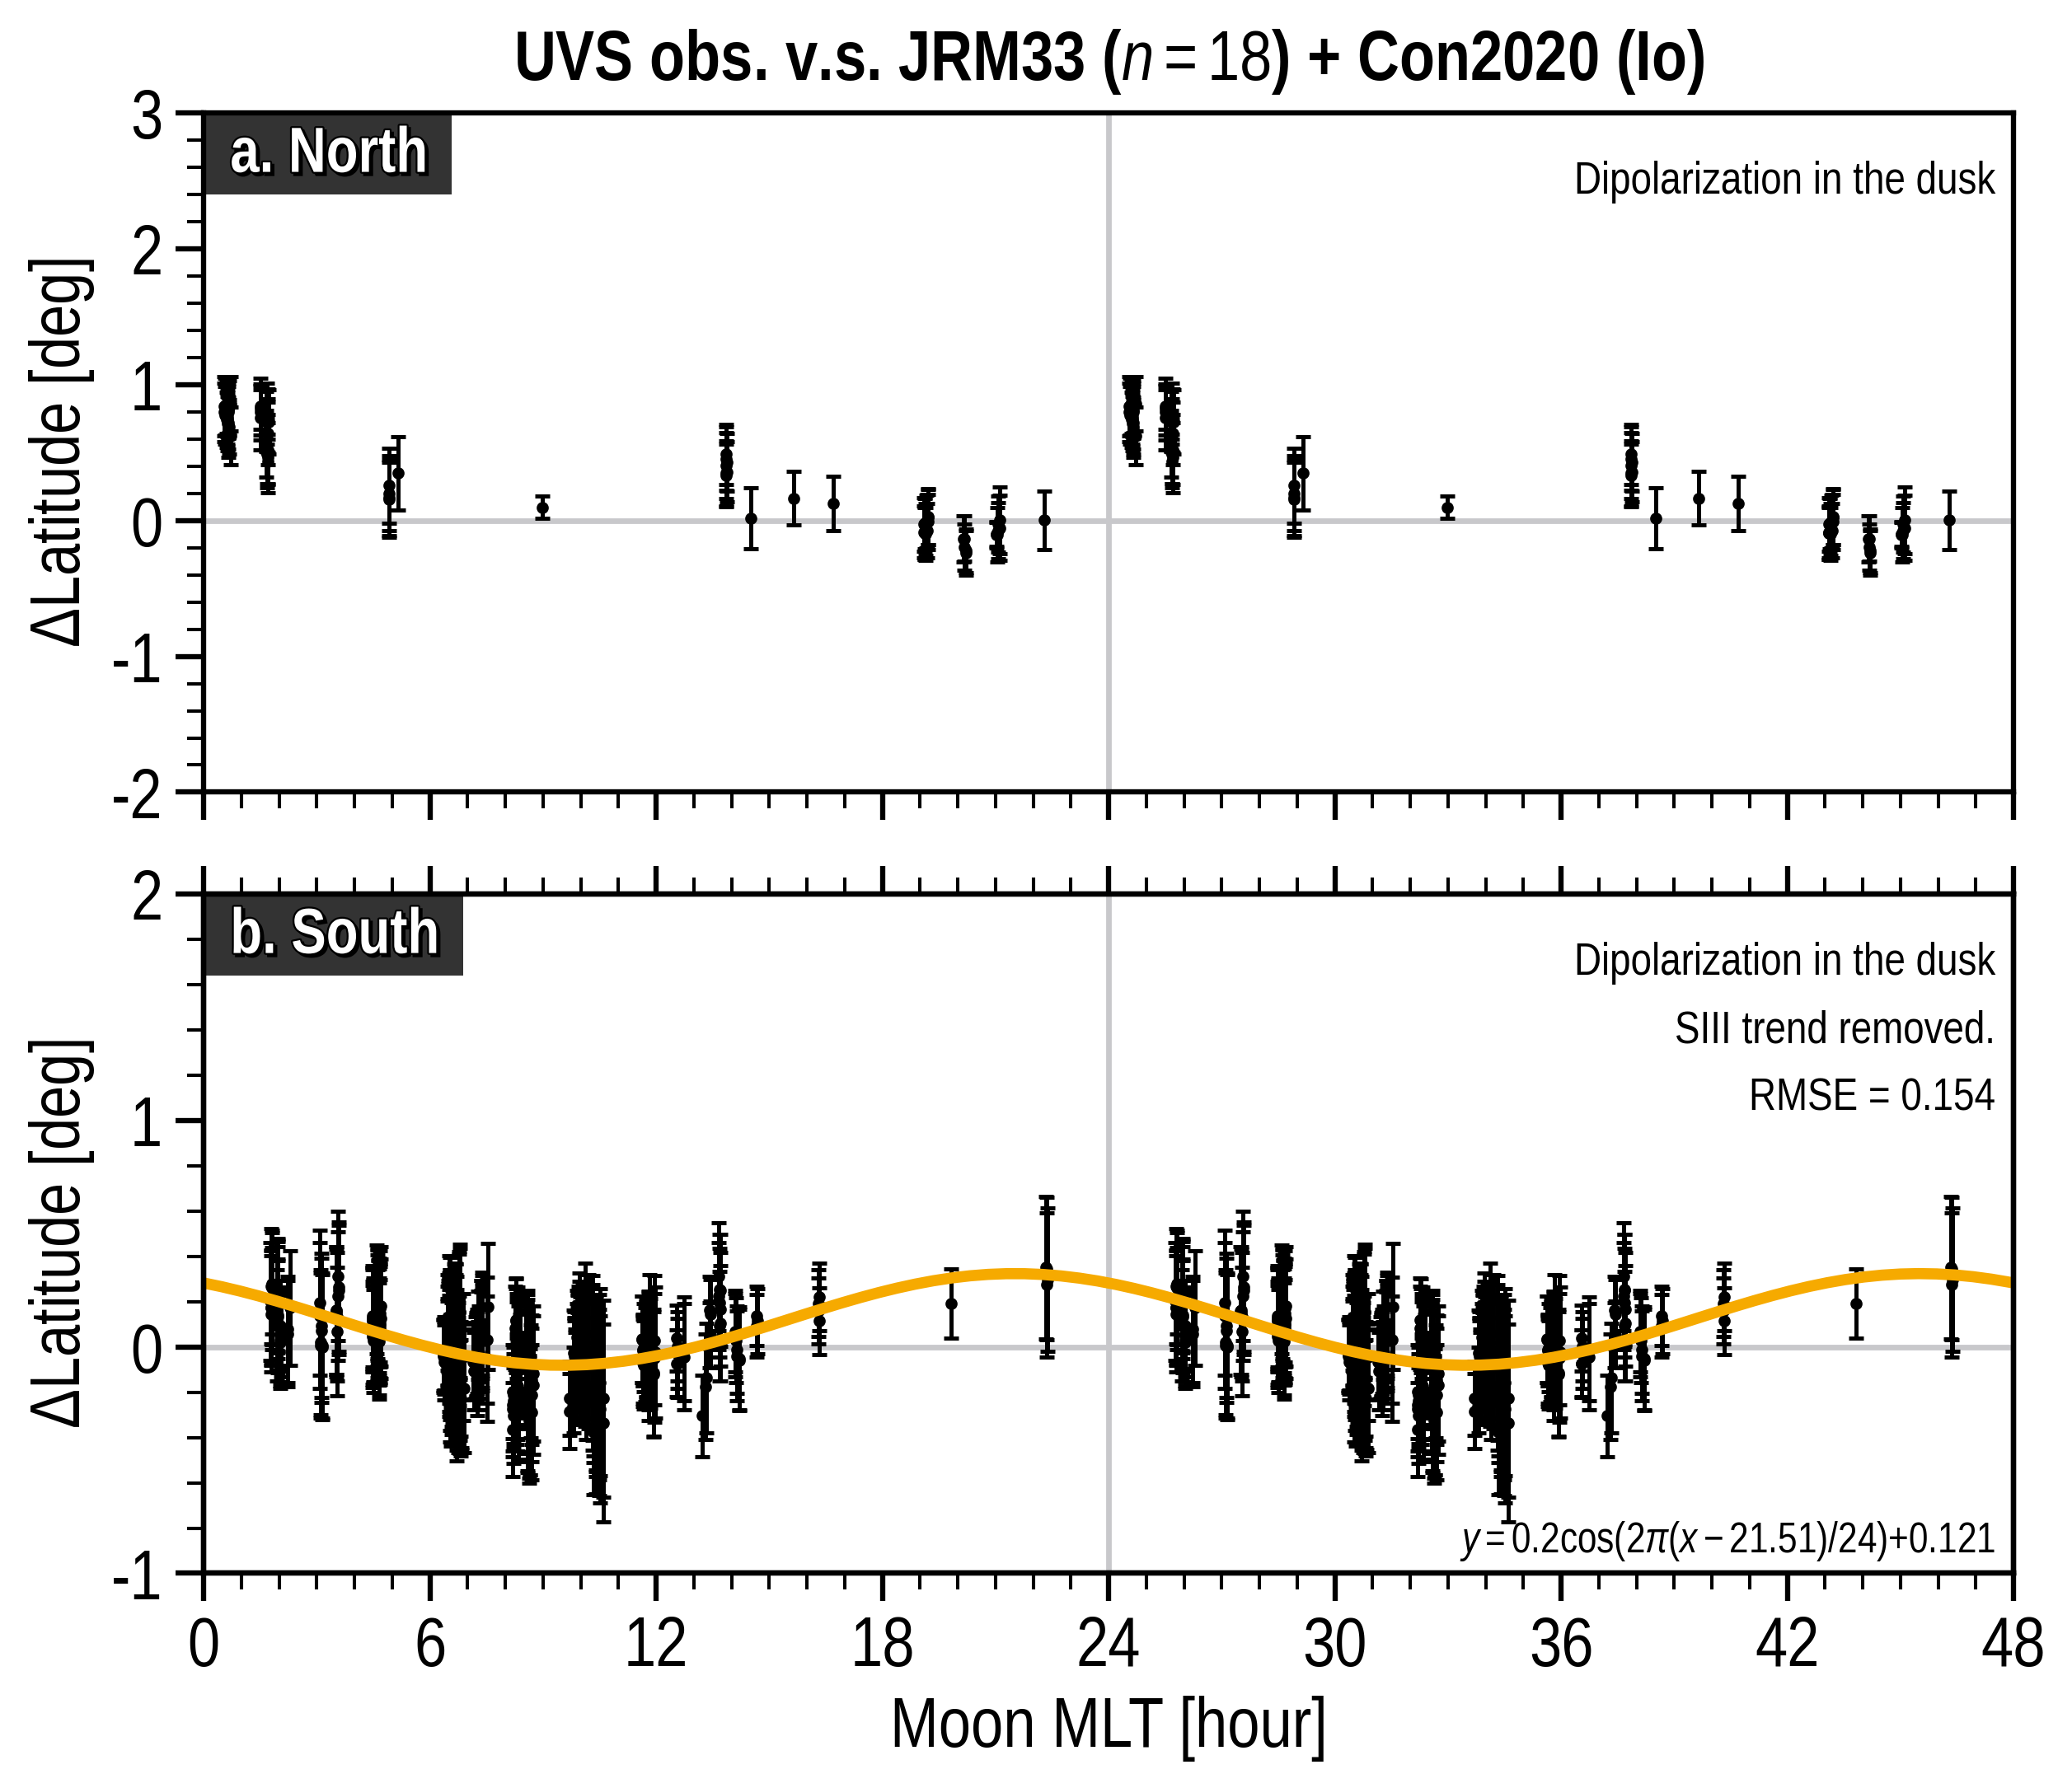

In [ ]:
# SIII依存性を差し引いてMLT依存性をフィッティング(南)
def fitfunc_MLT(MLT, a, b, c):
    y = a + b*np.cos((2*np.pi/24.0)*(MLT-c))
    return y


F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.15
F.initialize()

F.panelname = [' a. North ', ' b. South ']

xticks = np.arange(0, 48+1, 6)
xticklabels = np.arange(0, 48+1, 6, dtype=int)

F.set_xaxis(label=r'Moon MLT [hour]',
            min=0.0, max=48.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=6)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-2, max=3,
            ticks=np.linspace(-2, 3, 6),
            ticklabels=np.linspace(-2, 3, 6, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

# Setting for color bar
vmin = 1.0
vmax = 66.0
cmap = plt.get_cmap('turbo')
norm = mplcolors.Normalize(vmin=vmin, vmax=vmax)

moon_S3wlon_select = moon_S3wlon
hem_fp_select = hem_fp
view_angle_select = view_angle    # [deg]
wlon_fp_select = wlon_fp          # [deg]
lat_fp_select = lat_fp            # [deg]
err_lat_fp_select = err_lat_fp    # [deg]
et_fp_select = et_fp

deltalat_N = []
deltalat_S = []
MLT_N = []
MLT_S = []
for j in range(moon_S3wlon_select.size):
    if hem_fp_select[j] < 0:
        ax_idx = 0
        sgn = 1
        data_list_j = deltalat_N
        MLT_list_j = MLT_N
    else:
        ax_idx = 1
        sgn = -1
        data_list_j = deltalat_S
        MLT_list_j = MLT_S

    theta_j = math.radians(90.0-lat_fp_select[j])
    phi_j = math.radians(360.0-wlon_fp_select[j])
    x_fp_polar = math.sin(theta_j)*math.cos(phi_j)
    y_fp_polar = math.sin(theta_j)*math.sin(phi_j)
    z_fp_polar = math.cos(theta_j)

    lt = local_time_moon(et_fp_select[j], TARGET_MOON)

    if hem_fp_select[j] < 0:
        y = sgn*(lat_fp_select[j]-lat_fp_18_mui_017[j])
    else:
        SIII_fit = fitfunc(moon_S3wlon_select[j]-eqlead_fp[j],
                           popt_s3[0], popt_s3[1], popt_s3[2], popt_s3[3], popt_s3[4],
                           popt_s3[5], popt_s3[6], popt_s3[7], popt_s3[8], popt_s3[9],
                           popt_s3[10])
        y = sgn*(lat_fp_select[j]-lat_fp_18_mui_017[j])-SIII_fit

    data_list_j += [y]
    MLT_list_j += [lt]

    for i in range(2):
        sc = F.ax[ax_idx].scatter(lt+24.0*i,
                                  y,
                                  s=5.0, c='k')
        F.ax[ax_idx].errorbar(x=lt+24.0*i,
                              y=y,
                              yerr=err_lat_fp_select[j],
                              elinewidth=1.1, linewidth=0., markersize=0.,
                              capsize=2.0, capthick=1.1,
                              color='k')

# Dawn fitting
sort = np.argsort(np.array(MLT_S))
popt_lt, pcov = curve_fit(fitfunc_MLT,
                          np.array(MLT_S)[sort],
                          np.array(deltalat_S)[sort])
print(popt_lt)
x_fit = np.linspace(0, 47.9, 100)
y_fit = fitfunc_MLT(x_fit, popt_lt[0], popt_lt[1], popt_lt[2])
F.ax[1].plot(x_fit, y_fit, linewidth=3.0, color=UC.orange)
y_fit_label = r'$y=$' + str(round(popt_lt[1], 2)) +\
    r'cos(2$\pi(x-$'+str(round(24.0+popt_lt[2], 2))+')/24)+' +\
    str(round(popt_lt[0], 3))

F.ax[0].set_title(r'UVS obs. v.s. JRM33 ($n=18$) + Con2020 (' +
                  TARGET_MOON[0:2]+')', weight='bold')

F.ax[1].text(0.99, 0.83, r'SIII trend removed.',
             color='k',
             fontsize=F.fontsize*0.65,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)
F.ax[1].text(0.99, 0.08,
             y_fit_label,
             color='k',
             fontsize=F.fontsize*0.6,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)

for i in range(2):
    F.ax[i].text(0.99, 0.93, r'Dipolarization in the dusk',
                 color='k',
                 fontsize=F.fontsize*0.65,
                 verticalalignment='top',
                 horizontalalignment='right',
                 transform=F.ax[i].transAxes)

for i in range(2):
    F.ax[i].axhline(y=0, color=UC.lightgray, zorder=0.9)
    F.ax[i].axvline(x=24.0, color=UC.lightgray, zorder=0.9)

RMSE = np.sum(np.sqrt((y_fit-0.0)**2))/np.size(y_fit)
F.ax[1].text(0.99, 0.73, 'RMSE = '+str(round(RMSE, 3)),
             color='k',
             fontsize=F.fontsize*0.65,
             verticalalignment='top',
             horizontalalignment='right',
             transform=F.ax[1].transAxes)